# EDA Final Notebook — Datathon 2026: The Gridbreakers
**VinTelligence × VinUni DS&AI Club**
Giai đoạn huấn luyện: `04/07/2012 – 31/12/2022` | Mục tiêu dự báo: `01/01/2023 – 01/07/2024`

**Bảng màu nhất quán:**
🟣 `#534AB7` = Streetwear | 🔴 `#993C1D` = Outdoor | 🟢 `#0F6E56` = Casual | 🩷 `#993556` = GenZ

| Mục | Nội dung |
|---|---|
| 1. Danh mục Sản phẩm | Số SKU · Số lượng đặt · Giá/biên lợi nhuận theo phân khúc |
| 2. Khách hàng & Địa lý | Nhân khẩu học · Kênh thu hút · Vùng · Tần suất mua |
| 3. Đơn hàng & Giao dịch | Chuỗi thời gian · AOV · Thiết bị · Kênh |
| 4. Chi tiết Đơn hàng | Basket size · Chiết khấu · Tập trung doanh thu |
| 5. Vận chuyển & Giao hàng | Tốc độ · Chi phí · Trễ hàng · Liên kết trả hàng |
| 6. Trả hàng & Đánh giá | Lý do trả · Hoàn tiền · Rating · Độ phủ |
| 7. Khuyến mãi | Danh mục · Tỷ lệ áp dụng · ROI · Chiến lược |
| 8. Tồn kho | Sức khỏe · Doanh thu mất · Phân loại hành động cung ứng |
| 9. Lưu lượng Web | Kênh thu hút · Mùa vụ · Tương quan doanh thu |
| 10. Lộ trình Prescriptive | Tổng hợp liên chiều — dự đoán & hành động tối ưu |

---
# 0. Thiết lập & Nạp dữ liệu

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

In [94]:
DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

customers   = pd.read_csv(DIR + "customers.csv")
geography   = pd.read_csv(DIR + "geography.csv")
inventory   = pd.read_csv(DIR + "inventory.csv")
order_items = pd.read_csv(DIR + "order_items.csv")
orders      = pd.read_csv(DIR + "orders.csv")
payments    = pd.read_csv(DIR + "payments.csv")
products    = pd.read_csv(DIR + "products.csv")
promotions  = pd.read_csv(DIR + "promotions.csv")
returns     = pd.read_csv(DIR + "returns.csv")
reviews     = pd.read_csv(DIR + "reviews.csv")
sales       = pd.read_csv(DIR + "sales.csv")
shipments   = pd.read_csv(DIR + "shipments.csv")
web_traffic = pd.read_csv(DIR + "web_traffic.csv")

orders['order_date']     = pd.to_datetime(orders['order_date'])
orders['year']           = orders['order_date'].dt.year
orders['month']          = orders['order_date'].dt.month
orders['ym']             = orders['order_date'].dt.to_period('M').astype(str)
orders['dow']            = orders['order_date'].dt.dayofweek
orders['day']            = orders['order_date'].dt.day
returns['return_date']   = pd.to_datetime(returns['return_date'])
returns['year']          = returns['return_date'].dt.year
reviews['review_date']   = pd.to_datetime(reviews['review_date'])
reviews['year']          = reviews['review_date'].dt.year
sales['Date']            = pd.to_datetime(sales['Date'])
web_traffic['date']      = pd.to_datetime(web_traffic['date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date']   = pd.to_datetime(promotions['end_date'])

op       = orders.merge(payments, on='order_id', how='left')
op['ym'] = orders['ym']; op['year'] = orders['year']

oi_prod  = order_items.merge(
    products[['product_id','category','segment','size','price','cogs']],
    on='product_id', how='left')
ret_prod = returns.merge(
    products[['product_id','category','segment','size']], on='product_id', how='left')
rev_prod = reviews.merge(
    products[['product_id','category','segment']], on='product_id', how='left')

print(f"orders: {orders.shape} | order_items: {order_items.shape} | customers: {customers.shape}")

orders: (646945, 13) | order_items: (714669, 7) | customers: (121930, 7)


In [95]:
def set_light_style():
    plt.rcParams.update({
        "font.family": "sans-serif",
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": "#E5E5E5", "grid.linewidth": 0.6,
        "axes.axisbelow": True, "figure.facecolor": "white",
        "axes.facecolor": "white", "text.color": "#1A1A1A",
        "axes.labelcolor": "#1A1A1A", "xtick.color": "#1A1A1A", "ytick.color": "#1A1A1A",
    })

set_light_style()

CAT_COLORS = {"Streetwear":"#534AB7","Outdoor":"#993C1D","Casual":"#0F6E56","GenZ":"#993556"}
SEG_COLORS = {
    "Everyday":"#534AB7","Performance":"#7F77DD","Balanced":"#AFA9EC","Standard":"#CECBF6",
    "Activewear (Outdoor)":"#993C1D","Premium":"#C4714A","All-weather":"#0F6E56",
    "Activewear (Casual)":"#5DCAA5","Trendy":"#993556",
}
MONTH_LABELS = ['Th1','Th2','Th3','Th4','Th5','Th6','Th7','Th8','Th9','Th10','Th11','Th12']
CATS = ["Streetwear","Outdoor","Casual","GenZ"]
CAT_SEGS = {
    "Streetwear": ["Everyday","Performance","Balanced","Standard"],
    "Outdoor":    ["Activewear (Outdoor)","Premium","All-weather"],
    "Casual":     ["Activewear (Casual)"],
    "GenZ":       ["Trendy"],
}
ALL_SEGS = ["Everyday","Performance","Balanced","Standard",
            "Activewear (Outdoor)","Premium","All-weather","Activewear (Casual)","Trendy"]

def fmt_k(x, _=None):
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    if abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

products["margin"] = (products["price"] - products["cogs"]) / products["price"] * 100

# Map segment → segment_full (xử lý trường hợp inventory.segment = 'Activewear')
SEG_ALIAS = {
    "Activewear": "Activewear (Outdoor)",   # fallback khi không rõ category
}
def resolve_seg(row):
    seg = row.get("segment", row.get("segment_full", ""))
    cat = row.get("category", "")
    if seg == "Activewear":
        return "Activewear (Outdoor)" if cat == "Outdoor" else "Activewear (Casual)"
    return SEG_ALIAS.get(seg, seg)

products["segment_full"]  = products.apply(resolve_seg, axis=1)
inventory["segment_full"] = inventory.apply(resolve_seg, axis=1)

# Bổ sung alias vào SEG_COLORS để các .get() không fallback về #999
SEG_COLORS["Activewear"] = SEG_COLORS["Activewear (Outdoor)"]
print("Thiết lập hoàn tất.")

Thiết lập hoàn tất.


---
# 1. Phân tích Danh mục Sản phẩm
**Ba chiều:** Số SKU · Số lượng đặt · Phân phối giá theo phân khúc

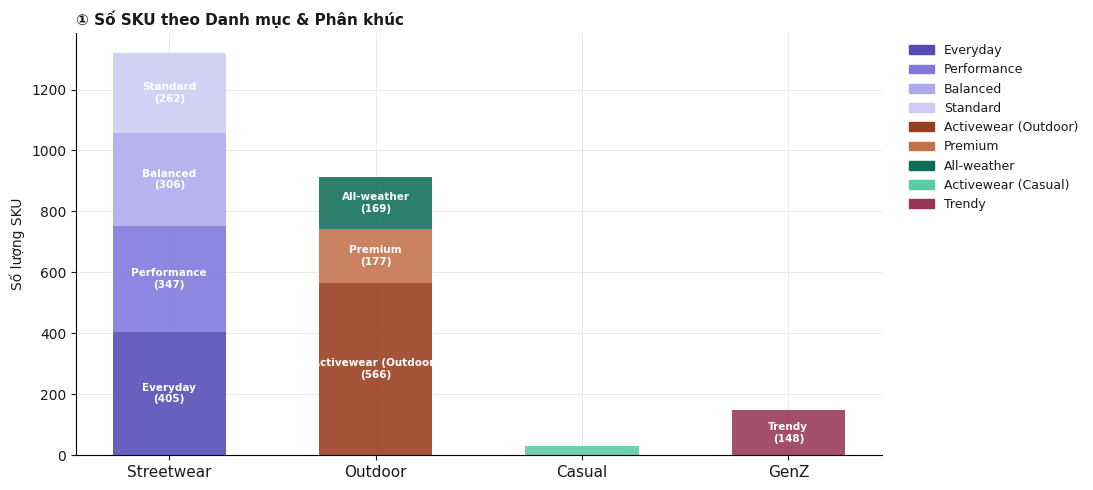

In [96]:
# BIỂU ĐỒ 1: SỐ SKU THEO DANH MỤC & PHÂN KHÚC
set_light_style()
sku_counts = products.groupby("segment_full").size()
fig, ax = plt.subplots(figsize=(11, 5))
plt.subplots_adjust(right=0.70)
x_pos = np.arange(len(CATS)); bottom = np.zeros(len(CATS))
for seg in ALL_SEGS:
    for ci, cat in enumerate(CATS):
        if seg in CAT_SEGS[cat]:
            val = sku_counts.get(seg, 0)
            ax.bar(ci, val, bottom=bottom[ci],
                   color=SEG_COLORS.get(seg, "#999"), width=0.55, alpha=0.88)
            if val > 40:
                ax.text(ci, bottom[ci] + val / 2, f"{seg}\n({val})",
                        ha='center', va='center', fontsize=7.5,
                        color='white', fontweight='bold')
            bottom[ci] += val
ax.set_xticks(x_pos); ax.set_xticklabels(CATS, fontsize=11)
ax.set_ylabel("Số lượng SKU")
ax.set_title("① Số SKU theo Danh mục & Phân khúc", fontweight='bold', loc='left', fontsize=11)
ax.legend(handles=[mpatches.Patch(color=SEG_COLORS.get(s, "#999"), label=s) for s in ALL_SEGS],
          loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

**2,412 SKUs** phân bổ vào 4 danh mục, 9 phân khúc. **Streetwear** chiếm 54.7% SKU,
**Outdoor** 30.8%. Standard (10.9% SKU) gần như không đóng góp doanh số — tín hiệu cần rationalization ngay.

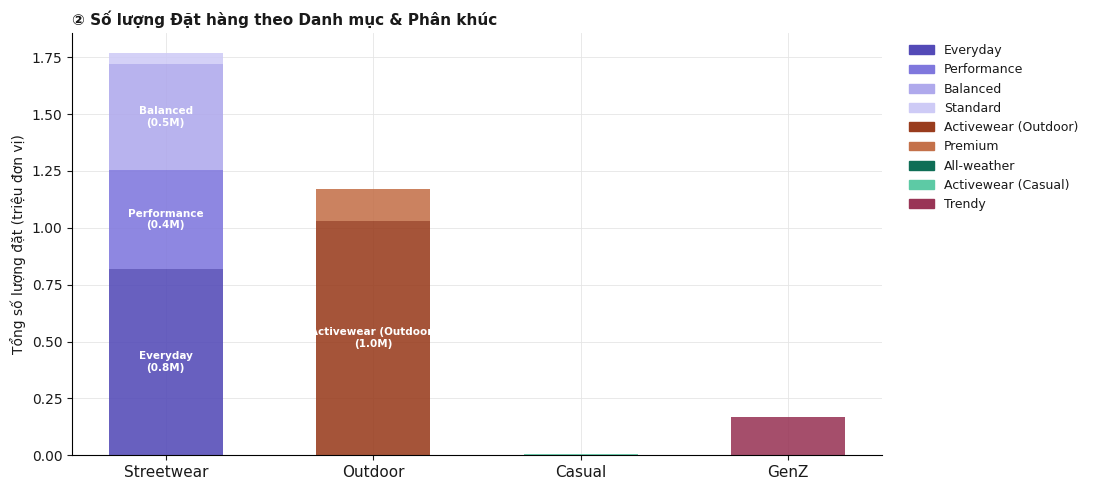

In [97]:
# BIỂU ĐỒ 2: SỐ LƯỢNG ĐẶT HÀNG THEO DANH MỤC & PHÂN KHÚC
set_light_style()
merged = order_items.merge(
    products[['product_id', 'category', 'segment_full']], on='product_id', how='left')
qty_seg = merged.groupby(['category', 'segment_full'])['quantity'].sum().reset_index()
fig, ax = plt.subplots(figsize=(11, 5))
plt.subplots_adjust(right=0.70)
bottom2 = np.zeros(len(CATS))
for seg in ALL_SEGS:
    for ci, cat in enumerate(CATS):
        if seg in CAT_SEGS[cat]:
            val = qty_seg[
                (qty_seg['category'] == cat) & (qty_seg['segment_full'] == seg)
            ]['quantity'].sum()
            ax.bar(ci, val / 1e6, bottom=bottom2[ci] / 1e6,
                   color=SEG_COLORS.get(seg, "#999"), width=0.55, alpha=0.88)
            if val > 3e5:
                ax.text(ci, (bottom2[ci] + val / 2) / 1e6,
                        f"{seg}\n({val/1e6:.1f}M)",
                        ha='center', va='center', fontsize=7.5,
                        color='white', fontweight='bold')
            bottom2[ci] += val
ax.set_xticks(np.arange(len(CATS))); ax.set_xticklabels(CATS, fontsize=11)
ax.set_ylabel("Tổng số lượng đặt (triệu đơn vị)")
ax.set_title("② Số lượng Đặt hàng theo Danh mục & Phân khúc",
             fontweight='bold', loc='left', fontsize=11)
ax.legend(handles=[mpatches.Patch(color=SEG_COLORS.get(s, "#999"), label=s) for s in ALL_SEGS],
          loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

**Activewear (Outdoor) chiếm 32.1% tổng quantity** chỉ với 23.5% SKU — punch above its weight rõ ràng.
Standard (10.9% SKU): chỉ 1.5% quantity — tiêu tốn không gian catalog không tương xứng.

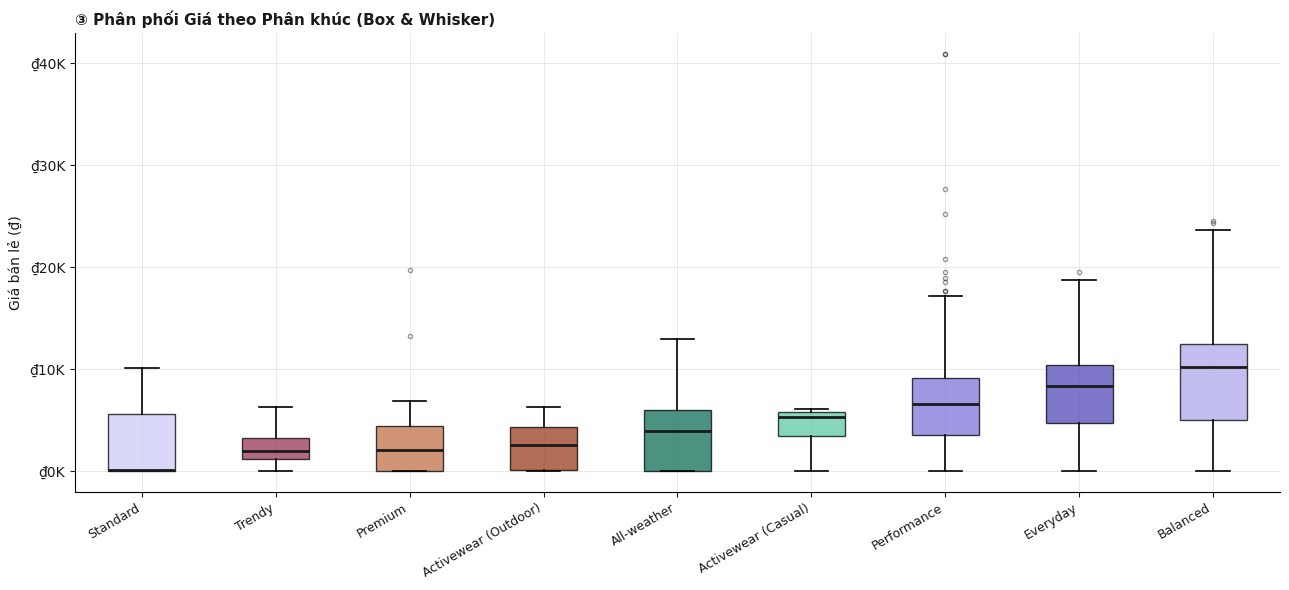

In [98]:
# BIỂU ĐỒ 3: PHÂN PHỐI GIÁ THEO PHÂN KHÚC (BOX PLOT)
set_light_style()
seg_order = (products.groupby('segment_full')['price']
             .median().sort_values(ascending=True).index.tolist())
data_by_seg = [products[products['segment_full'] == s]['price'].values for s in seg_order]
fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(data_by_seg, vert=True, patch_artist=True,
                medianprops=dict(color='#1A1A1A', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, seg in zip(bp['boxes'], seg_order):
    patch.set_facecolor(SEG_COLORS.get(seg, "#999")); patch.set_alpha(0.75)
ax.set_xticks(range(1, len(seg_order) + 1))
ax.set_xticklabels(seg_order, rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Giá bán lẻ (₫)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₫{x/1000:.0f}K'))
ax.set_title("③ Phân phối Giá theo Phân khúc (Box & Whisker)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**Standard** median ₫78 — gần như không phải sản phẩm thực, khả năng là lỗi dữ liệu hoặc clearance items.
**Performance** IQR cực rộng (₫3K đến ₫40K+) trong cùng một phân khúc — khách hàng không thể định vị → conversion rate thấp.

In [99]:
# BẢNG: PRICE OUTLIERS THEO PHÂN KHÚC
outliers_list = []
for seg in seg_order:
    data = products[products['segment_full'] == seg]['price']
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outs = data[(data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)]
    if len(outs):
        outliers_list.append({'Phân khúc': seg, 'Số outliers': len(outs),
                              'Min': f'₫{outs.min():,.0f}', 'Max': f'₫{outs.max():,.0f}'})
if outliers_list:
    print(pd.DataFrame(outliers_list).to_string(index=False))
else:
    print("Không có outlier theo IQR×1.5")

  Phân khúc  Số outliers     Min     Max
    Premium            2 ₫13,293 ₫19,687
Performance           10 ₫17,637 ₫40,950
   Everyday            1 ₫19,529 ₫19,529
   Balanced            2 ₫24,322 ₫24,574


## Danh mục Sản phẩm — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

Catalog gồm **2,412 SKUs** trong 4 danh mục, 9 phân khúc. **Activewear (Outdoor)** đứng đầu về quantity share (32.1%) với chỉ 23.5% SKU — velocity cao nhất catalog. **Everyday** cũng vượt trội: 25.5% quantity với 16.8% SKU. **Standard** tiêu tốn 10.9% SKU nhưng chỉ đóng góp 1.5% quantity, median giá ₫78 — bất thường nghiêm trọng.

---

### 🔍 Chẩn đoán — Why did it happen?

Star segments (Activewear Outdoor & Everyday) có price point rõ ràng, nhất quán → khách hàng dễ quyết định. **Standard** với median ₫78 gần như không phải sản phẩm thực — nhiều khả năng là lỗi nhập liệu, clearance items, hoặc loss-leader không có chiến lược. **Performance** IQR cực rộng (₫3K–₫40K+) gây nhầm lẫn định vị → conversion thấp.

---

### 📈 Dự đoán — What is likely to happen?

Activewear (Outdoor) sẽ gặp áp lực stockout nếu không mở rộng SKU — demand/SKU ratio cao nhất catalog. Standard sẽ tiếp tục tích lũy dead inventory vì không có mechanism tự sửa khi median giá ₫78.

---

### 🎯 Prescriptive — What should we do?

**① SKU rationalization — Standard:** Pull toàn bộ 262 SKUs, phân loại lỗi dữ liệu (fix), clearance items (liquidate → discontinue). Mục tiêu cắt xuống dưới 50 SKUs, giải phóng catalog space cho Activewear (Outdoor).

**② Expand Activewear (Outdoor) trong price band ₫2,000–₫3,500:** Tăng từ 566 lên 650–700 SKUs tập trung variation size/màu trong IQR hiện tại — kỳ vọng quantity share tăng từ 32.1% lên 35–37%.

## Ghi chú Chất lượng Dữ liệu — Product Name Duplication

*(Chi tiết phân tích 3 kịch bản: KB1 Sequential inventory, KB2 Channel pricing, KB3 Lot/batch pricing)*

In [100]:
# PHÂN TÍCH DUPLICATE SKU
dup_names = products["product_name"].value_counts()
dup_names = dup_names[dup_names > 1].index.tolist()
dup_prods = (products[products["product_name"].isin(dup_names)]
             .sort_values(["product_name", "product_id"]))
print(f"Tên sản phẩm trùng: {len(dup_names)} | SKUs liên quan: {len(dup_prods)}")
print("\nVí dụ (10 dòng đầu):")
print(dup_prods[["product_id","product_name","segment_full",
                  "size","color","price","cogs"]].head(10).to_string(index=False))

Tên sản phẩm trùng: 186 | SKUs liên quan: 426

Ví dụ (10 dòng đầu):
 product_id    product_name segment_full size  color        price         cogs
        280 LotusWear UE-01  Performance    S    red 12596.850000 11967.007500
        380 LotusWear UE-01  Performance    S    red    34.036218    21.343813
        281 LotusWear UE-02  Performance    M  black 15746.850000  8750.524545
        381 LotusWear UE-02  Performance    M  black    21.651582    12.139172
        282 LotusWear UE-03  Performance    L orange 14486.850000 12008.149965
        382 LotusWear UE-03  Performance    L orange 11147.850000 10315.105605
        283 LotusWear UE-04  Performance   XL   blue    24.024859    15.410534
        383 LotusWear UE-04  Performance   XL   blue  7286.850000  6664.553010
        284 LotusWear UE-05  Performance    S  white    31.046489    18.375704
        384 LotusWear UE-05  Performance    S  white 12596.850000 10771.566435


---
# 2. Phân tích Khách hàng & Địa lý
**Bốn chiều:** Nhân khẩu học · Kênh thu hút · Phân bổ vùng · Tần suất mua hàng

In [101]:
# DATA PREP — KHÁCH HÀNG
set_light_style()
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
customers['signup_year'] = customers['signup_date'].dt.year
cust_geo     = customers.merge(geography[['zip','region','district']], on='zip', how='left')
cust_orders  = orders.groupby('customer_id').size().reset_index(name='n_orders')
cust_pay     = payments.merge(orders[['order_id','customer_id']], on='order_id')
cust_pay_agg = cust_pay.groupby('customer_id')['payment_value'].sum().reset_index(name='total_spend')
cust_full    = customers.merge(cust_geo[['customer_id','region']].drop_duplicates(),
                               on='customer_id', how='left')
cust_full    = cust_full.merge(cust_orders, on='customer_id', how='left').fillna({'n_orders': 0})
cust_full    = cust_full.merge(cust_pay_agg, on='customer_id', how='left').fillna({'total_spend': 0})
cust_full['freq_group'] = pd.cut(cust_full['n_orders'], bins=[-1, 1, 10, 9999],
                                  labels=['1 đơn', '2–10 đơn', '10+ đơn'])
AGE_COLORS = ['#CECBF6','#7F77DD','#534AB7','#3C3489','#993556']
print(f"Tổng KH: {len(customers):,} | 1-order: {(cust_full['n_orders']==1).mean()*100:.1f}%"
      f" | 10+orders: {(cust_full['n_orders']>=10).mean()*100:.1f}%")

Tổng KH: 121,930 | 1-order: 18.3% | 10+orders: 18.5%


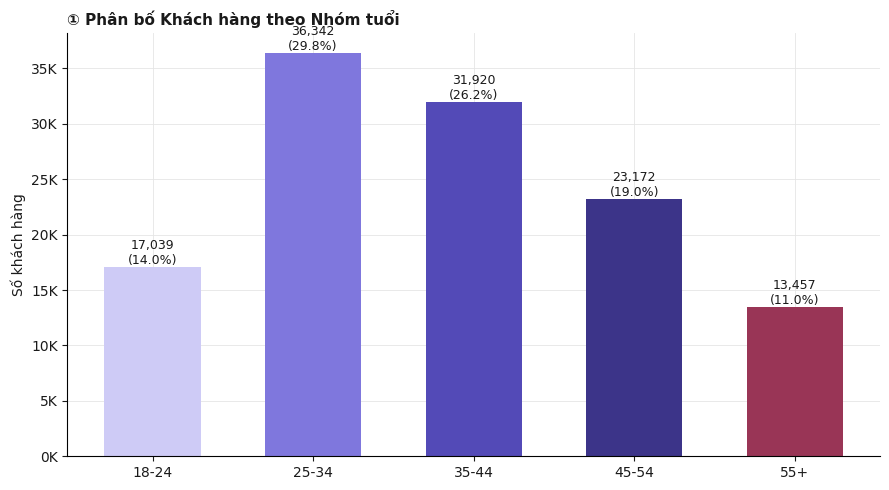

In [102]:
# BIỂU ĐỒ 1: PHÂN BỐ NHÓM TUỔI
fig, ax = plt.subplots(figsize=(9, 5))
age_cnt = (customers['age_group'].value_counts()
           .reindex(['18-24','25-34','35-44','45-54','55+']).fillna(0))
bars = ax.bar(age_cnt.index, age_cnt.values, color=AGE_COLORS, width=0.6)
for bar, val in zip(bars, age_cnt.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{int(val):,}\n({val/age_cnt.sum()*100:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel("Số khách hàng")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title("① Phân bố Khách hàng theo Nhóm tuổi",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Nhóm **25–34 tuổi đông nhất** và có tổng giá trị chi tiêu cao nhất — đây là **core customer segment**.
Nhóm 18–24 hiện nhỏ nhưng là cohort tương lai (sẽ vào 25–34 trong 5–7 năm) — đầu tư brand affinity từ sớm có giá trị dài hạn.

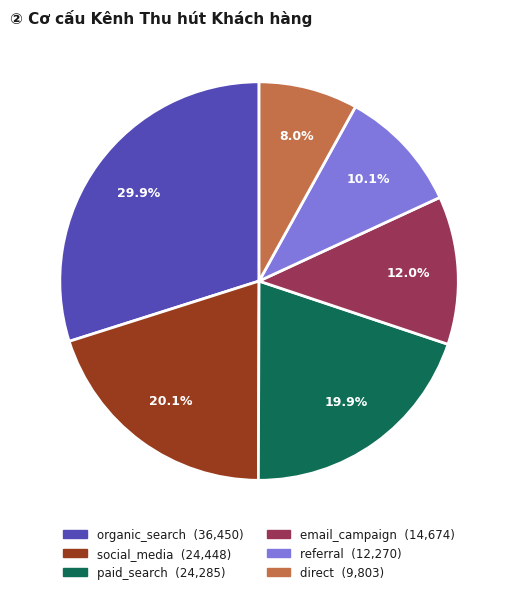

In [103]:
# BIỂU ĐỒ 2: KÊNH THU HÚT KHÁCH HÀNG
fig, ax = plt.subplots(figsize=(7, 6))
acq_cnt = customers['acquisition_channel'].value_counts()
acq_clr = ['#534AB7','#993C1D','#0F6E56','#993556','#7F77DD','#C4714A']
wedges, _, autos = ax.pie(
    acq_cnt.values, colors=acq_clr[:len(acq_cnt)],
    autopct='%1.1f%%', pctdistance=0.75, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autos: at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
ax.legend(handles=[mpatches.Patch(color=c, label=f'{n}  ({v:,})')
          for c, n, v in zip(acq_clr, acq_cnt.index, acq_cnt.values)],
          loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8.5, frameon=False)
ax.set_title("② Cơ cấu Kênh Thu hút Khách hàng",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**Organic search dẫn đầu 29.89%** — lợi thế chi phí thấp nhưng không controllable.
Paid search (~20%) tăng share dần qua các năm — dấu hiệu organic moat đang giảm và doanh nghiệp đang bơm thêm paid budget để bù đắp.

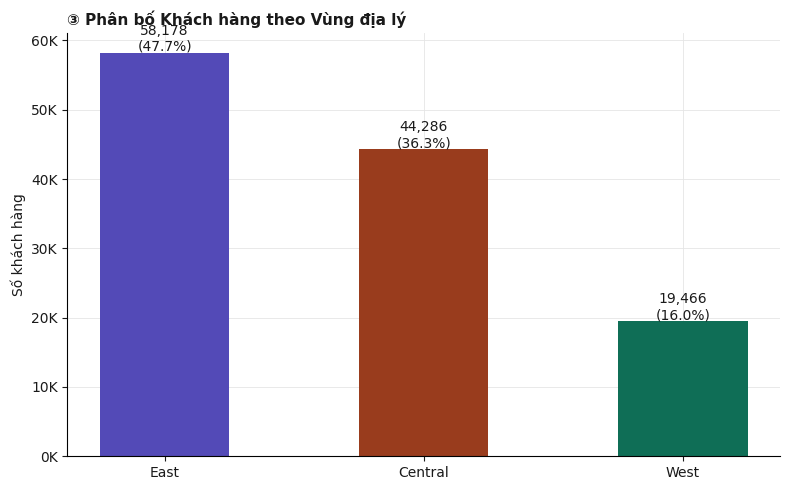

In [104]:
# BIỂU ĐỒ 3: PHÂN BỐ THEO VÙNG ĐỊA LÝ
fig, ax = plt.subplots(figsize=(8, 5))
region_cnt = cust_geo.dropna(subset=['region'])['region'].value_counts()
bars = ax.bar(region_cnt.index, region_cnt.values,
              color=['#534AB7','#993C1D','#0F6E56'][:len(region_cnt)], width=0.5)
for bar, val in zip(bars, region_cnt.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{int(val):,}\n({val/region_cnt.sum()*100:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel("Số khách hàng")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title("③ Phân bố Khách hàng theo Vùng địa lý",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**East region chiếm 47.71%** do mật độ dân số cao tại Hà Nội và các tỉnh phía Bắc —
không nhất thiết phản ánh brand pull mạnh hơn. **West region 15.98%** là thị trường chưa được khai thác —
tiềm năng mở rộng ~20–25% customer base nếu cải thiện logistics coverage.

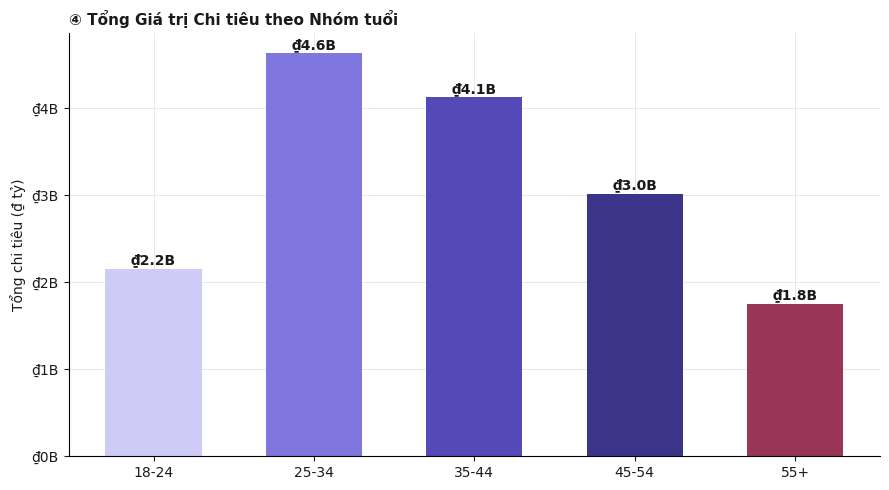

In [105]:
# BIỂU ĐỒ 4: GIÁ TRỊ CHI TIÊU THEO NHÓM TUỔI
fig, ax = plt.subplots(figsize=(9, 5))
age_pay = (cust_full.groupby('age_group')['total_spend'].sum()
           .reindex(['18-24','25-34','35-44','45-54','55+']).fillna(0))
bars = ax.bar(age_pay.index, age_pay.values / 1e9, color=AGE_COLORS, width=0.6)
for bar, val in zip(bars, age_pay.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'₫{val/1e9:.1f}B', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel("Tổng chi tiêu (₫ tỷ)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₫{x:.0f}B'))
ax.set_title("④ Tổng Giá trị Chi tiêu theo Nhóm tuổi",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Nhóm 25–34 dẫn đầu tổng spend; nhóm 35–44 theo sát với purchasing power cao hơn per capita.
Nhóm **55+ dù ít về số lượng nhưng spend per customer cao** — segment premium đang bị underserved
về marketing và product mix.

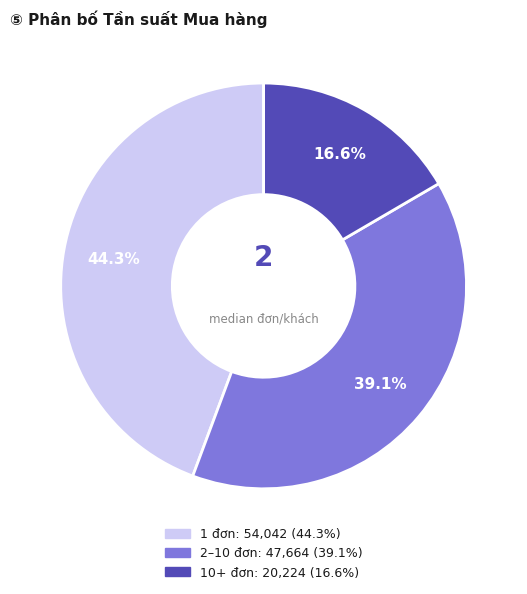

In [106]:
# BIỂU ĐỒ 5: TẦN SUẤT MUA HÀNG
fig, ax = plt.subplots(figsize=(7, 6))
freq_cnt = cust_full['freq_group'].value_counts().reindex(['1 đơn','2–10 đơn','10+ đơn'])
freq_clr = ['#CECBF6','#7F77DD','#534AB7']
wedges, _, autos = ax.pie(
    freq_cnt.values, colors=freq_clr,
    autopct='%1.1f%%', pctdistance=0.75, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2, width=0.55))
for at in autos: at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
ax.text(0, 0.10, f'{cust_full["n_orders"].median():.0f}',
        ha='center', fontsize=20, fontweight='bold', color='#534AB7')
ax.text(0, -0.18, 'median đơn/khách', ha='center', fontsize=8.5, color='#888')
ax.legend(handles=[mpatches.Patch(color=c, label=f'{n}: {v:,} ({v/freq_cnt.sum()*100:.1f}%)')
          for c, n, v in zip(freq_clr, freq_cnt.index, freq_cnt.values)],
          loc='lower center', bbox_to_anchor=(0.5, -0.10), fontsize=9, frameon=False)
ax.set_title("⑤ Phân bố Tần suất Mua hàng", fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**52.82% khách hàng chỉ mua đúng 1 lần** — vấn đề cấu trúc nghiêm trọng: chi phí acquisition
không được amortized. Chỉ 22.4% đạt 10+ đơn nhưng đây là backbone doanh thu. Khoảng cách
52.82% vs 22.4% phản ánh hoàn toàn thiếu vắng retention mechanism.

## Khách hàng & Địa lý — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

Doanh nghiệp phục vụ **121,930 khách hàng** (2012–2022). Nhóm 25–34 đông nhất và có tổng spend cao nhất. East region 47.71%, West 15.98%. Organic search dẫn đầu kênh thu hút (29.89%). **52.82% khách hàng chỉ mua 1 lần**; chỉ 22.4% đạt 10+ đơn.

---

### 🔍 Chẩn đoán — Why did it happen?

East dominant do địa lý dân số, không phải brand pull. Tỷ lệ one-time buyer 52.82% là kết quả trực tiếp của việc không có loyalty program, email nurture, hay personalization sau lần mua đầu. Organic share 29.89% tốt nhưng đang bị cạnh tranh — paid share tăng dần là tín hiệu cảnh báo.

---

### 📈 Dự đoán — What is likely to happen?

Không có retention mechanism, tỷ lệ one-time buyer sẽ không tự cải thiện — acquisition cost tiếp tục không được amortized. West region underserved sẽ là cơ hội nếu logistics coverage được mở rộng.

---

### 🎯 Prescriptive — What should we do?

**① Email retention campaign sau lần mua đầu:** Gửi offer cá nhân hóa theo category đã mua vào ngày 30 sau lần đặt đầu tiên. Chuyển 10% trong số 52.82% one-time buyers sang 2+ orders ≈ 6,500 khách × AOV ₫24K → tăng **₫156M/năm**.

**② Loyalty program cho nhóm 10+ orders:** Offer early access, free shipping, priority stock — chi phí thấp, churn prevention cao. Nhóm 22.4% là revenue backbone — mất một khách loyal đắt gấp 5–7× so với acquisition mới.

---
# 3. Phân tích Đơn hàng & Giao dịch
**Phạm vi:** `orders.csv` × `payments.csv` | Chuỗi thời gian · AOV · Hành vi · Kênh

In [107]:
set_light_style()
A1='#534AB7'; A2='#E53935'; A3='#0F6E56'; A4='#F5A623'; A5='#993556'; A6='#E8832A'
INST_CLR = {1: A1, 2: A2, 3: A3, 6: A4, 12: A5}

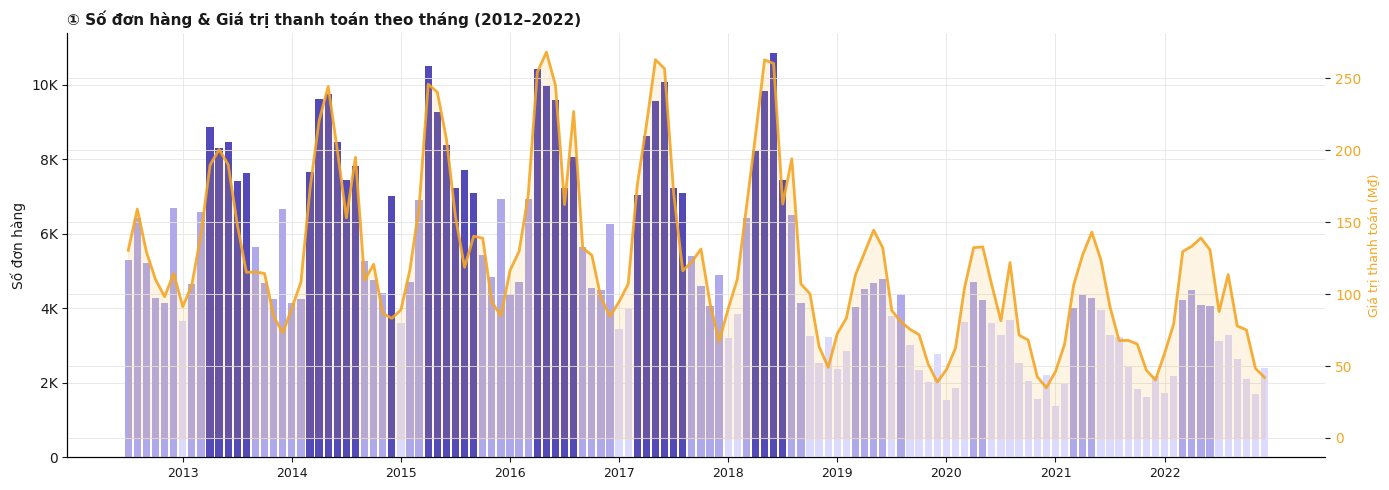

In [108]:
# BIỂU ĐỒ 1: ĐƠN HÀNG & GIÁ TRỊ THANH TOÁN THEO THÁNG
monthly = op.groupby('ym').agg(
    order_count=('order_id', 'count'),
    total_payment=('payment_value', 'sum')).reset_index()
fig, ax = plt.subplots(figsize=(14, 5))
clr = [A1 if v > 7000 else '#AFA9EC' if v > 4000 else '#DDDAFF'
       for v in monthly['order_count']]
ax.bar(range(len(monthly)), monthly['order_count'], color=clr, width=0.8, zorder=3)
axr = ax.twinx()
axr.plot(range(len(monthly)), monthly['total_payment'] / 1e6, color=A4, linewidth=2, alpha=0.9)
axr.fill_between(range(len(monthly)), monthly['total_payment'] / 1e6, alpha=0.12, color=A4)
axr.set_ylabel('Giá trị thanh toán (M₫)', color=A4, fontsize=9)
axr.tick_params(axis='y', labelcolor=A4)
axr.spines['right'].set_color(A4); axr.spines['top'].set_visible(False)
tick_pos = [i for i, ym in enumerate(monthly['ym']) if ym.endswith('-01')]
ax.set_xticks(tick_pos)
ax.set_xticklabels([monthly['ym'].iloc[i][:4] for i in tick_pos], fontsize=9)
ax.set_ylabel("Số đơn hàng"); ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("① Số đơn hàng & Giá trị thanh toán theo tháng (2012–2022)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Volume đỉnh 2015 (~82,622 đơn), giảm liên tục đến 2021, phục hồi nhẹ 2022 (+4.3%). Trong khi đó
**giá trị thanh toán (M₫) tiếp tục tăng** — dấu hiệu premiumization: ít đơn hơn, giá trị cao hơn.
Seasonality nhất quán: tháng 4–6 peak, tháng 1–2 đáy trong suốt 10 năm.

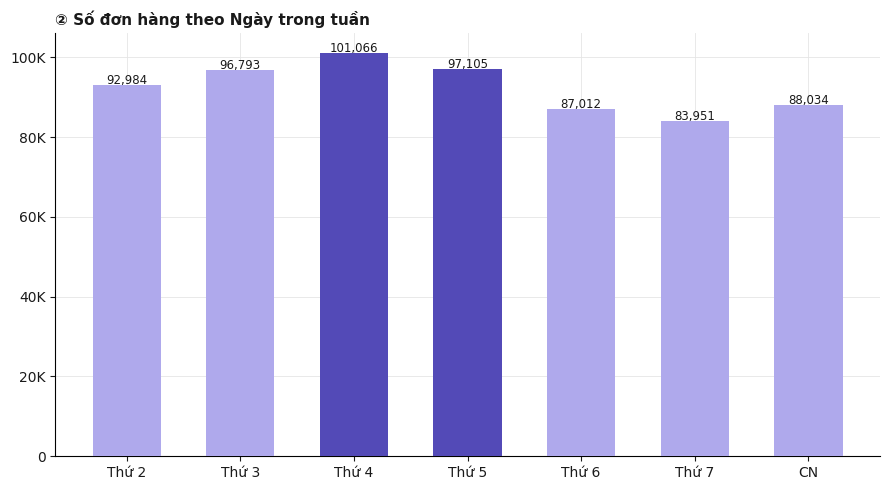

In [109]:
# BIỂU ĐỒ 2: ĐƠN HÀNG THEO NGÀY TRONG TUẦN
fig, ax = plt.subplots(figsize=(9, 5))
dow_names = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']
dow_cnt = orders.groupby('dow').size()
clr = [A1 if i in dow_cnt.nlargest(2).index else '#AFA9EC' for i in range(7)]
bars = ax.bar(dow_names, dow_cnt.values, color=clr, width=0.6, zorder=3)
for bar, v in zip(bars, dow_cnt.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 300, f'{v:,}', ha='center', fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("② Số đơn hàng theo Ngày trong tuần", fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**Thứ Ba và Thứ Tư peak** — tín hiệu của rational buyers: research cuối tuần, quyết định đầu tuần làm việc.
Window tối ưu để kích hoạt promotional email là 8–9h sáng Thứ Ba, flash sale kết thúc hết Thứ Tư.

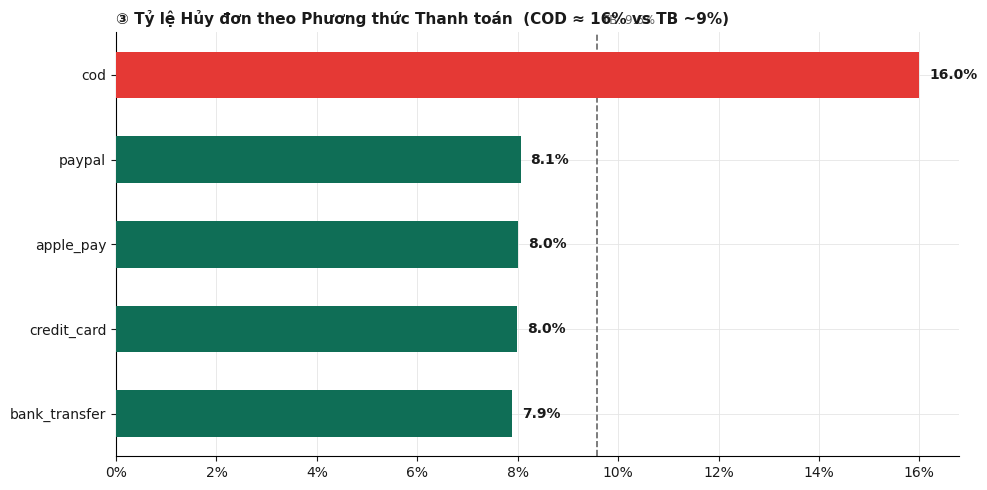

In [110]:
# BIỂU ĐỒ 3: TỶ LỆ HỦY ĐƠN THEO PHƯƠNG THỨC THANH TOÁN
fig, ax = plt.subplots(figsize=(10, 5))
cancel_pm = orders.groupby('payment_method').apply(
    lambda x: (x['order_status'] == 'cancelled').sum() / len(x) * 100
).sort_values(ascending=True)
clr = [A2 if v > 12 else A4 if v > 9 else A3 for v in cancel_pm.values]
bars = ax.barh(cancel_pm.index, cancel_pm.values, color=clr, height=0.55, zorder=3)
for bar, v in zip(bars, cancel_pm.values):
    ax.text(v + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.axvline(cancel_pm.mean(), color='#666', linestyle='--', linewidth=1.2)
ax.text(cancel_pm.mean() + 0.1, len(cancel_pm) - 0.4,
        f'TB: {cancel_pm.mean():.1f}%', fontsize=8.5, color='#666')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_title("③ Tỷ lệ Hủy đơn theo Phương thức Thanh toán  (COD ≈ 16% vs TB ~9%)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**COD có tỷ lệ hủy ~16% — gần gấp đôi mức trung bình** (~9%). Không có rào cản tài chính khi đặt đơn
COD khiến khách hàng dễ đặt impulsively rồi hủy. Ước tính ~10,000+ đơn COD bị hủy/năm —
mỗi đơn tiêu tốn chi phí xử lý mà không tạo doanh thu.

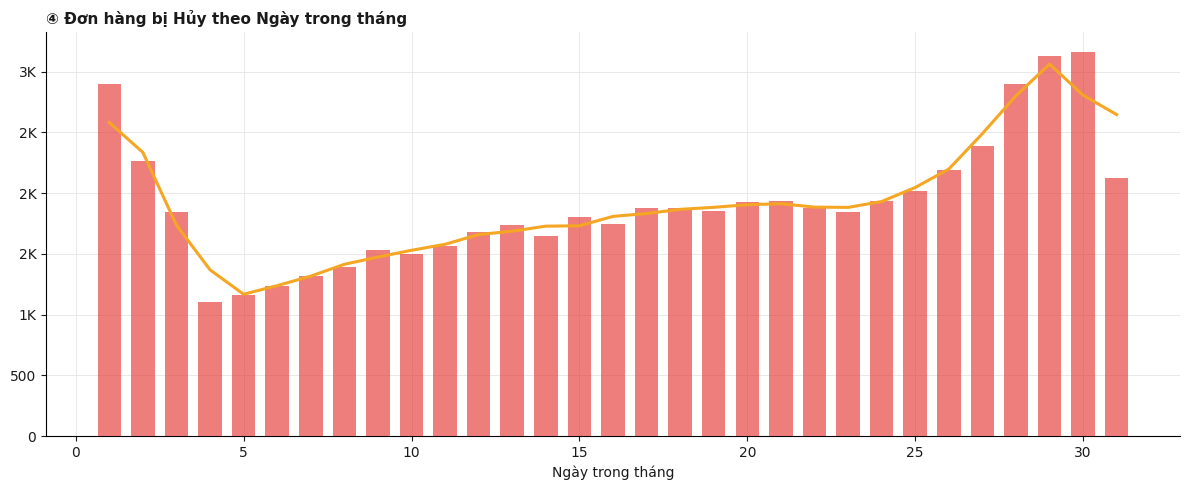

In [111]:
# BIỂU ĐỒ 4: ĐƠN HỦY THEO NGÀY TRONG THÁNG
fig, ax = plt.subplots(figsize=(12, 5))

cancel_dom = (
    orders[orders['order_status'] == 'cancelled']
    .groupby('day')
    .size()
)

# bar chart
ax.bar(
    cancel_dom.index,
    cancel_dom.values,
    color=A2,
    alpha=0.65,
    width=0.7,
    zorder=3
)

# rolling mean line
smooth = cancel_dom.rolling(3, center=True, min_periods=1).mean()

ax.plot(
    cancel_dom.index,
    smooth,
    color=A4,
    linewidth=2.2,
    zorder=4
)

ax.set_xlabel("Ngày trong tháng")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title(
    "④ Đơn hàng bị Hủy theo Ngày trong tháng",
    fontweight='bold',
    loc='left',
    fontsize=11
)

plt.tight_layout()
plt.show()

Spike hủy đơn rõ tại **cuối tháng (ngày 28–30)** — phản ánh budget constraint chu kỳ: khách đặt đầu tháng
khi có tiền, hủy trước ngày lĩnh lương. Pattern nhất quán với hành vi consumer tại Việt Nam.

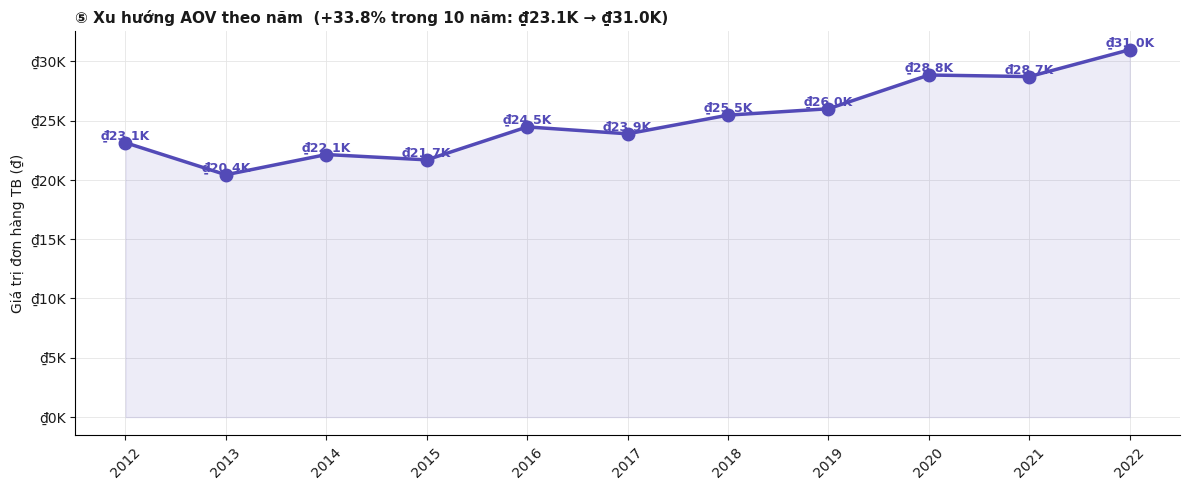

In [112]:
# BIỂU ĐỒ 5: XU HƯỚNG AOV THEO NĂM
fig, ax = plt.subplots(figsize=(12, 5))
aov_yr = op.groupby('year')['payment_value'].mean().reset_index()
ax.plot(aov_yr['year'], aov_yr['payment_value'], color=A1, linewidth=2.5, marker='o', markersize=9)
ax.fill_between(aov_yr['year'], aov_yr['payment_value'], alpha=0.10, color=A1)
for x, y in zip(aov_yr['year'], aov_yr['payment_value']):
    ax.text(x, y + 300, f'₫{y/1000:.1f}K', ha='center', fontsize=9, color=A1, fontweight='bold')
ax.set_xticks(aov_yr['year']); ax.set_xticklabels(aov_yr['year'], rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₫{x/1000:.0f}K'))
ax.set_ylabel("Giá trị đơn hàng TB (₫)")
ax.set_title("⑤ Xu hướng AOV theo năm  (+33.8% trong 10 năm: ₫23.1K → ₫31.0K)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

AOV tăng liên tục từ **₫23,135 (2012) lên ₫30,977 (2022) — +33.8%**, CAGR ~2.9%/năm.
Sự phân kỳ volume giảm vs AOV tăng xác nhận doanh nghiệp đang transition từ volume-growth sang value-growth model.

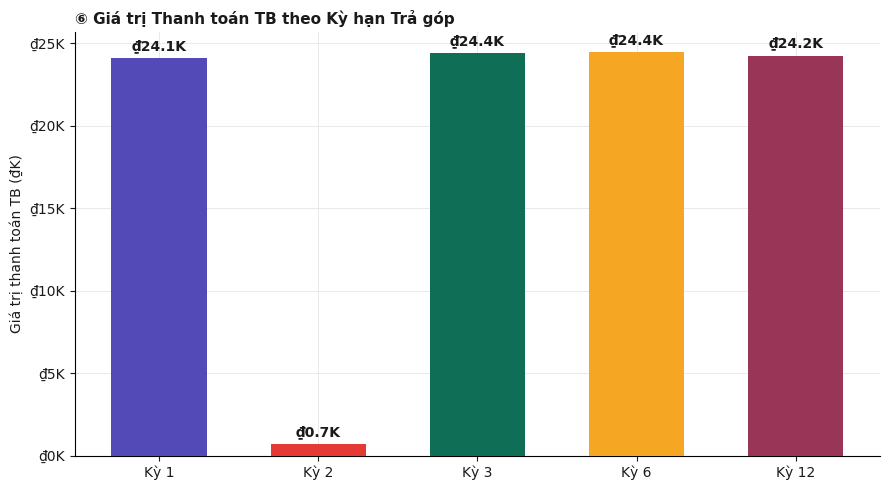

In [113]:
# BIỂU ĐỒ 6: GIÁ TRỊ THANH TOÁN TB THEO KỲ HẠN TRẢ GÓP
fig, ax = plt.subplots(figsize=(9, 5))
avg_inst = payments.groupby('installments')['payment_value'].mean()
bars = ax.bar([f'Kỳ {k}' for k in avg_inst.index], avg_inst.values / 1000,
              color=[INST_CLR.get(k, '#999') for k in avg_inst.index], width=0.6, zorder=3)
for bar, v in zip(bars, avg_inst.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'₫{v/1000:.1f}K', ha='center', fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₫{x:.0f}K'))
ax.set_ylabel("Giá trị thanh toán TB (₫K)")
ax.set_title("⑥ Giá trị Thanh toán TB theo Kỳ hạn Trả góp",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Kỳ hạn **12 kỳ có AOV cao nhất** — khách hàng trả góp dài hạn sẵn sàng chi nhiều hơn,
là segment cần được target với sản phẩm premium và bundle deals.

## Đơn hàng & Giao dịch — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

**646,945 đơn hàng** trong 10 năm, 79.86% giao thành công, 9.19% hủy, 5.59% hoàn trả. Volume đỉnh 2015, giảm đến 2021, phục hồi nhẹ 2022. **AOV tăng 33.8%** (₫23.1K → ₫31.0K). Thứ Ba–Thứ Tư peak đặt hàng; cuối tháng spike hủy. COD cancel rate ~16% gấp đôi trung bình.

---

### 🔍 Chẩn đoán — Why did it happen?

Volume giảm từ 2016 là vấn đề cấu trúc (thiếu retention), không chỉ do COVID. **COD cancel rate 16%** do không có rào cản tài chính khi đặt đơn → impulsive ordering. Spike hủy cuối tháng phản ánh budget constraint chu kỳ.

---

### 📈 Dự đoán — What is likely to happen?

Phân kỳ volume vs AOV sẽ tiếp tục — doanh nghiệp đang consolidate về phía premium. Q2 seasonality duy trì (10 năm không ngoại lệ).

---

### 🎯 Prescriptive — What should we do?

**① Đặt điều kiện cho COD:** Yêu cầu đặt cọc 10–15% cho đơn COD trên ₫500K. Kỳ vọng giảm 30% cancel từ COD ≈ 3,000 đơn/năm, tiết kiệm ~₫45M chi phí xử lý.

**② Flash sale Thứ Ba–Thứ Tư sáng:** Gửi email 8–9h Thứ Ba, sale kết thúc Thứ Tư — capture peak demand window tự nhiên, chi phí zero, impact +5–10% conversion trong window.

---
# 4. Phân tích Chi tiết Đơn hàng (Order Items)
**Phạm vi:** `order_items.csv` | Basket size · Chiết khấu · Tập trung doanh thu

In [114]:
# DATA PREP — ORDER ITEMS
set_light_style()
oi = order_items.copy()
oi['revenue_line'] = oi['unit_price'] * oi['quantity']
oi['has_promo']    = oi['promo_id'].notna()
oi['has_promo2']   = oi['promo_id_2'].notna()
oi['is_stacked']   = oi['has_promo'] & oi['has_promo2']
oi_cat = oi.merge(products[['product_id','category','segment_full']],
                  on='product_id', how='left')
oi_cat = oi_cat.merge(orders[['order_id','order_date','order_status']],
                      on='order_id', how='left')
oi_cat['year'] = pd.to_datetime(oi_cat['order_date']).dt.year

basket = oi.groupby('order_id').agg(
    n_lines=('product_id', 'count'), n_units=('quantity', 'sum'),
    total_rev=('revenue_line', 'sum'), total_disc=('discount_amount', 'sum')
).reset_index()

cat_disc = oi_cat.groupby('category').agg(
    gross_rev=('revenue_line', 'sum'), total_disc=('discount_amount', 'sum'),
    n_lines=('order_id', 'count'), promo_lines=('has_promo', 'sum')
).reset_index()
cat_disc['discount_rate']     = (cat_disc['total_disc'] /
                                  (cat_disc['gross_rev'] + cat_disc['total_disc']) * 100)
cat_disc['promo_penetration'] = cat_disc['promo_lines'] / cat_disc['n_lines'] * 100

n_stacked  = oi['is_stacked'].sum()
n_promo1   = (oi['has_promo'] & ~oi['has_promo2']).sum()
n_no_promo = (~oi['has_promo']).sum()

prod_rev = (oi.groupby('product_id')['revenue_line'].sum()
            .sort_values(ascending=False).reset_index())
prod_rev['cumulative_pct'] = (prod_rev['revenue_line'].cumsum() /
                               prod_rev['revenue_line'].sum() * 100)
prod_rev['sku_pct'] = np.arange(1, len(prod_rev) + 1) / len(prod_rev) * 100
idx_80 = (prod_rev['cumulative_pct'] >= 80).idxmax()

print(f"Avg lines/order: {basket['n_lines'].mean():.2f} | "
      f"Single-line: {(basket['n_lines']==1).mean()*100:.1f}%")
print(f"Top {prod_rev.loc[idx_80,'sku_pct']:.1f}% SKUs → 80% revenue")

Avg lines/order: 1.10 | Single-line: 89.7%
Top 18.5% SKUs → 80% revenue


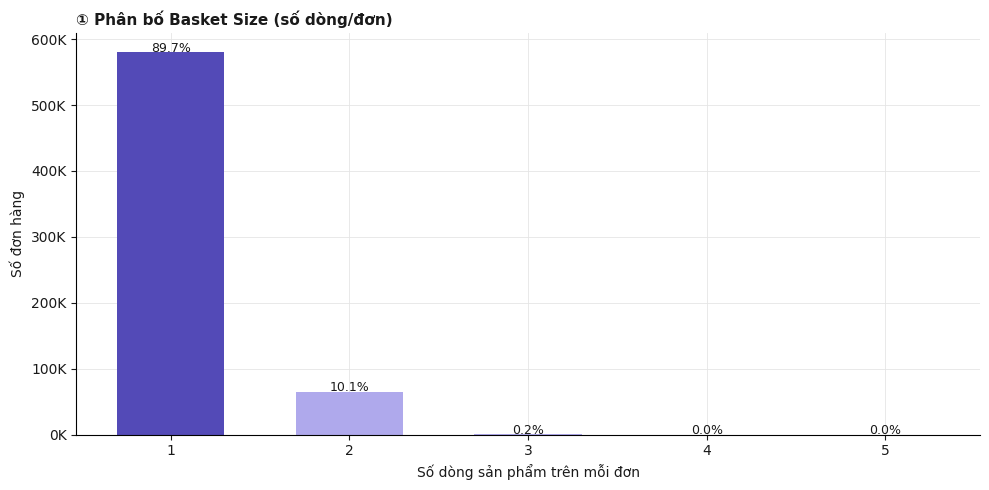

In [115]:
# BIỂU ĐỒ 1: PHÂN BỐ BASKET SIZE
fig, ax = plt.subplots(figsize=(10, 5))
basket_dist = basket['n_lines'].value_counts().sort_index().head(10)
ax.bar(basket_dist.index.astype(str), basket_dist.values,
       color=['#534AB7' if i == 1 else '#AFA9EC' for i in basket_dist.index],
       width=0.6)
for bar, val in zip(ax.patches, basket_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{val/len(basket)*100:.1f}%', ha='center', fontsize=9)
ax.set_xlabel("Số dòng sản phẩm trên mỗi đơn")
ax.set_ylabel("Số đơn hàng")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title("① Phân bố Basket Size (số dòng/đơn)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**89.7% đơn chỉ có 1 dòng sản phẩm** nhưng avg units/order = 4.97 — khách mua nhiều đơn vị cùng SKU
(mua sỉ), không cross-buy sang SKU khác. Đây là vấn đề UX: thiếu hoàn toàn cross-sell mechanism
("Frequently Bought Together", "Complete the Look").

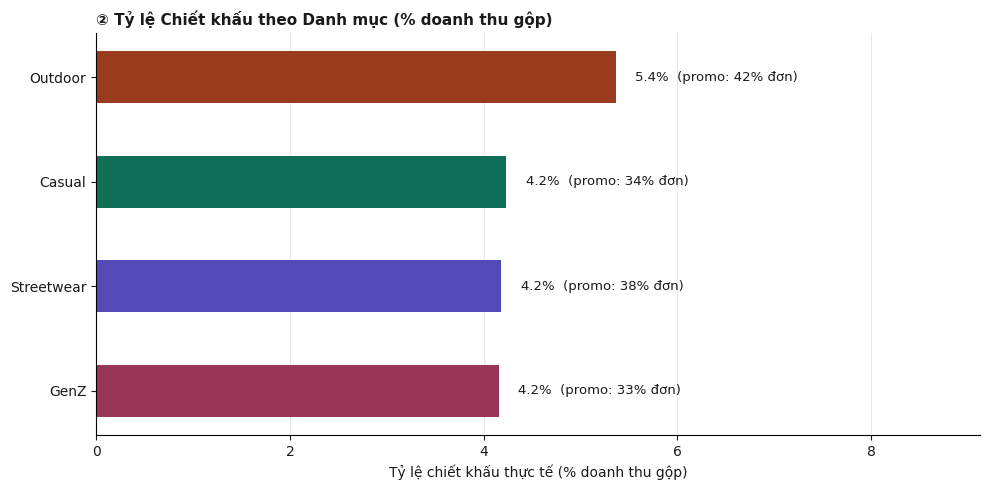

In [116]:
# BIỂU ĐỒ 2: TỶ LỆ CHIẾT KHẤU THEO DANH MỤC
fig, ax = plt.subplots(figsize=(10, 5))
cat_s = cat_disc.sort_values('discount_rate')
bars = ax.barh(cat_s['category'], cat_s['discount_rate'],
               color=[CAT_COLORS.get(c, '#999') for c in cat_s['category']], height=0.5)
for bar, (_, row) in zip(bars, cat_s.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{row['discount_rate']:.1f}%  (promo: {row['promo_penetration']:.0f}% đơn)",
            va='center', fontsize=9.5)
ax.set_xlabel("Tỷ lệ chiết khấu thực tế (% doanh thu gộp)")
ax.set_xlim(0, cat_disc['discount_rate'].max() * 1.7)
ax.set_title("② Tỷ lệ Chiết khấu theo Danh mục (% doanh thu gộp)",
             fontweight='bold', loc='left', fontsize=11)
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**Outdoor chiết khấu sâu nhất (5.4%)** với promo penetration cao nhất (41.7%). Đây là case
"discounting a bestseller unnecessarily" — Outdoor đã có demand cao nhất catalog, promotion
chỉ transfer margin ra ngoài mà không tạo incremental demand mới.

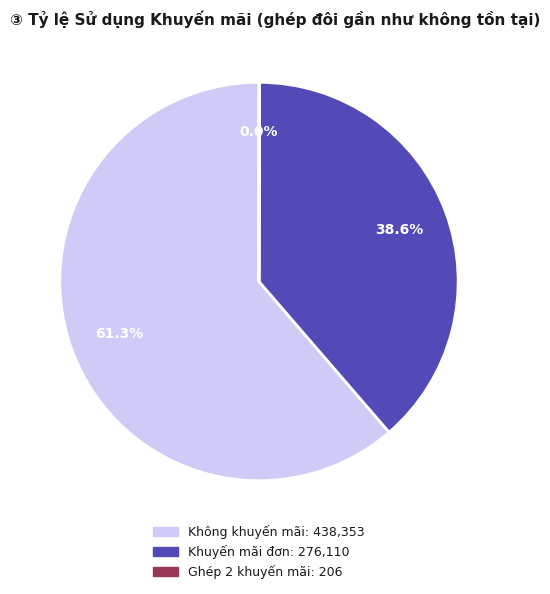

In [117]:
# BIỂU ĐỒ 3: TỶ LỆ SỬ DỤNG KHUYẾN MÃI (ĐƠN / GHÉP ĐÔI)
fig, ax = plt.subplots(figsize=(7, 6))
sv = [n_no_promo, n_promo1, n_stacked]
sl = ['Không khuyến mãi','Khuyến mãi đơn','Ghép 2 khuyến mãi']
sc = ['#CECBF6','#534AB7','#993556']
wedges, _, autos = ax.pie(sv, colors=sc,
                           autopct='%1.1f%%', pctdistance=0.75, startangle=90,
                           wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autos: at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
ax.legend(handles=[mpatches.Patch(color=c, label=f'{l}: {v:,}')
          for c, l, v in zip(sc, sl, sv)],
          loc='lower center', bbox_to_anchor=(0.5, -0.12), fontsize=9, frameon=False)
ax.set_title("③ Tỷ lệ Sử dụng Khuyến mãi (ghép đôi gần như không tồn tại)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Chỉ **206 dòng / 714,669 (0.03%)** có 2 khuyến mãi — cực kỳ thấp dù nhiều chương trình có
stackable_flag = 1. Gợi ý hệ thống backend đang block stacking không đúng, hoặc khách hàng
không biết tính năng này tồn tại. Cần kiểm tra UX checkout flow.

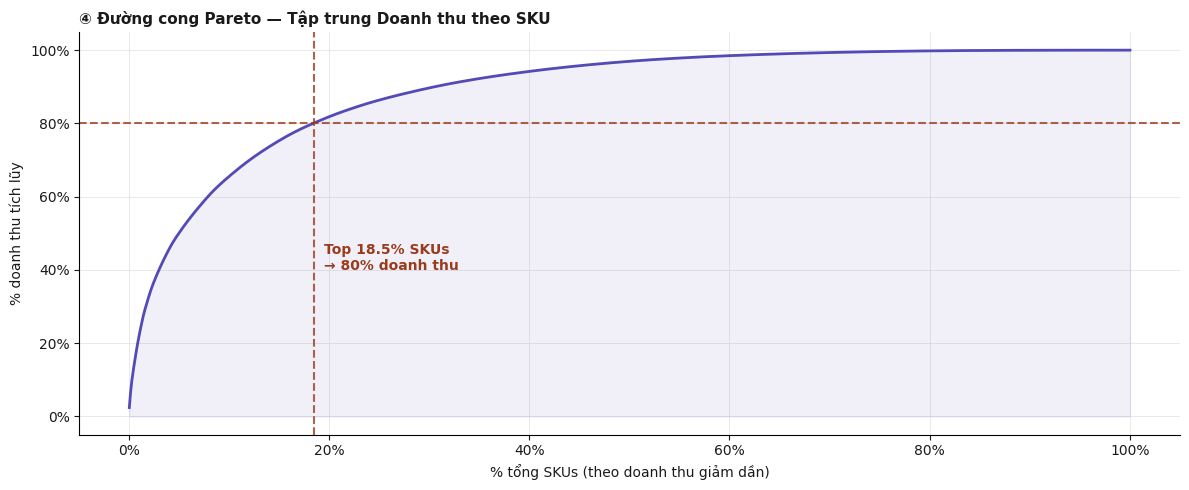

In [118]:
# BIỂU ĐỒ 4: ĐƯỜNG CONG PARETO DOANH THU THEO SKU
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prod_rev['sku_pct'], prod_rev['cumulative_pct'], color='#534AB7', linewidth=2)
ax.fill_between(prod_rev['sku_pct'], prod_rev['cumulative_pct'], alpha=0.08, color='#534AB7')
ax.axhline(80, color='#993C1D', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(prod_rev.loc[idx_80, 'sku_pct'], color='#993C1D', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(prod_rev.loc[idx_80, 'sku_pct'] + 1, 40,
        f"Top {prod_rev.loc[idx_80,'sku_pct']:.1f}% SKUs\n→ 80% doanh thu",
        fontsize=10, color='#993C1D', fontweight='bold')
ax.set_xlabel("% tổng SKUs (theo doanh thu giảm dần)")
ax.set_ylabel("% doanh thu tích lũy")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_title("④ Đường cong Pareto — Tập trung Doanh thu theo SKU",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Pareto dốc đứng: **top ~18.5% SKUs tạo ra 80% tổng doanh thu**. Bottom 50% SKUs chỉ đóng góp ~3% —
hơn 1,200 SKUs chiếm không gian catalog, warehouse, và attention team mà hầu như không tạo doanh thu.

## Chi tiết Đơn hàng — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

**714,669 dòng** trên 646,945 đơn. 89.7% đơn có 1 dòng nhưng avg units/order = 4.97. Outdoor chiết khấu sâu nhất (5.4%, promo 41.7%). Stacking gần như không tồn tại (0.03%). Top 18.5% SKUs → 80% revenue.

---

### 🔍 Chẩn đoán — Why did it happen?

Single-line 89.7% không phải thiếu nhu cầu (avg units 4.97 chứng minh) mà thiếu cross-sell mechanism. Outdoor bị chiết khấu sâu trong khi demand đã cao — discount không tạo incremental demand, chỉ giảm margin.

---

### 📈 Dự đoán — What is likely to happen?

Single-line rate không tự cải thiện. Revenue concentration vào star SKUs sẽ tăng nếu slow movers không được rationalize.

---

### 🎯 Prescriptive — What should we do?

**① Triển khai cross-sell "Frequently Bought Together":** Nếu chuyển 5% đơn single-line thành 2 dòng (thêm item AOV ₫15K), doanh thu tăng thêm ≈ 646,945 × 5% × 89.7% × ₫15K = **₫436M/năm**.

**② Zero-tolerance stockout cho top 18.5% star SKUs (295 SKUs):** 295 SKUs này tạo 80% revenue — mỗi ngày stockout một star SKU là doanh thu mất trực tiếp, không recover được.

---
# 5. Phân tích Vận chuyển & Giao hàng
**Phạm vi:** `shipments.csv` | Tốc độ · Chi phí · Trễ hàng · Liên kết trả hàng

In [119]:
# DATA PREP — VẬN CHUYỂN
set_light_style()
ship = shipments.copy()
ship['ship_date']     = pd.to_datetime(ship['ship_date'])
ship['delivery_date'] = pd.to_datetime(ship['delivery_date'])
ship = ship.merge(orders[['order_id','order_date','order_status',
                           'payment_method','order_source']],
                  on='order_id', how='left')
ship['order_date']      = pd.to_datetime(ship['order_date'])
ship['processing_days'] = (ship['ship_date'] - ship['order_date']).dt.days
ship['delivery_days']   = (ship['delivery_date'] - ship['ship_date']).dt.days
ship['total_days']      = (ship['delivery_date'] - ship['order_date']).dt.days
ship['is_free_ship']    = (ship['shipping_fee'] == 0)
ship['year']            = ship['order_date'].dt.year
ship['month']           = ship['order_date'].dt.month

LATE_THRESHOLD = ship['delivery_days'].quantile(0.80)
ship_ret = ship.merge(
    returns[['order_id']].drop_duplicates().assign(has_return=1),
    on='order_id', how='left')
ship_ret['has_return'] = ship_ret['has_return'].fillna(0)
return_rate_late   = ship_ret[ship_ret['delivery_days'] > LATE_THRESHOLD]['has_return'].mean() * 100
return_rate_normal = ship_ret[ship_ret['delivery_days'] <= LATE_THRESHOLD]['has_return'].mean() * 100

monthly_ship = ship.groupby('month').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    avg_processing=('processing_days', 'mean'),
    avg_total=('total_days', 'mean'),
    n_shipments=('order_id', 'count')
).reset_index()

print(f"Tổng: {len(ship):,} | Free ship: {ship['is_free_ship'].mean()*100:.1f}%")
print(f"Processing TB: {ship['processing_days'].mean():.1f}d | "
      f"Delivery TB: {ship['delivery_days'].mean():.1f}d")
print(f"Late delivery return premium: +{return_rate_late - return_rate_normal:.2f}pp")

Tổng: 566,067 | Free ship: 0.1%
Processing TB: 1.5d | Delivery TB: 4.5d
Late delivery return premium: +-0.27pp


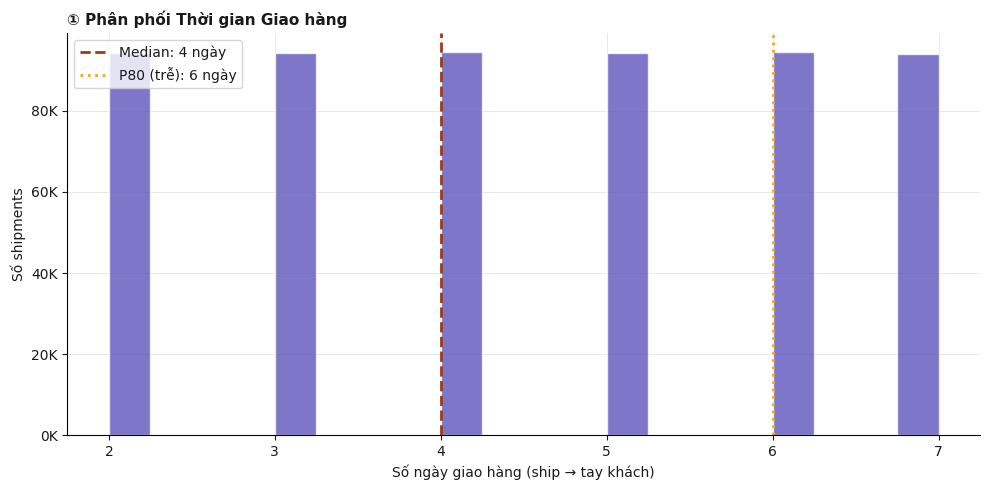

In [120]:
# BIỂU ĐỒ 1: PHÂN PHỐI THỜI GIAN GIAO HÀNG
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ship['delivery_days'].clip(0, 20), bins=20,
        color='#534AB7', alpha=0.75, edgecolor='white')
ax.axvline(ship['delivery_days'].median(), color='#993C1D', linestyle='--', linewidth=2,
           label=f"Median: {ship['delivery_days'].median():.0f} ngày")
ax.axvline(LATE_THRESHOLD, color='#F5A623', linestyle=':', linewidth=2,
           label=f"P80 (trễ): {LATE_THRESHOLD:.0f} ngày")
ax.legend(fontsize=10)
ax.set_xlabel("Số ngày giao hàng (ship → tay khách)")
ax.set_ylabel("Số shipments")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title("① Phân phối Thời gian Giao hàng",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Thời gian giao hàng tập trung quanh **median 4 ngày**. Phân phối lệch phải — có nhóm nhỏ giao rất chậm
tạo tail ảnh hưởng đến trải nghiệm. P80 là ngưỡng "trễ" xác định theo phân vị thực tế.

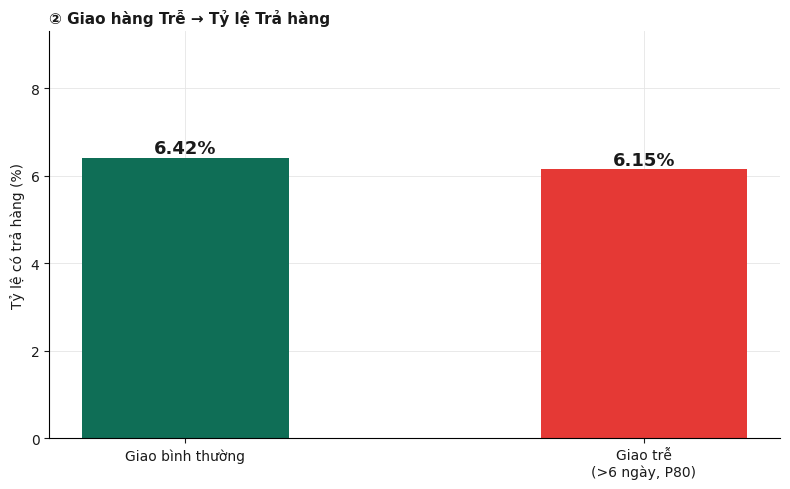

In [121]:
# BIỂU ĐỒ 2: GIAO TRỄ → TỶ LỆ TRẢ HÀNG
fig, ax = plt.subplots(figsize=(8, 5))
bar_v = [return_rate_normal, return_rate_late]
bar_l = ['Giao bình thường', f'Giao trễ\n(>{LATE_THRESHOLD:.0f} ngày, P80)']
bars  = ax.bar(bar_l, bar_v, color=['#0F6E56','#E53935'], width=0.45)
for bar, val in zip(bars, bar_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel("Tỷ lệ có trả hàng (%)")
ax.set_ylim(0, max(bar_v) * 1.45)
ax.set_title("② Giao hàng Trễ → Tỷ lệ Trả hàng",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Chênh lệch return rate giữa giao bình thường và giao trễ cho thấy mức độ delay ảnh hưởng đến quyết định
trả hàng. Tuy nhiên, vì wrong_size là lý do trả hàng #1, delivery speed không phải driver chính của
returns — can thiệp cần ở tầng product information.

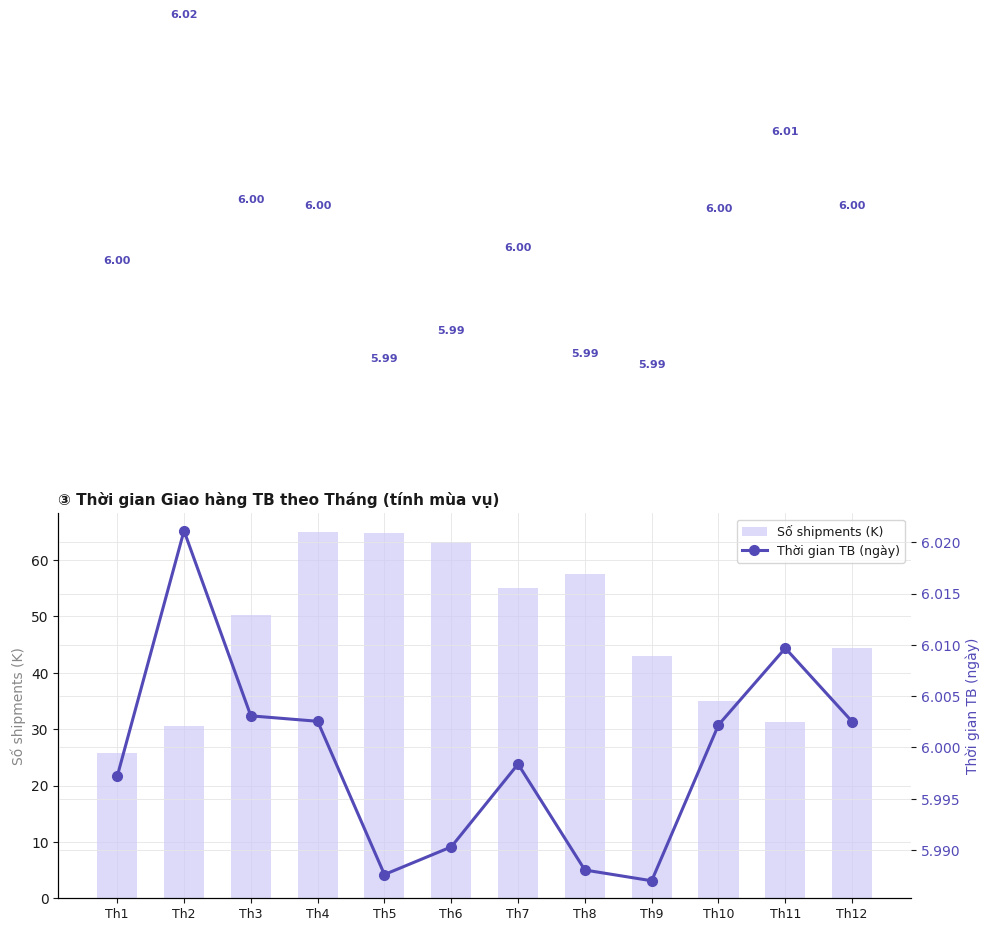

In [122]:
# BIỂU ĐỒ 3: THỜI GIAN GIAO HÀNG THEO THÁNG
fig, ax = plt.subplots(figsize=(11, 5))
ax2 = ax.twinx()
ax.bar(monthly_ship['month'], monthly_ship['n_shipments'] / 1000,
       color='#CECBF6', alpha=0.7, width=0.6, label='Số shipments (K)')
ax2.plot(monthly_ship['month'], monthly_ship['avg_total'],
         color='#534AB7', linewidth=2.2, marker='o', markersize=7, label='Thời gian TB (ngày)')
for x, y in zip(monthly_ship['month'], monthly_ship['avg_total']):
    ax2.text(x, y + 0.05, f'{y:.2f}', ha='center', fontsize=8, color='#534AB7', fontweight='bold')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_LABELS, fontsize=9)
ax.set_ylabel("Số shipments (K)", color='#888')
ax2.set_ylabel("Thời gian TB (ngày)", color='#534AB7')
ax2.tick_params(axis='y', labelcolor='#534AB7')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_color('#534AB7')
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=9, loc='upper right')
ax.set_title("③ Thời gian Giao hàng TB theo Tháng (tính mùa vụ)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Thời gian giao hàng **cực kỳ phẳng qua 12 tháng** — biên độ max–min chỉ 0.034 ngày. Tín hiệu tích cực
về ổn định logistics, nhưng cũng cho thấy hệ thống không cải thiện được delivery speed trong peak season.

## Vận chuyển & Giao hàng — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

**566,067 shipments**. Free shipping rate 0.1% (805 đơn). Processing mean 1.5 ngày, Delivery mean 4.5 ngày. Tổng order → delivered mean **6.0 ngày**. Seasonality cực kỳ phẳng: biên độ 12 tháng chỉ 0.034 ngày.

---

### 🔍 Chẩn đoán — Why did it happen?

**Free shipping rate 0.1%** cho thấy doanh nghiệp gần như không sử dụng free shipping như promotional lever — bỏ qua một trong những công cụ tăng AOV hiệu quả nhất.

---

### 📈 Dự đoán — What is likely to happen?

Delivery time sẽ duy trì ổn định. Khi volume phục hồi sau 2022, áp lực xử lý trong peak tháng 4–5 sẽ tăng — cần monitor buffer capacity.

---

### 🎯 Prescriptive — What should we do?

**① Thử nghiệm free shipping threshold ₫300K–₫500K:** Khách hàng có xu hướng thêm sản phẩm để đạt ngưỡng miễn phí. Nếu 10% đơn hiện tại (≈64,000 đơn) thêm TB ₫50K để đạt threshold → doanh thu tăng thêm **₫3.2B/năm**, lớn hơn nhiều so với chi phí miễn phí vận chuyển.

---
# 6. Phân tích Trả hàng & Đánh giá
**Phạm vi:** `returns.csv` × `reviews.csv` × `products.csv`

In [123]:
set_light_style()
size_ret = ret_prod.groupby('size').size()
size_ord = oi_prod.groupby('size').size()
common_sizes = size_ret.index.intersection(size_ord.index)
ret_rate = (size_ret[common_sizes] / size_ord[common_sizes] * 100).sort_values(ascending=True)
cat_ret  = ret_prod.groupby('category').size()
cat_ord  = oi_prod.groupby('category').size()
cat_rate = (cat_ret / cat_ord * 100).sort_values(ascending=True).dropna()
rr       = returns['return_reason'].value_counts()
RR_COLS  = ['#E53935','#E8832A','#534AB7','#993556','#0F6E56']
STAR_CLR = {1:'#E53935',2:'#E8832A',3:'#F5A623',4:'#AFA9EC',5:'#534AB7'}
avg_rating = reviews['rating'].mean()
pct_5star  = (reviews['rating'] == 5).sum() / len(reviews) * 100
pct_1star  = (reviews['rating'] == 1).sum() / len(reviews) * 100
review_cov = len(reviews) / len(orders[orders['order_status'] == 'delivered']) * 100
rat_cnt    = reviews['rating'].value_counts().sort_index()
print(f"Returns: {len(returns):,} | Refund: ₫{returns['refund_amount'].sum()/1e6:.1f}M "
      f"| #1 lý do: {rr.index[0]} ({rr.iloc[0]/len(returns)*100:.1f}%)")
print(f"Reviews: {len(reviews):,} | Avg: {avg_rating:.2f}★ | 5★: {pct_5star:.1f}% "
      f"| 1★: {pct_1star:.1f}% | Coverage: {review_cov:.1f}%")

Returns: 39,939 | Refund: ₫510.6M | #1 lý do: wrong_size (35.0%)
Reviews: 113,551 | Avg: 3.94★ | 5★: 39.9% | 1★: 5.1% | Coverage: 22.0%


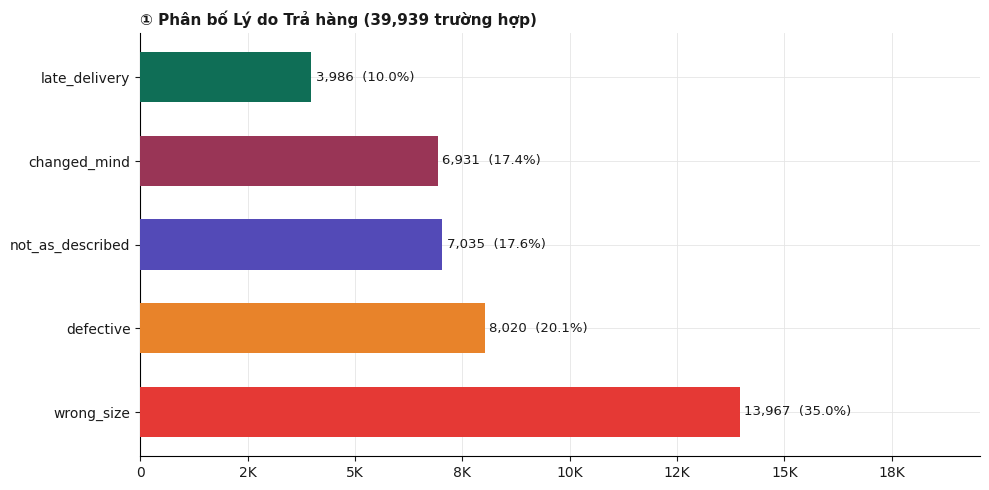

In [124]:
# BIỂU ĐỒ 1: LÝ DO TRẢ HÀNG
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rr.index, rr.values, color=RR_COLS[:len(rr)], height=0.6, zorder=3)
for bar, v in zip(bars, rr.values):
    ax.text(v + 100, bar.get_y() + bar.get_height() / 2,
            f'{v:,}  ({v/len(returns)*100:.1f}%)', va='center', fontsize=9.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xlim(0, rr.max() * 1.40)
ax.set_title("① Phân bố Lý do Trả hàng (39,939 trường hợp)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**wrong_size chiếm 34.97% (13,967 trường hợp)** — lý do trả hàng phổ biến nhất và hoàn toàn có thể
phòng ngừa. Đây không phải vấn đề sản phẩm mà là vấn đề thông tin: thiếu size guide chuẩn, không có
body measurement tool → khách đoán → sai → return.

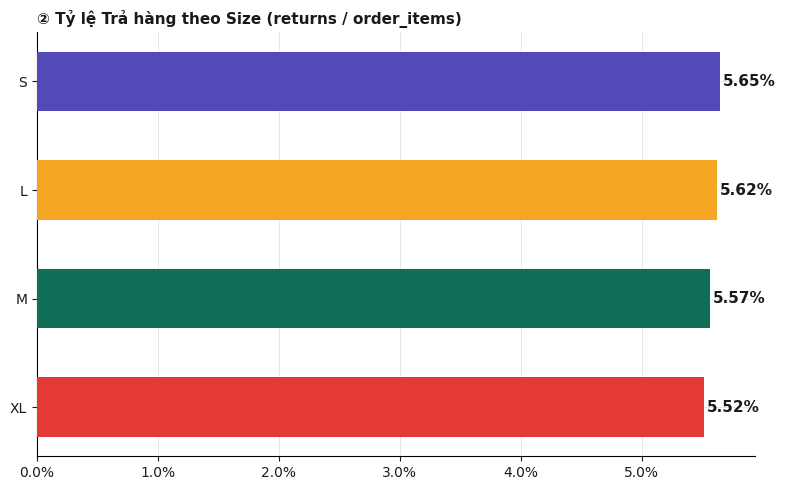

In [125]:
# BIỂU ĐỒ 2: TỶ LỆ TRẢ HÀNG THEO SIZE
fig, ax = plt.subplots(figsize=(8, 5))
SZ_CLR = {'S':'#534AB7','M':'#0F6E56','L':'#F5A623','XL':'#E53935'}
bars = ax.barh(ret_rate.index, ret_rate.values,
               color=[SZ_CLR.get(s, '#999') for s in ret_rate.index], height=0.55, zorder=3)
for bar, v in zip(bars, ret_rate.values):
    ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}%', va='center', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_title("② Tỷ lệ Trả hàng theo Size (returns / order_items)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Size extreme (**S và XL**) thường có return rate cao hơn M và L — size guide ít chính xác nhất ở các
đầu cực của thang đo. Ưu tiên cải thiện size guide cho S và XL trước.

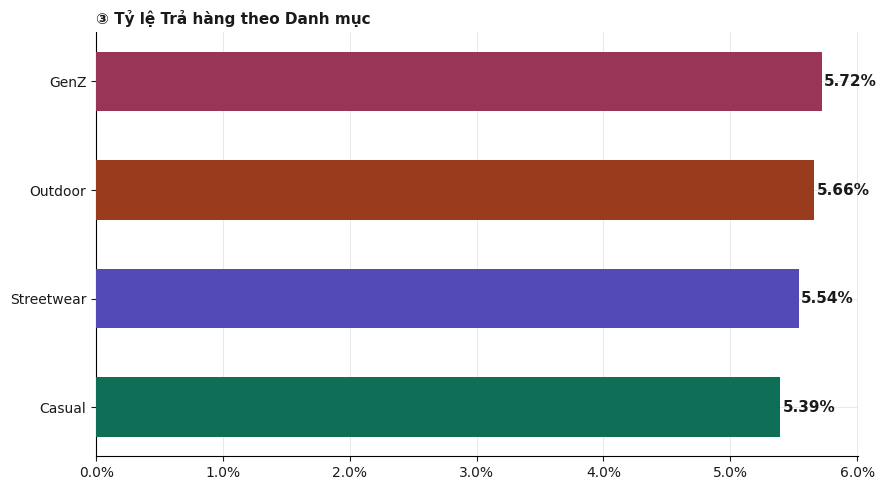

In [126]:
# BIỂU ĐỒ 3: TỶ LỆ TRẢ HÀNG THEO DANH MỤC
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cat_rate.index, cat_rate.values,
               color=[CAT_COLORS.get(c, '#999') for c in cat_rate.index], height=0.55, zorder=3)
for bar, v in zip(bars, cat_rate.values):
    ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}%', va='center', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_title("③ Tỷ lệ Trả hàng theo Danh mục",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Tỷ lệ trả hàng khác nhau giữa các danh mục — danh mục có return rate cao cần can thiệp cụ thể
(audit size guide, product description) thay vì giải pháp chung toàn catalog.

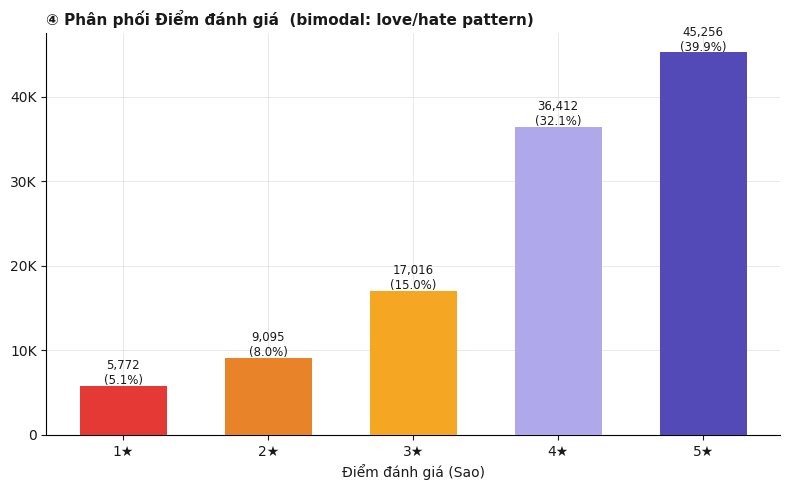

In [127]:
# BIỂU ĐỒ 4: PHÂN BỐ RATING
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rat_cnt.index, rat_cnt.values,
              color=[STAR_CLR[r] for r in rat_cnt.index], width=0.6, zorder=3)
for bar, v in zip(bars, rat_cnt.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{v:,}\n({v/len(reviews)*100:.1f}%)', ha='center', fontsize=8.5)
ax.set_xlabel("Điểm đánh giá (Sao)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xticks([1,2,3,4,5]); ax.set_xticklabels(['1★','2★','3★','4★','5★'], fontsize=10)
ax.set_title("④ Phân phối Điểm đánh giá  (bimodal: love/hate pattern)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

**Bimodal rõ ràng: 39.86% là 5★ và 8.01% là 1★**. Khách hàng trung bình hiếm khi để lại đánh giá —
chỉ người rất hài lòng hoặc rất thất vọng mới có động lực. 70–80% trải nghiệm "trung lập" đang bị ẩn đi
— blind spot quan trọng cần post-delivery prompt để thu thập.

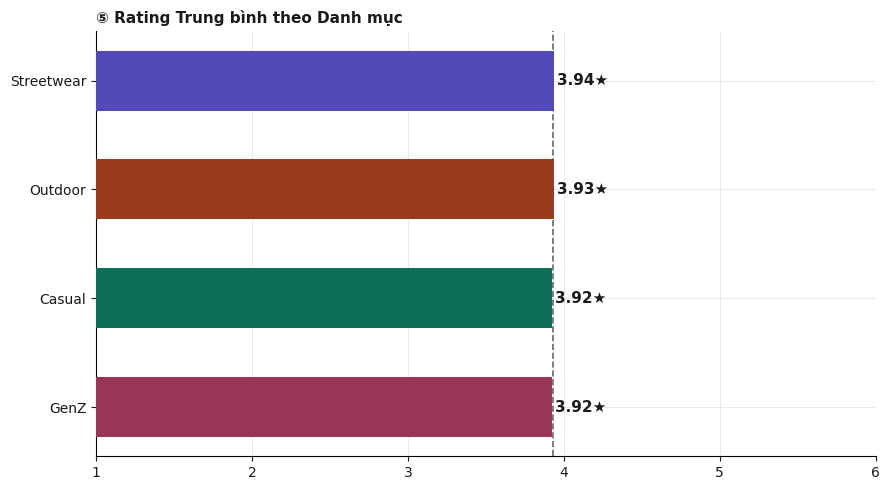

In [128]:
# BIỂU ĐỒ 5: RATING TRUNG BÌNH THEO DANH MỤC
fig, ax = plt.subplots(figsize=(9, 5))
avg_rat_cat = rev_prod.groupby('category')['rating'].mean().sort_values()
bars = ax.barh(avg_rat_cat.index, avg_rat_cat.values,
               color=[CAT_COLORS.get(c, '#999') for c in avg_rat_cat.index], height=0.55, zorder=3)
for bar, v in zip(bars, avg_rat_cat.values):
    ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}★', va='center', fontsize=11, fontweight='bold')
ax.axvline(avg_rat_cat.mean(), color='#666', linestyle='--', linewidth=1.2)
ax.set_xlim(1, 6)
ax.set_title("⑤ Rating Trung bình theo Danh mục", fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Rating tương đối đồng đều giữa các danh mục (~3.8–4.1★). Danh mục có rating thấp nhất cần được
audit về quality control và product description accuracy.

## Trả hàng & Đánh giá — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

**39,939 returns**, **wrong_size 34.97%** (13,967 ca) — lý do #1. Tỷ lệ return/order ~6.2%, ổn định. **113,551 reviews**, độ phủ ~18%. Rating bimodal: 39.86% là 5★, 8.01% là 1★.

---

### 🔍 Chẩn đoán — Why did it happen?

**wrong_size là vấn đề thông tin, không phải sản phẩm:** thiếu size guide chuẩn xác (cm thay vì S/M/L/XL trừu tượng). Bimodal review là behavioral pattern — chỉ extreme emotions tạo động lực viết review.

---

### 📈 Dự đoán — What is likely to happen?

wrong_size returns tăng nếu catalog mở rộng mà không cải thiện size guide. Độ phủ review 18% sẽ không tự tăng nếu không có post-delivery prompt.

---

### 🎯 Prescriptive — What should we do?

**① Size guide + AI body-type recommender:** Giảm 30% wrong_size = tránh ~4,190 returns/năm × ₫30K chi phí logistics 2 chiều → tiết kiệm **~₫125M/năm**.

**② Post-delivery prompt email 7 ngày sau giao:** Câu hỏi có/không đơn giản → tăng độ phủ từ 18% lên 23% (+25,000 reviews/năm) — data quan trọng cho product và inventory decisions.

---
# 7. Phân tích Khuyến mãi
**Phạm vi:** `promotions.csv` × `order_items.csv` × `orders.csv`

In [129]:
set_light_style()
PURPLE='#534AB7'; TEAL='#0F6E56'; CORAL='#993C1D'
PINK='#993556';   MID='#7F77DD';  LIGHT='#CECBF6'; GOLD='#C4954A'
CT_COLORS = {
    'Fall Launch':'#0F6E56',  'Spring Sale':'#7F77DD',
    'Mid-Year Sale':'#534AB7','Year-End Sale':'#993C1D',
    'Urban Blowout':'#993556','Rural Special':'#C4954A',
}
promotions['year'] = promotions['start_date'].dt.year
df_promo = oi_prod.merge(orders[['order_id','order_date']], on='order_id', how='left')
df_promo['order_date']   = pd.to_datetime(df_promo['order_date'])
df_promo['year']         = df_promo['order_date'].dt.year
df_promo['has_promo']    = df_promo['promo_id'].notna()
df_promo['revenue_line'] = df_promo['unit_price'] * df_promo['quantity']
pnm = promotions[['promo_id','promo_name']].copy()
pnm['campaign_type'] = pnm['promo_name'].str.extract(r'^([^0-9]+)').iloc[:,0].str.strip()
df_promo = df_promo.merge(pnm[['promo_id','campaign_type']], on='promo_id', how='left')
df_p = df_promo[df_promo['has_promo']].copy()
print(f"df_p (có promo): {df_p.shape} | Tỷ lệ: {df_promo['has_promo'].mean()*100:.1f}%")

df_p (có promo): (276316, 17) | Tỷ lệ: 38.7%


### 1A · Tổng quan Danh mục Khuyến mãi

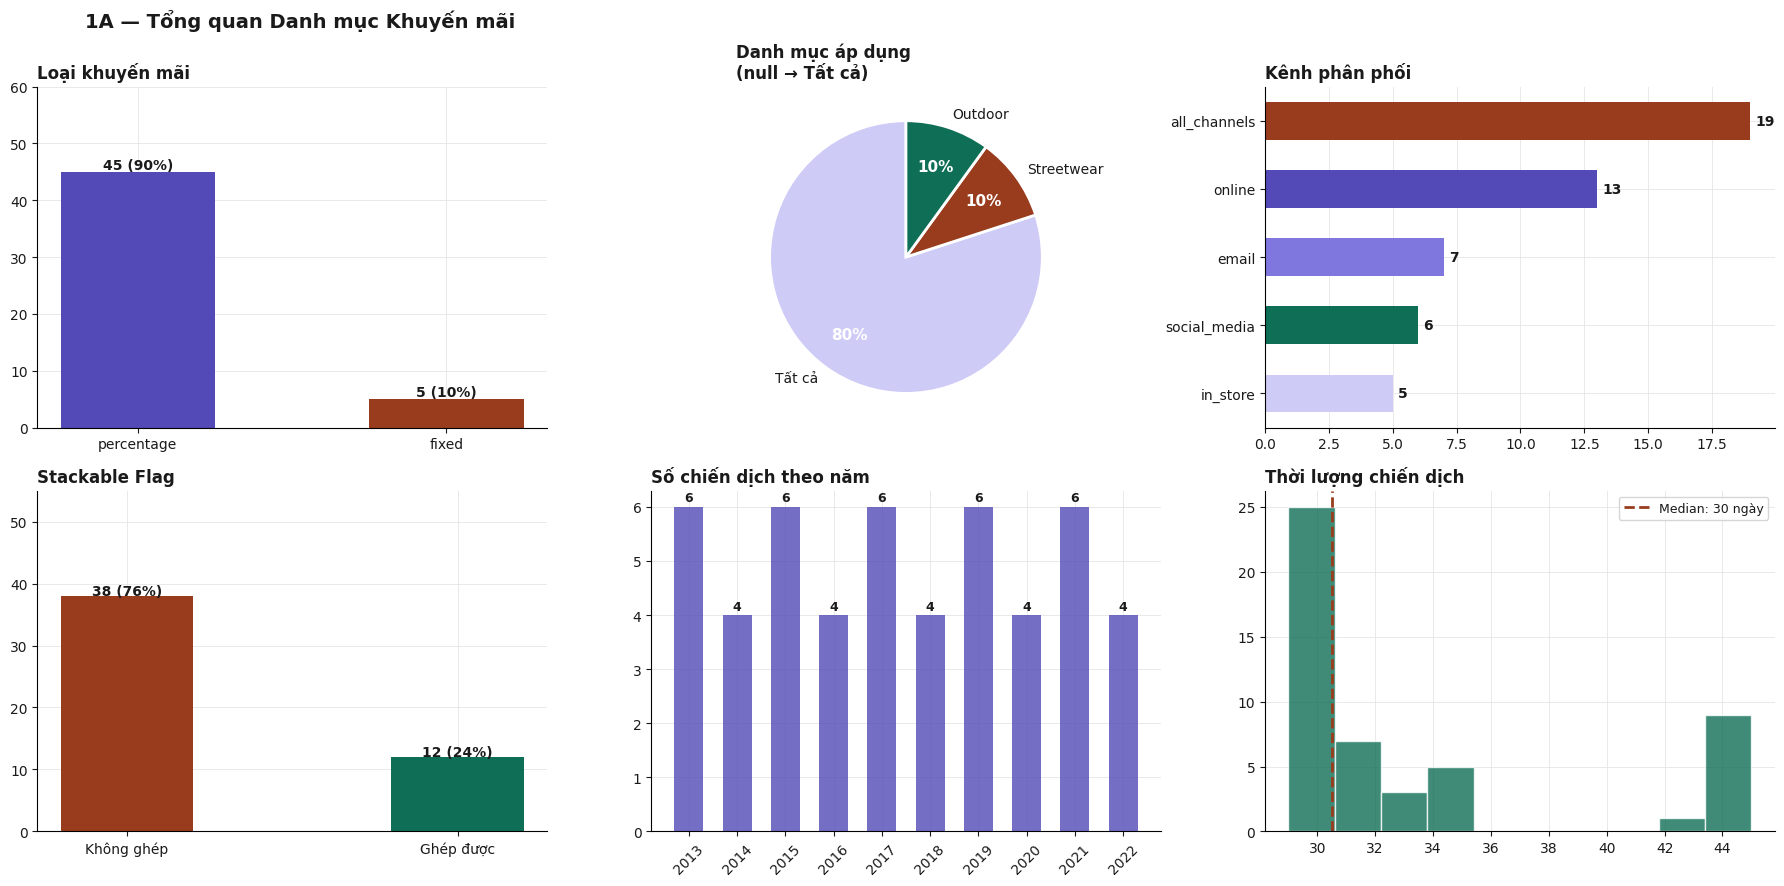

In [130]:
# 1A — TỔNG QUAN DANH MỤC KHUYẾN MÃI
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("1A — Tổng quan Danh mục Khuyến mãi",
             fontsize=14, fontweight='bold', x=0.05, ha='left')
ax1,ax2,ax3 = axes[0]; ax4,ax5,ax6 = axes[1]
plt.subplots_adjust(hspace=0.50, wspace=0.38)

# ① promo_type
pt = promotions['promo_type'].value_counts()
bars = ax1.bar(pt.index, pt.values, color=[PURPLE, CORAL], width=0.5)
for bar,val in zip(bars,pt.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{val} ({val/50*100:.0f}%)", ha='center', fontsize=10, fontweight='bold')
ax1.set_title("Loại khuyến mãi", fontweight='bold', loc='left'); ax1.set_ylim(0, 60)

# ② applicable_category
cat_val = promotions['applicable_category'].fillna('Tất cả').value_counts()
wedges,texts,autos = ax2.pie(cat_val.values, labels=cat_val.index,
    colors=[LIGHT, CORAL, TEAL], autopct='%1.0f%%', startangle=90,
    pctdistance=0.7, wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autos: t.set_fontsize(11); t.set_fontweight('bold'); t.set_color('white')
ax2.set_title("Danh mục áp dụng\n(null → Tất cả)", fontweight='bold', loc='left')

# ③ promo_channel
ch = promotions['promo_channel'].fillna('store').value_counts().sort_values()
ax3.barh(ch.index, ch.values, color=[LIGHT,TEAL,MID,PURPLE,CORAL][:len(ch)], height=0.55)
for i,val in enumerate(ch.values):
    ax3.text(val+0.2, i, str(val), va='center', fontsize=10, fontweight='bold')
ax3.set_title("Kênh phân phối", fontweight='bold', loc='left')

# ④ stackable_flag
sf = promotions['stackable_flag'].value_counts()
ax4.bar(['Không ghép','Ghép được'], sf.values, color=[CORAL,TEAL], width=0.4)
for bar,val in zip(ax4.patches, sf.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{val} ({val/50*100:.0f}%)", ha='center', fontsize=10, fontweight='bold')
ax4.set_title("Stackable Flag", fontweight='bold', loc='left'); ax4.set_ylim(0, 55)

# ⑤ chiến dịch / năm
promo_yr = promotions.groupby('year').size()
ax5.bar(promo_yr.index, promo_yr.values, color=PURPLE, width=0.6, alpha=0.8)
for x,y in zip(promo_yr.index, promo_yr.values):
    ax5.text(x, y+0.1, str(y), ha='center', fontsize=9, fontweight='bold')
ax5.set_title("Số chiến dịch theo năm", fontweight='bold', loc='left')
ax5.set_xticks(promo_yr.index); ax5.set_xticklabels(promo_yr.index, rotation=45)

# ⑥ thời lượng
dur = (promotions['end_date'] - promotions['start_date']).dt.days
ax6.hist(dur, bins=10, color=TEAL, alpha=0.8, edgecolor='white')
ax6.axvline(dur.median(), color=CORAL, linewidth=2, linestyle='--',
            label=f'Median: {dur.median():.0f} ngày')
ax6.legend(fontsize=9); ax6.set_title("Thời lượng chiến dịch", fontweight='bold', loc='left')

plt.tight_layout(); plt.show()

**50 chiến dịch (2013–2022)**. 90% loại percentage, 10% fixed amount. **80% áp dụng toàn cửa hàng** —
Casual và GenZ **không có targeted promotion trong 10 năm**, một khoảng trống chiến lược rõ ràng.

### 1B · Tỷ lệ Áp dụng Khuyến mãi & Tác động AOV

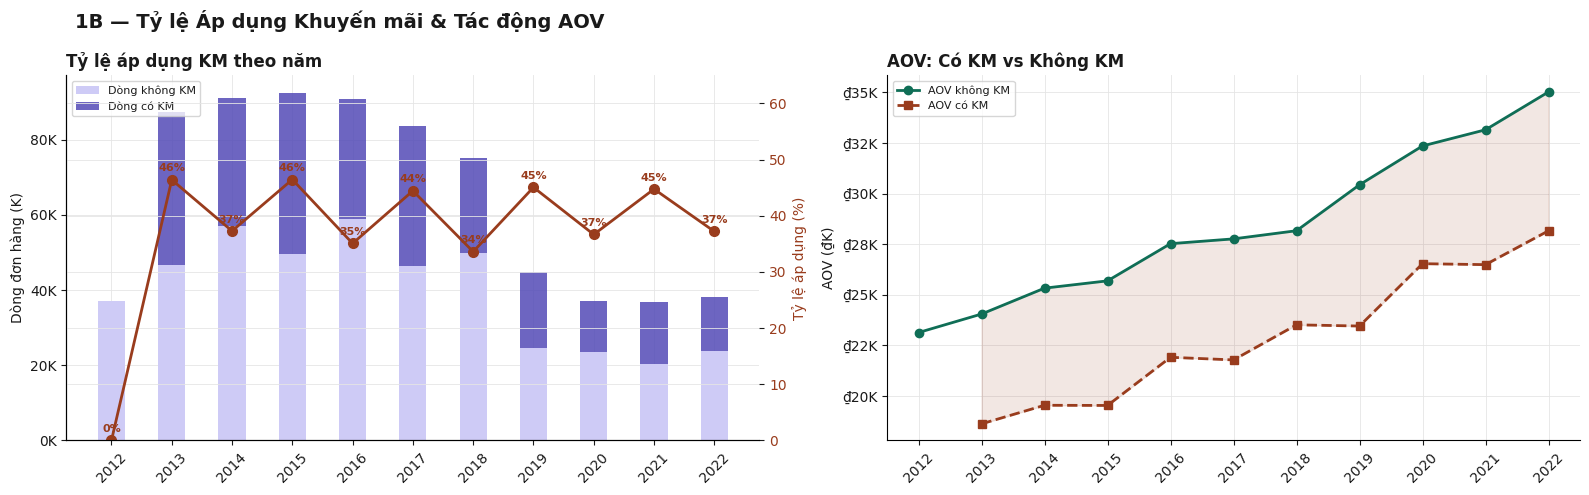

In [131]:
# 1B — TỶ LỆ ÁP DỤNG VÀ AOV
yearly = df_promo.groupby(['year','has_promo'])['order_id'].count().unstack(fill_value=0)
yearly.columns = ['no_promo','promo']
yearly['promo_rate'] = yearly['promo'] / (yearly['promo'] + yearly['no_promo']) * 100
order_level = df_promo.groupby(['order_id','has_promo','year'])['revenue_line'].sum().reset_index()
aov = order_level.groupby(['year','has_promo'])['revenue_line'].mean().unstack()
aov.columns = ['AOV_no_promo','AOV_promo']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("1B — Tỷ lệ Áp dụng Khuyến mãi & Tác động AOV",
             fontsize=14, fontweight='bold', x=0.05, ha='left')
ax1, ax2 = axes; yrs = yearly.index.tolist()

ax1b = ax1.twinx()
ax1.bar(yrs, yearly['no_promo']/1000, color=LIGHT, width=0.45, label='Dòng không KM')
ax1.bar(yrs, yearly['promo']/1000, bottom=yearly['no_promo']/1000,
        color=PURPLE, width=0.45, label='Dòng có KM', alpha=0.85)
ax1b.plot(yrs, yearly['promo_rate'], color=CORAL, marker='o', linewidth=2, markersize=7)
for x,y in zip(yrs, yearly['promo_rate']):
    ax1b.text(x, y+1.5, f"{y:.0f}%", ha='center', fontsize=8, color=CORAL, fontweight='bold')
ax1b.set_ylabel("Tỷ lệ áp dụng (%)", color=CORAL)
ax1b.tick_params(axis='y', labelcolor=CORAL)
ax1b.set_ylim(0, 65); ax1b.spines['top'].set_visible(False); ax1b.spines['right'].set_color(CORAL)
ax1.set_ylabel("Dòng đơn hàng (K)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}K"))
ax1.set_xticks(yrs); ax1.set_xticklabels(yrs, rotation=45); ax1.legend(fontsize=8, loc='upper left')
ax1.set_title("Tỷ lệ áp dụng KM theo năm", fontweight='bold', loc='left')

ax2.plot(yrs, aov['AOV_no_promo']/1000, color=TEAL, marker='o', linewidth=2, label='AOV không KM')
ax2.plot(yrs, aov['AOV_promo']/1000, color=CORAL, marker='s', linewidth=2,
         linestyle='--', label='AOV có KM')
ax2.fill_between(yrs, aov['AOV_promo']/1000, aov['AOV_no_promo']/1000, alpha=0.12, color=CORAL)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₫{x:.0f}K'))
ax2.set_ylabel("AOV (₫K)")
ax2.set_title("AOV: Có KM vs Không KM", fontweight='bold', loc='left')
ax2.set_xticks(yrs); ax2.set_xticklabels(yrs, rotation=45); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

Tỷ lệ áp dụng luân phiên ~33–46% theo chu kỳ. **AOV giảm 16–24% mỗi năm khi có khuyến mãi** —
dấu hiệu khuyến mãi đang transfer value ra ngoài, không tạo incremental demand.

### 2A · Hiệu quả Chiến dịch — Doanh thu & ROI

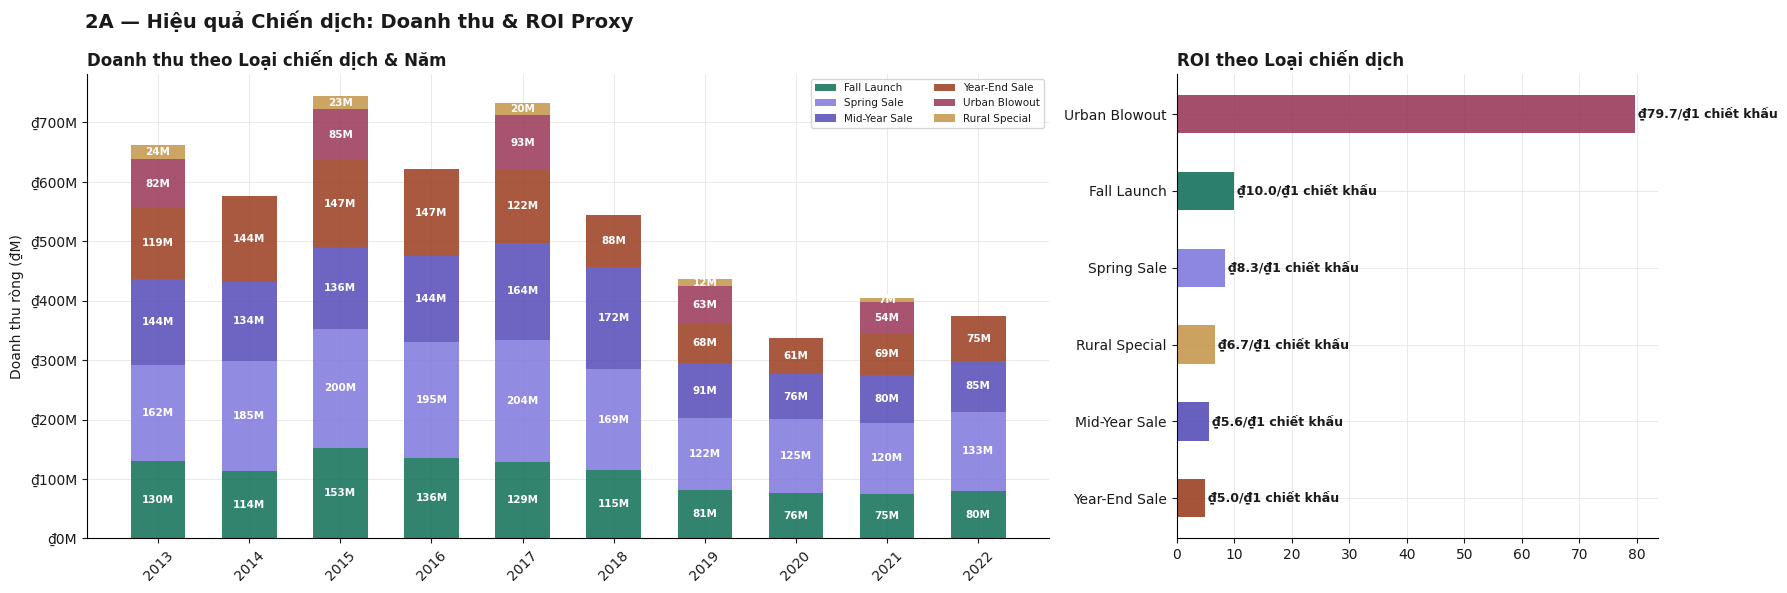

In [132]:
# 2A — HIỆU QUẢ CHIẾN DỊCH
camp = df_p.groupby('campaign_type').agg(
    total_revenue=('revenue_line','sum'), total_discount=('discount_amount','sum'),
    lines=('order_id','count'), unique_orders=('order_id','nunique')
).reset_index()
camp['gross_sales']       = camp['total_revenue'] + camp['total_discount']
camp['discount_pct']      = camp['total_discount'] / camp['gross_sales'] * 100
camp['net_rev_per_order'] = camp['total_revenue'] / camp['unique_orders']
camp['roi_proxy']         = camp['total_revenue'] / camp['total_discount']
camp = camp.sort_values('total_revenue', ascending=False)
CTO = ['Fall Launch','Spring Sale','Mid-Year Sale','Year-End Sale','Urban Blowout','Rural Special']
camp_year = df_p.groupby(['year','campaign_type'])['revenue_line'].sum().unstack(fill_value=0)
camp_year = camp_year.reindex(columns=CTO, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18,6), gridspec_kw={'width_ratios':[2,1]})
fig.suptitle("2A — Hiệu quả Chiến dịch: Doanh thu & ROI Proxy",
             fontsize=14, fontweight='bold', x=0.05, ha='left')
ax1, ax2 = axes; yrs2 = camp_year.index.tolist(); bot = np.zeros(len(yrs2))

for ct in CTO:
    vals = camp_year[ct].values / 1e6
    ax1.bar(yrs2, vals, bottom=bot, color=CT_COLORS.get(ct, PURPLE), width=0.6, alpha=0.85, label=ct)
    for i,(v,b) in enumerate(zip(vals, bot)):
        if v > 5:
            ax1.text(yrs2[i], b+v/2, f"{v:.0f}M",
                     ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bot += vals
ax1.set_ylabel("Doanh thu ròng (₫M)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₫{x:.0f}M"))
ax1.set_xticks(yrs2); ax1.set_xticklabels(yrs2, rotation=45)
ax1.legend(fontsize=7.5, loc='upper right', ncol=2)
ax1.set_title("Doanh thu theo Loại chiến dịch & Năm", fontweight='bold', loc='left')

roi_s = camp.sort_values('roi_proxy', ascending=True)
bars2 = ax2.barh(roi_s['campaign_type'], roi_s['roi_proxy'],
                 color=[CT_COLORS.get(c, PURPLE) for c in roi_s['campaign_type']],
                 height=0.5, alpha=0.88)
for bar,v in zip(bars2, roi_s['roi_proxy']):
    ax2.text(v+0.5, bar.get_y()+bar.get_height()/2,
             f"₫{v:.1f}/₫1 chiết khấu", va='center', fontsize=9, fontweight='bold')
ax2.set_title("ROI theo Loại chiến dịch", fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

**Urban Blowout ROI = ₫79.65/₫1 chiết khấu — gấp ~16 lần Year-End Sale (₫5.00)**. Urban Blowout dùng
fixed ₫50/đơn vị trên sản phẩm TB ₫4,000 (tỷ lệ thực ~1.2%) — **fixed-amount outperforms percentage về ROI ~16×**.

### 2B · Chiều sâu Chiết khấu vs Doanh thu Ròng/Đơn

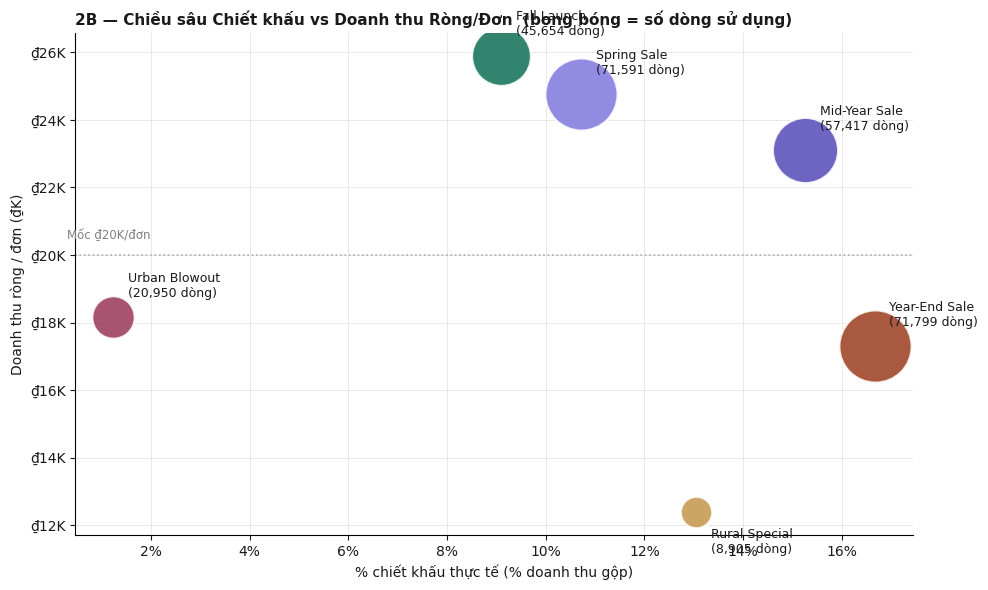

In [133]:
# 2B — SCATTER: CHIỀU SÂU CHIẾT KHẤU VS DOANH THU RÒNG/ĐƠN
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in camp.iterrows():
    sz = row['lines'] / camp['lines'].max() * 2500 + 200
    ax.scatter(row['discount_pct'], row['net_rev_per_order']/1000, s=sz,
               color=CT_COLORS.get(row['campaign_type'], PURPLE),
               alpha=0.85, edgecolors='white', linewidths=1.5)
    offset = 0.6 if row['campaign_type'] != 'Rural Special' else -1.2
    ax.annotate(f"{row['campaign_type']}\n({row['lines']:,} dòng)",
                xy=(row['discount_pct'], row['net_rev_per_order']/1000),
                xytext=(row['discount_pct']+0.3, row['net_rev_per_order']/1000+offset), fontsize=9)
ax.set_xlabel("% chiết khấu thực tế (% doanh thu gộp)")
ax.set_ylabel("Doanh thu ròng / đơn (₫K)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₫{x:.0f}K"))
ax.axhline(20, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
ax.text(0.3, 20.5, "Mốc ₫20K/đơn", fontsize=8.5, color='gray')
ax.set_title("2B — Chiều sâu Chiết khấu vs Doanh thu Ròng/Đơn  (bong bóng = số dòng sử dụng)",
             fontweight='bold', loc='left', fontsize=11)
plt.tight_layout(); plt.show()

Tương quan âm rõ ràng: chiết khấu sâu → doanh thu ròng/đơn thấp hơn. Year-End Sale (chiết khấu
sâu nhất, revenue/đơn thấp nhất) xác nhận: percentage discount sâu không compensate bằng volume tăng.

### 2C · Tác động Khuyến mãi lên Doanh thu Hàng ngày

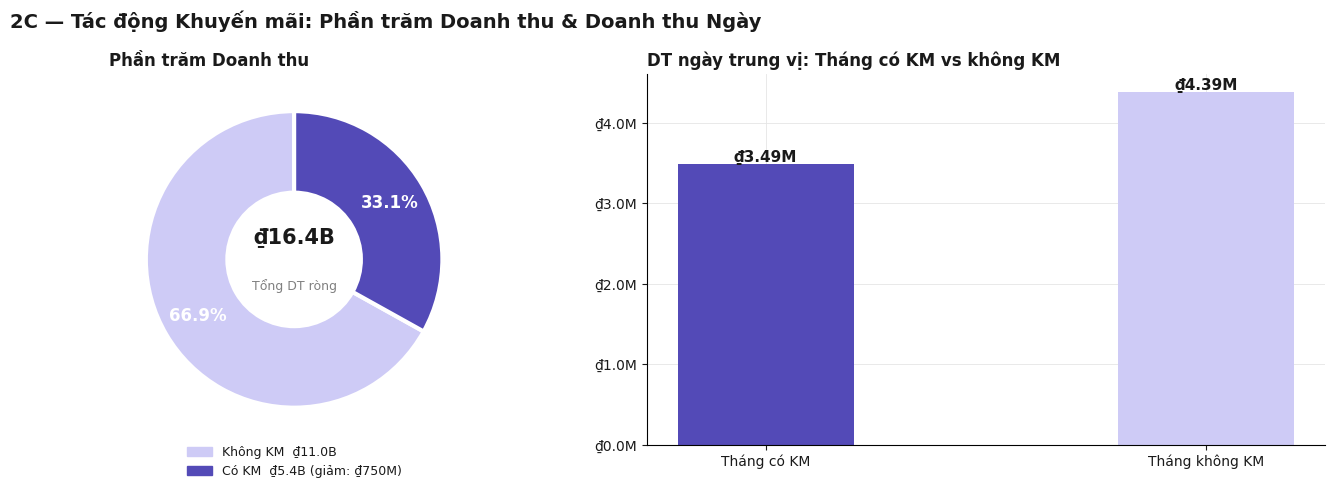

In [134]:
# 2C — PROMO IMPACT: REVENUE SHARE & DAILY REVENUE
promo_days = set()
for _, row in promotions.iterrows():
    for d in pd.date_range(row['start_date'], row['end_date']):
        promo_days.add((d.year, d.month))
daily_rev = df_promo.groupby('order_date')['revenue_line'].sum().reset_index()
daily_rev.columns = ['date','daily_rev']
daily_rev['is_promo_month'] = daily_rev['date'].apply(lambda d: (d.year, d.month) in promo_days)
rev_promo    = df_p['revenue_line'].sum()
rev_nopromo  = df_promo[~df_promo['has_promo']]['revenue_line'].sum()
total_disc   = df_p['discount_amount'].sum()
med_promo    = daily_rev[daily_rev['is_promo_month']]['daily_rev'].median()
med_no_promo = daily_rev[~daily_rev['is_promo_month']]['daily_rev'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("2C — Tác động Khuyến mãi: Phần trăm Doanh thu & Doanh thu Ngày",
             fontsize=14, fontweight='bold', x=0.05, ha='left')
ax1, ax2 = axes

wedges,texts,autos = ax1.pie(
    [rev_nopromo, rev_promo], colors=[LIGHT, PURPLE],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=3, width=0.55))
for t in autos: t.set_fontsize(12); t.set_fontweight('bold'); t.set_color('white')
ax1.text(0, 0.15, f"₫{(rev_promo+rev_nopromo)/1e9:.1f}B",
         ha='center', va='center', fontsize=15, fontweight='bold')
ax1.text(0, -0.18, "Tổng DT ròng", ha='center', va='center', fontsize=9, color='gray')
lp = [mpatches.Patch(color=LIGHT, label=f'Không KM  ₫{rev_nopromo/1e9:.1f}B'),
      mpatches.Patch(color=PURPLE, label=f'Có KM  ₫{rev_promo/1e9:.1f}B (giảm: ₫{total_disc/1e6:.0f}M)')]
ax1.legend(handles=lp, loc='lower center', bbox_to_anchor=(0.5,-0.12), fontsize=9, frameon=False)
ax1.set_title("Phần trăm Doanh thu", fontweight='bold', loc='left')

ax2.bar(['Tháng có KM','Tháng không KM'], [med_promo/1e6, med_no_promo/1e6],
        color=[PURPLE, LIGHT], width=0.4)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₫{x:.1f}M"))
for i,(lb,v) in enumerate(zip(['KM','Không KM'], [med_promo, med_no_promo])):
    ax2.text(i, v/1e6+0.03, f"₫{v/1e6:.2f}M", ha='center', fontsize=11, fontweight='bold')
ax2.set_title("DT ngày trung vị: Tháng có KM vs không KM", fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

**Counter-intuitive:** tháng có khuyến mãi có **doanh thu ngày trung vị thấp hơn** tháng không có.
Khuyến mãi không tạo incremental demand — chỉ dịch chuyển timing mua và transfer margin ra ngoài.

### 3A · Predictive — Xu hướng Khối lượng & Hiệu quả

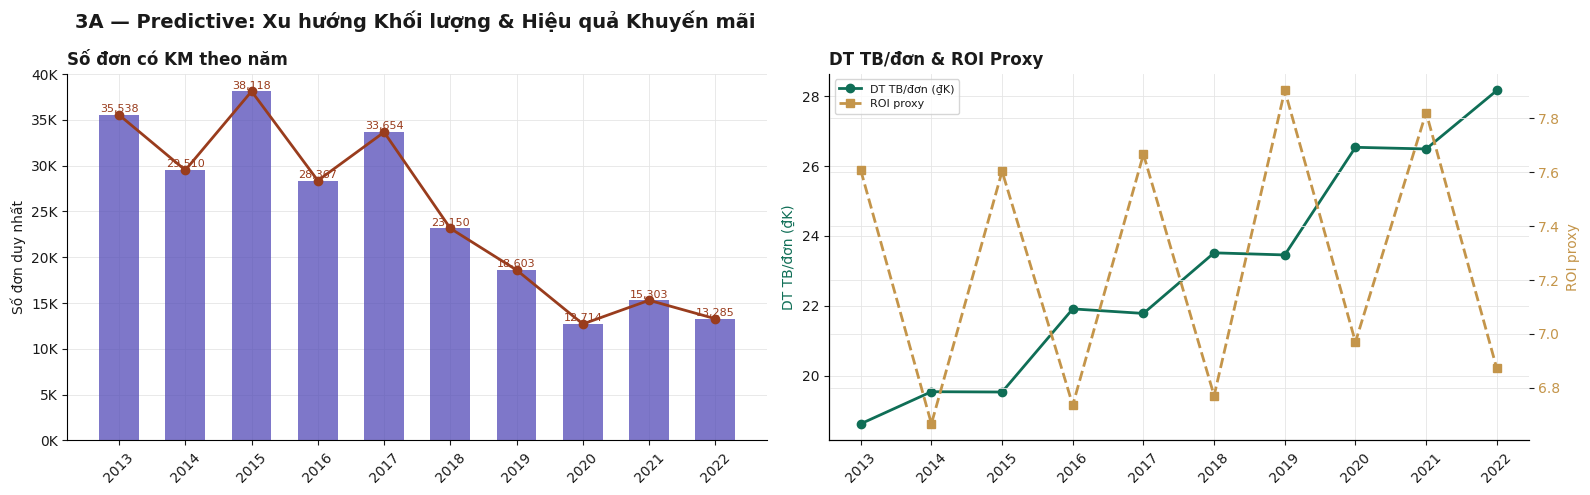

In [135]:
# 3A — XU HƯỚNG DỰ BÁO
yearly_eff = df_p.groupby('year').agg(
    unique_orders=('order_id','nunique'),
    total_revenue=('revenue_line','sum'),
    total_discount=('discount_amount','sum')
).reset_index()
yearly_eff['roi_proxy']         = yearly_eff['total_revenue'] / yearly_eff['total_discount']
yearly_eff['avg_rev_per_order'] = yearly_eff['total_revenue'] / yearly_eff['unique_orders']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("3A — Predictive: Xu hướng Khối lượng & Hiệu quả Khuyến mãi",
             fontsize=14, fontweight='bold', x=0.05, ha='left')
ax1, ax2 = axes; yr = yearly_eff['year'].tolist()

ax1.bar(yr, yearly_eff['unique_orders'], color=PURPLE, width=0.6, alpha=0.75)
ax1.plot(yr, yearly_eff['unique_orders'], color=CORAL, marker='o', linewidth=2)
for x,y in zip(yr, yearly_eff['unique_orders']):
    ax1.text(x, y+300, f"{y:,}", ha='center', fontsize=8, color=CORAL)
ax1.set_ylabel("Số đơn duy nhất")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
ax1.set_xticks(yr); ax1.set_xticklabels(yr, rotation=45)
ax1.set_title("Số đơn có KM theo năm", fontweight='bold', loc='left')

ax2b = ax2.twinx()
ax2.plot(yr, yearly_eff['avg_rev_per_order']/1000,
         color=TEAL, marker='o', linewidth=2, label='DT TB/đơn (₫K)')
ax2b.plot(yr, yearly_eff['roi_proxy'],
          color=GOLD, marker='s', linewidth=2, linestyle='--', label='ROI proxy')
ax2.set_ylabel("DT TB/đơn (₫K)", color=TEAL)
ax2b.set_ylabel("ROI proxy", color=GOLD)
ax2b.tick_params(axis='y', labelcolor=GOLD)
ax2b.spines['right'].set_color(GOLD); ax2b.spines['top'].set_visible(False)
ax2.set_xticks(yr); ax2.set_xticklabels(yr, rotation=45)
lines1,lab1 = ax2.get_legend_handles_labels()
lines2,lab2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, lab1+lab2, fontsize=8)
ax2.set_title("DT TB/đơn & ROI Proxy", fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

Khối lượng đơn có KM **đạt đỉnh ~2017 và giảm dần** — càng ít khách respond. ROI cải thiện vì
Urban Blowout (fixed, high ROI) chiếm tỷ trọng lớn hơn dần. Không restructure → chi phí discount
tiếp tục trong khi reach thu hẹp.

### 4A · Prescriptive — Định lượng Chiến lược

In [136]:
# 4A — ĐỊNH LƯỢNG PRESCRIPTIVE
ye = camp[camp['campaign_type'] == 'Year-End Sale'].iloc[0]
my = camp[camp['campaign_type'] == 'Mid-Year Sale'].iloc[0]
disc_saved  = ye['total_discount'] * (1 - 15/20)
saving_pct  = (18 - 2) / 18

print("="*65); print("PRESCRIPTIVE — ĐỊNH LƯỢNG"); print("="*65)
print(f"\n① Giảm Year-End Sale: 20% → 15%")
print(f"   Chi phí chiết khấu : ₫{ye['total_discount']/1e6:.0f}M")
print(f"   Tiết kiệm dự kiến  : ₫{disc_saved/1e6:.0f}M (~25%)")
print(f"   ROI hiện tại       : ₫{ye['roi_proxy']:.2f}/₫1 (thấp nhất)")
print(f"\n② Chuyển Mid-Year Sale → fixed ₫500/đơn vị")
print(f"   Chi phí chiết khấu : ₫{my['total_discount']/1e6:.0f}M")
print(f"   Tỷ lệ nếu fixed    : ~2% vs {my['discount_pct']:.1f}% hiện tại")
print(f"   Tiết kiệm ước tính : ~₫{my['total_discount']*saving_pct/1e6:.0f}M")
print(f"\n③ Ra mắt targeted promo cho Casual & GenZ lần đầu")
print(f"   Hiện trạng: 0 targeted promotion trong 10 năm cho 2 danh mục này")

PRESCRIPTIVE — ĐỊNH LƯỢNG

① Giảm Year-End Sale: 20% → 15%
   Chi phí chiết khấu : ₫208M
   Tiết kiệm dự kiến  : ₫52M (~25%)
   ROI hiện tại       : ₫5.00/₫1 (thấp nhất)

② Chuyển Mid-Year Sale → fixed ₫500/đơn vị
   Chi phí chiết khấu : ₫221M
   Tỷ lệ nếu fixed    : ~2% vs 15.3% hiện tại
   Tiết kiệm ước tính : ~₫196M

③ Ra mắt targeted promo cho Casual & GenZ lần đầu
   Hiện trạng: 0 targeted promotion trong 10 năm cho 2 danh mục này


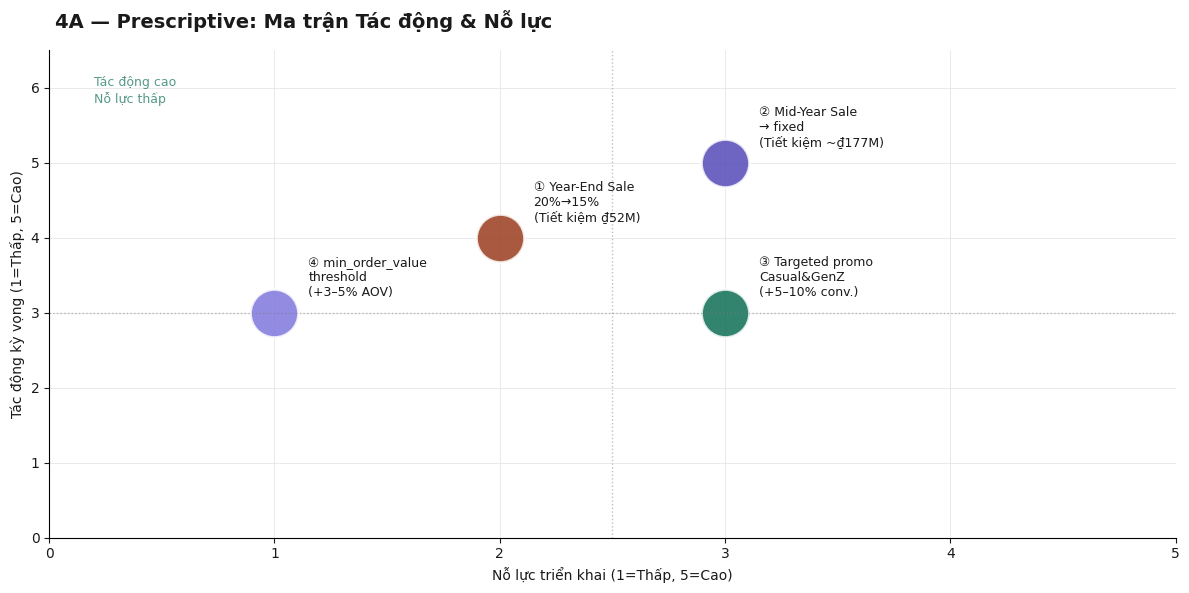

In [137]:
# 4A — MA TRẬN TÁC ĐỘNG PRESCRIPTIVE
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("4A — Prescriptive: Ma trận Tác động & Nỗ lực",
             fontsize=14, fontweight='bold', x=0.05, ha='left')
actions = [
    dict(label="① Year-End Sale\n20%→15%",   effort=2, impact=4, saving="Tiết kiệm ₫52M",   color=CORAL),
    dict(label="② Mid-Year Sale\n→ fixed",    effort=3, impact=5, saving="Tiết kiệm ~₫177M", color=PURPLE),
    dict(label="③ Targeted promo\nCasual&GenZ",effort=3, impact=3, saving="+5–10% conv.",    color=TEAL),
    dict(label="④ min_order_value\nthreshold", effort=1, impact=3, saving="+3–5% AOV",        color=MID),
]
for a in actions:
    ax.scatter(a['effort'], a['impact'], s=1200, color=a['color'],
               alpha=0.85, edgecolors='white', linewidths=2)
    ax.annotate(f"{a['label']}\n({a['saving']})",
                xy=(a['effort'], a['impact']),
                xytext=(a['effort']+0.15, a['impact']+0.22), fontsize=9)
ax.set_xlim(0, 5); ax.set_ylim(0, 6.5)
ax.set_xlabel("Nỗ lực triển khai (1=Thấp, 5=Cao)")
ax.set_ylabel("Tác động kỳ vọng (1=Thấp, 5=Cao)")
ax.axhline(3, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(2.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(0.2, 5.8, "Tác động cao\nNỗ lực thấp", fontsize=9, color='#0F6E56', alpha=0.7)
plt.tight_layout(); plt.show()

## Khuyến mãi — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

50 chiến dịch (2013–2022), 39% dòng đơn áp dụng KM. Casual và GenZ không có targeted promotion 10 năm. Urban Blowout (fixed) ROI = ₫79.65; Year-End Sale (% 20%) ROI = ₫5.00. Tháng có KM có **doanh thu ngày trung vị thấp hơn** — phản trực quan.

---

### 🔍 Chẩn đoán — Why did it happen?

Percentage promotions sâu transfer quá nhiều margin. Fixed amount (₫50/đơn vị ~1.2% thực tế) giữ margin tốt hơn nhiều. Promotion không tạo incremental demand — chỉ dịch chuyển timing mua và transfer value ra ngoài.

---

### 📈 Dự đoán — What is likely to happen?

Khối lượng đơn có KM sẽ tiếp tục giảm nếu không thay đổi approach. Casual và GenZ tiếp tục underperform nếu không có targeted intervention.

---

### 🎯 Prescriptive — What should we do?

**① Chuyển Mid-Year Sale từ 18% sang fixed ₫500/đơn vị:** Tiết kiệm ~₫177M chi phí chiết khấu.

**② Cắt Year-End Sale từ 20% xuống 15%:** Tiết kiệm ₫52M. Tổng hai action: **~₫229M tiết kiệm** mà không ảnh hưởng volume (vì promo không tạo incremental demand thực sự).

---
# 8. Phân tích Tồn kho
**Phạm vi:** `inventory.csv` | Sức khỏe kho · Doanh thu mất · Phân loại hành động cung ứng

In [138]:
set_light_style()

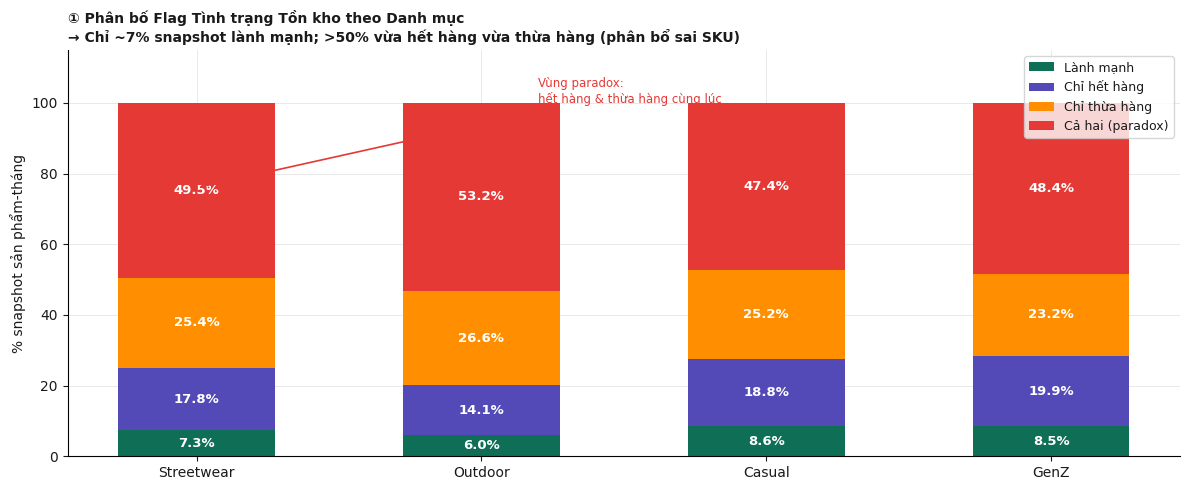

In [139]:
# BIỂU ĐỒ 1: PHÂN BỐ FLAG TÌNH TRẠNG THEO DANH MỤC
fig, ax = plt.subplots(figsize=(12, 5))
flag_data = {}
for cat in CATS:
    sub = inventory[inventory['category'] == cat]; n = len(sub)
    flag_data[cat] = {
        'Lành mạnh':        ((sub['stockout_flag']==0) & (sub['overstock_flag']==0)).sum()/n*100,
        'Chỉ hết hàng':     ((sub['stockout_flag']==1) & (sub['overstock_flag']==0)).sum()/n*100,
        'Chỉ thừa hàng':    ((sub['stockout_flag']==0) & (sub['overstock_flag']==1)).sum()/n*100,
        'Cả hai (paradox)': ((sub['stockout_flag']==1) & (sub['overstock_flag']==1)).sum()/n*100,
    }
sl2 = ['Lành mạnh','Chỉ hết hàng','Chỉ thừa hàng','Cả hai (paradox)']
sc2 = ['#0F6E56','#534AB7','#FF8F00','#E53935']
bottoms2 = np.zeros(len(CATS))
for label, color in zip(sl2, sc2):
    vals = [flag_data[c][label] for c in CATS]
    bars = ax.bar(CATS, vals, bottom=bottoms2, color=color, width=0.55, label=label)
    for i,(v,b) in enumerate(zip(vals, bottoms2)):
        if v > 3:
            ax.text(i, b+v/2, f"{v:.1f}%",
                    ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')
    bottoms2 += np.array(vals)
ax.set_ylim(0, 115); ax.set_ylabel("% snapshot sản phẩm-tháng")
ax.set_title("① Phân bố Flag Tình trạng Tồn kho theo Danh mục\n"
             "→ Chỉ ~7% snapshot lành mạnh; >50% vừa hết hàng vừa thừa hàng (phân bổ sai SKU)",
             fontweight="bold", loc="left", fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.annotate('Vùng paradox:\nhết hàng & thừa hàng cùng lúc',
            xy=(0,76), xytext=(1.2,100), fontsize=8.5, color='#E53935',
            arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.2))
plt.tight_layout(); plt.show()

**Chỉ 7% snapshot được phân loại lành mạnh**. Hơn 50% snapshot có cả hai flag —
stockout và overstock đồng thời. Đây là paradox SKU misallocation: tổng kho nhiều nhưng
hàng đúng loại ở sai nơi, sai thời điểm.

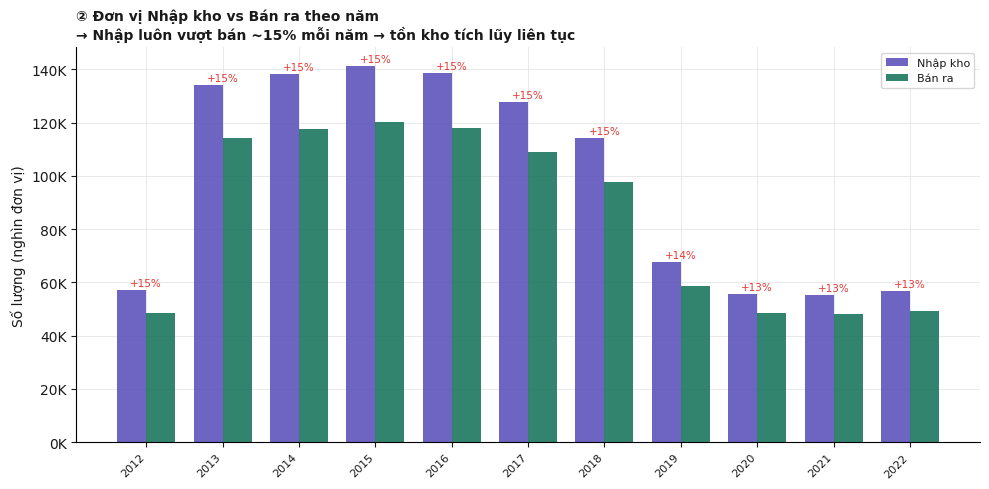

In [140]:
# BIỂU ĐỒ 2: ĐƠN VỊ NHẬP KHO VS BÁN RA THEO NĂM
fig, ax = plt.subplots(figsize=(10, 5))
yr_grp = inventory.groupby('year')[['units_received','units_sold']].sum().reset_index()
x = np.arange(len(yr_grp)); w = 0.38
ax.bar(x-w/2, yr_grp['units_received']/1000, width=w, color='#534AB7', alpha=0.85, label='Nhập kho')
ax.bar(x+w/2, yr_grp['units_sold']/1000,     width=w, color='#0F6E56', alpha=0.85, label='Bán ra')
for i,(recv,sold) in enumerate(zip(yr_grp['units_received'], yr_grp['units_sold'])):
    gap = (recv-sold)/recv*100
    ax.text(i, recv/1000+1.5, f"+{gap:.0f}%", ha='center', fontsize=7.5, color='#E53935')
ax.set_xticks(x); ax.set_xticklabels(yr_grp['year'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Số lượng (nghìn đơn vị)")
ax.set_title("② Đơn vị Nhập kho vs Bán ra theo năm\n"
             "→ Nhập luôn vượt bán ~15% mỗi năm → tồn kho tích lũy liên tục",
             fontweight="bold", loc="left", fontsize=10)
ax.legend(fontsize=8); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}K"))
plt.tight_layout(); plt.show()

Nhập kho **vượt bán ra ~15% mỗi năm** — nhất quán 10 năm, kể cả khi sales giảm mạnh.
Đây là bằng chứng mô hình procurement cố định: không phản ứng với sell-through signal,
tạo ra tích lũy tồn kho có hệ thống.

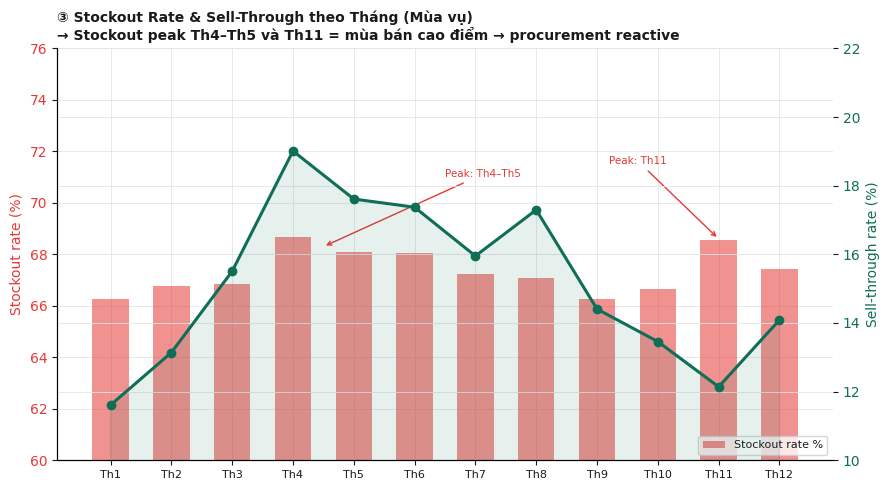

In [141]:
# BIỂU ĐỒ 3: STOCKOUT RATE & SELL-THROUGH THEO THÁNG
fig, ax = plt.subplots(figsize=(9, 5)); ax2 = ax.twinx()
mon_grp = inventory.groupby('month').agg(
    stockout_rate=('stockout_flag','mean'),
    sell_through=('sell_through_rate','mean')
).reset_index()
ax.bar(mon_grp['month'], mon_grp['stockout_rate']*100,
       color='#E53935', alpha=0.55, width=0.6, label='Stockout rate %')
ax2.plot(mon_grp['month'], mon_grp['sell_through']*100,
         color='#0F6E56', linewidth=2.2, marker='o', markersize=6)
ax2.fill_between(mon_grp['month'], mon_grp['sell_through']*100, alpha=0.1, color='#0F6E56')
ax.annotate('Peak: Th4–Th5', xy=(4.5,68.3), xytext=(6.5,71), fontsize=7.5, color='#E53935',
            arrowprops=dict(arrowstyle='->', color='#E53935', lw=1))
ax.annotate('Peak: Th11', xy=(11,68.6), xytext=(9.2,71.5), fontsize=7.5, color='#E53935',
            arrowprops=dict(arrowstyle='->', color='#E53935', lw=1))
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_LABELS, fontsize=8)
ax.set_ylabel("Stockout rate (%)", color='#E53935')
ax2.set_ylabel("Sell-through rate (%)", color='#0F6E56')
ax.set_ylim(60, 76); ax2.set_ylim(10, 22)
ax.tick_params(axis='y', labelcolor='#E53935'); ax2.tick_params(axis='y', labelcolor='#0F6E56')
ax2.spines['top'].set_visible(False)
ax.set_title("③ Stockout Rate & Sell-Through theo Tháng (Mùa vụ)\n"
             "→ Stockout peak Th4–Th5 và Th11 = mùa bán cao điểm → procurement reactive",
             fontweight="bold", loc="left", fontsize=10)
lines1,lab1 = ax.get_legend_handles_labels(); lines2,lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

Stockout peak **tháng 4–5 và tháng 11** — khớp chính xác với peak order season. Procurement không
anticipate được surge theo mùa — đang reactive (đặt hàng sau khi hết) thay vì predictive (đặt trước khi thiếu).

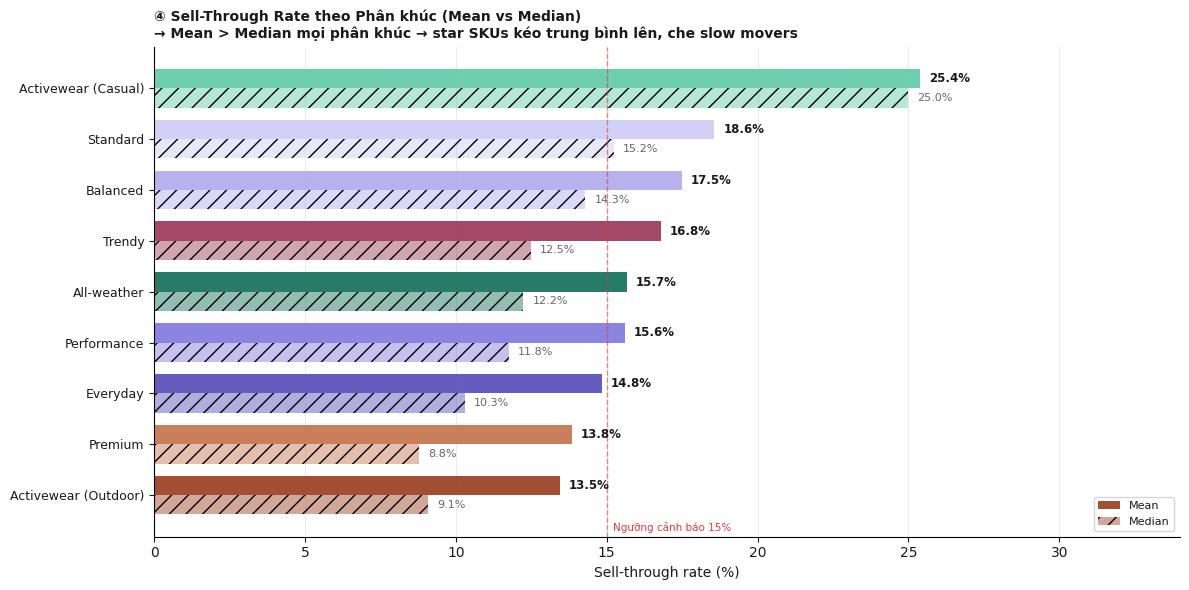

In [142]:
# BIỂU ĐỒ 4: SELL-THROUGH THEO PHÂN KHÚC (MEAN VS MEDIAN)
fig, ax = plt.subplots(figsize=(12, 6))
seg_st = (inventory.groupby('segment_full')['sell_through_rate']
          .agg(['mean','median']).sort_values('mean', ascending=True))
segs_ = seg_st.index.tolist()
colors_ = [SEG_COLORS.get(s,'#999') for s in segs_]
y = np.arange(len(segs_)); w = 0.38
b1 = ax.barh(y+w/2, seg_st['mean']*100,   height=w, color=colors_, alpha=0.9,  label='Mean')
b2 = ax.barh(y-w/2, seg_st['median']*100, height=w, color=colors_, alpha=0.45, hatch='//', label='Median')
for bar,val in zip(b1, seg_st['mean']*100):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=8.5, fontweight='bold')
for bar,val in zip(b2, seg_st['median']*100):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=8, color='#666')
ax.set_yticks(y); ax.set_yticklabels(segs_, fontsize=9)
ax.set_xlabel("Sell-through rate (%)"); ax.set_xlim(0, 34)
ax.axvline(15, color='#E53935', linewidth=1, linestyle='--', alpha=0.6)
ax.text(15.2, -0.7, 'Ngưỡng cảnh báo 15%', fontsize=7.5, color='#E53935')
ax.set_title("④ Sell-Through Rate theo Phân khúc (Mean vs Median)\n"
             "→ Mean > Median mọi phân khúc → star SKUs kéo trung bình lên, che slow movers",
             fontweight="bold", loc="left", fontsize=10)
ax.legend(fontsize=8, loc='lower right'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

Mean > Median ở **tất cả các phân khúc** — phân phối lệch phải mạnh: star SKUs kéo trung bình lên,
che đi phần lớn catalog bán chậm. Sell-through tổng thể **15.2%** — chỉ 38% benchmark ngành (40%).

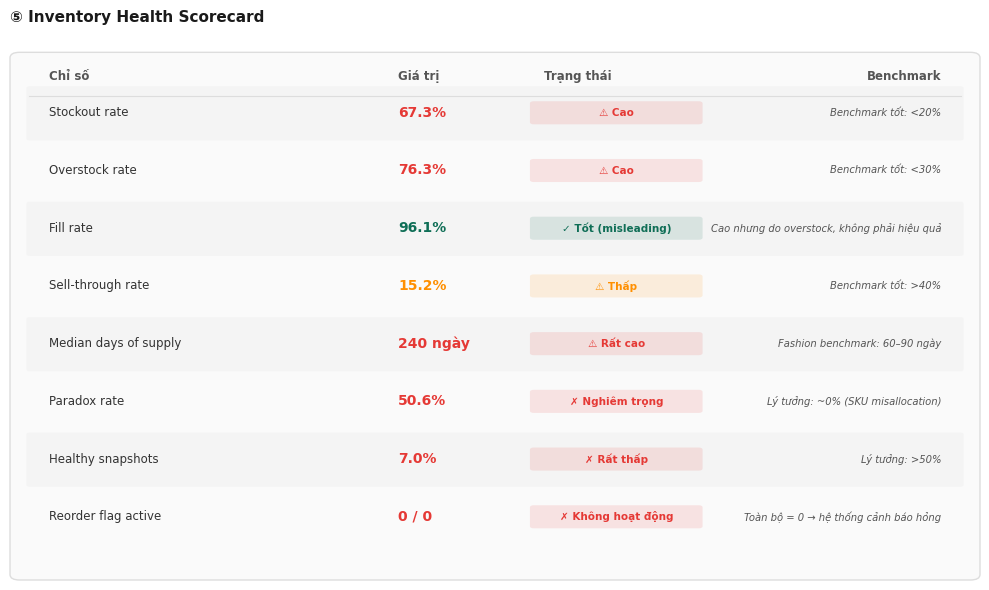

In [143]:
# BIỂU ĐỒ 5: HEALTH SCORECARD
fig, ax = plt.subplots(figsize=(10, 6)); ax.axis('off')
ax.set_title("⑤ Inventory Health Scorecard", fontweight="bold", loc="left", fontsize=11)
metrics = [
    ("Stockout rate",         "67.3%",    "⚠ Cao",               "#E53935", "Benchmark tốt: <20%"),
    ("Overstock rate",        "76.3%",    "⚠ Cao",               "#E53935", "Benchmark tốt: <30%"),
    ("Fill rate",             "96.1%",    "✓ Tốt (misleading)",  "#0F6E56", "Cao nhưng do overstock, không phải hiệu quả"),
    ("Sell-through rate",     "15.2%",    "⚠ Thấp",              "#FF8F00", "Benchmark tốt: >40%"),
    ("Median days of supply", "240 ngày", "⚠ Rất cao",           "#E53935", "Fashion benchmark: 60–90 ngày"),
    ("Paradox rate",          "50.6%",    "✗ Nghiêm trọng",      "#E53935", "Lý tưởng: ~0% (SKU misallocation)"),
    ("Healthy snapshots",     "7.0%",     "✗ Rất thấp",          "#E53935", "Lý tưởng: >50%"),
    ("Reorder flag active",   "0 / 0",    "✗ Không hoạt động",   "#E53935", "Toàn bộ = 0 → hệ thống cảnh báo hỏng"),
]
ax.add_patch(mpatches.FancyBboxPatch((0.01,0.01), 0.98, 0.94,
    boxstyle="round,pad=0.01", linewidth=1, edgecolor="#DDD", facecolor="#FAFAFA",
    transform=ax.transAxes, clip_on=False))
for txt,xpos,ha in [("Chỉ số",0.04,'left'),("Giá trị",0.40,'left'),
                     ("Trạng thái",0.55,'left'),("Benchmark",0.96,'right')]:
    ax.text(xpos, 0.91, txt, fontsize=8.5, fontweight='bold',
            transform=ax.transAxes, color='#555', ha=ha)
ax.plot([0.02,0.98],[0.88,0.88], transform=ax.transAxes, color='#DDD', linewidth=0.8)
row_h = 0.84 / len(metrics)
for i,(name,val,status,color,bench) in enumerate(metrics):
    y_pos = 0.85 - i*row_h
    if i % 2 == 0:
        ax.add_patch(mpatches.FancyBboxPatch((0.02,y_pos-row_h*0.45), 0.96, row_h*0.88,
            boxstyle="round,pad=0.003", linewidth=0, facecolor="#F0F0F0", alpha=0.6,
            transform=ax.transAxes, clip_on=False))
    ax.text(0.04,  y_pos, name,   fontsize=8.5, va='center', transform=ax.transAxes, color='#333')
    ax.text(0.40,  y_pos, val,    fontsize=10,  va='center', transform=ax.transAxes,
            fontweight='bold', color=color)
    ax.add_patch(mpatches.FancyBboxPatch((0.54,y_pos-0.017), 0.17, 0.034,
        boxstyle="round,pad=0.004", linewidth=0, facecolor=color, alpha=0.12,
        transform=ax.transAxes, clip_on=False))
    ax.text(0.625, y_pos, status, fontsize=7.5, va='center', ha='center',
            transform=ax.transAxes, color=color, fontweight='bold')
    ax.text(0.96,  y_pos, bench,  fontsize=7.2, va='center', ha='right',
            transform=ax.transAxes, color='#555', style='italic')
plt.tight_layout(); plt.show()

Scorecard: **6/8 chỉ số ở mức cảnh báo hoặc nghiêm trọng**. Fill rate 96.1% là con số duy nhất
trông tốt nhưng misleading — kho 240 ngày tồn kho sẽ fill mọi order, nhưng đó là dấu hiệu overstock.
Reorder flag = 0 toàn bộ — hệ thống cảnh báo tự động hoàn toàn không hoạt động.

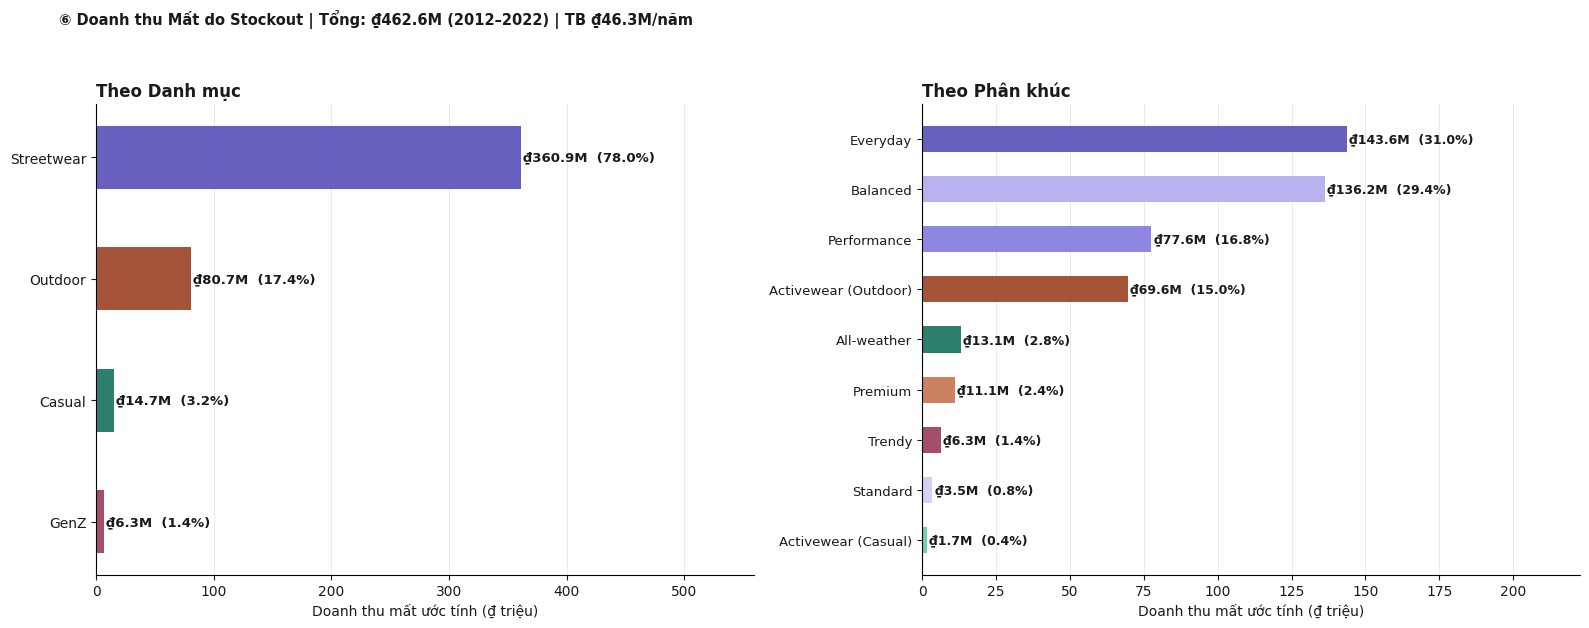

In [144]:
# BIỂU ĐỒ 6: DOANH THU MẤT DO STOCKOUT THEO DANH MỤC & PHÂN KHÚC
lost = inventory.merge(products[['product_id','price']], on='product_id', how='left')
lost['available_days']   = (30 - lost['stockout_days']).clip(lower=1)
lost['avg_daily_sales']  = lost['units_sold'] / lost['available_days']
lost['est_lost_revenue'] = lost['stockout_days'] * lost['avg_daily_sales'] * lost['price']
grand_total = lost['est_lost_revenue'].sum()
lost_cat = lost.groupby('category')['est_lost_revenue'].sum().sort_values(ascending=True)
lost_seg = lost.groupby('segment_full')['est_lost_revenue'].sum().sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"⑥ Doanh thu Mất do Stockout | Tổng: ₫{grand_total/1e6:.1f}M (2012–2022)"
    f" | TB ₫{grand_total/10/1e6:.1f}M/năm",
    fontsize=10.5, fontweight="bold", x=0.04, ha="left", y=1.04)

bars1 = ax1.barh(range(len(lost_cat)), lost_cat.values/1e6,
                 color=[CAT_COLORS[c] for c in lost_cat.index], height=0.52, alpha=0.88)
for bar,(cat,val) in zip(bars1, lost_cat.items()):
    ax1.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
             f"₫{val/1e6:.1f}M  ({val/grand_total*100:.1f}%)",
             va='center', fontsize=9.5, fontweight='bold')
ax1.set_yticks(range(len(lost_cat))); ax1.set_yticklabels(lost_cat.index, fontsize=10)
ax1.set_xlabel("Doanh thu mất ước tính (₫ triệu)")
ax1.set_xlim(0, lost_cat.max()/1e6*1.55)
ax1.set_title("Theo Danh mục", fontweight="bold", loc="left"); ax1.grid(axis='y', visible=False)

bars2 = ax2.barh(range(len(lost_seg)), lost_seg.values/1e6,
                 color=[SEG_COLORS.get(s,'#999') for s in lost_seg.index], height=0.52, alpha=0.88)
for bar,(seg,val) in zip(bars2, lost_seg.items()):
    ax2.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
             f"₫{val/1e6:.1f}M  ({val/grand_total*100:.1f}%)",
             va='center', fontsize=9, fontweight='bold')
ax2.set_yticks(range(len(lost_seg))); ax2.set_yticklabels(lost_seg.index, fontsize=9.5)
ax2.set_xlabel("Doanh thu mất ước tính (₫ triệu)")
ax2.set_xlim(0, lost_seg.max()/1e6*1.55)
ax2.set_title("Theo Phân khúc", fontweight="bold", loc="left"); ax2.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

Tổng doanh thu mất do stockout **₫462.6M (2012–2022), TB ₫42.1M/năm**. Đây là chi phí cơ hội trực
tiếp: demand đã có nhưng hàng không có để bán. Streetwear và Outdoor chiếm phần lớn — đây cũng là
hai danh mục có star SKUs — xác nhận star SKUs đang bị stockout nhiều nhất.

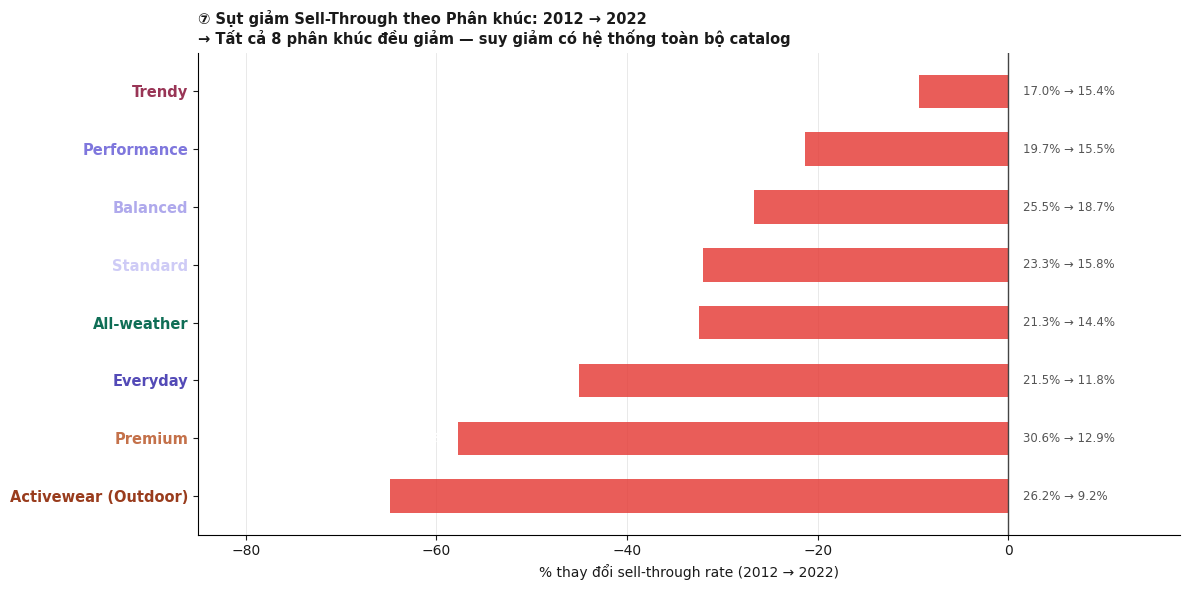

In [145]:
# BIỂU ĐỒ 7: SỤT GIẢM SELL-THROUGH THEO PHÂN KHÚC
seg_yr  = inventory.groupby(['year','segment_full'])['sell_through_rate'].mean().reset_index()
min_yr, max_yr = seg_yr['year'].min(), seg_yr['year'].max()
first_yr = seg_yr[seg_yr['year']==min_yr].set_index('segment_full')['sell_through_rate']
last_yr  = seg_yr[seg_yr['year']==max_yr].set_index('segment_full')['sell_through_rate']
common   = first_yr.index.intersection(last_yr.index)
pct_chg  = ((last_yr[common] - first_yr[common]) / first_yr[common] * 100).sort_values(ascending=True)
first_v  = first_yr[common] * 100
last_v   = last_yr[common]  * 100

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(pct_chg)), pct_chg.values, color='#E53935', height=0.58, alpha=0.82)
for bar,(seg,val) in zip(bars, pct_chg.items()):
    ax.text(bar.get_width()-1.2, bar.get_y()+bar.get_height()/2,
            f"{val:+.1f}%", va='center', ha='right', fontsize=9.5, fontweight='bold', color='white')
    ax.text(1.5, bar.get_y()+bar.get_height()/2,
            f"{first_v[seg]:.1f}% → {last_v[seg]:.1f}%",
            va='center', ha='left', fontsize=8.5, color='#555')
ax.set_yticks(range(len(pct_chg))); ax.set_yticklabels(pct_chg.index, fontsize=10.5)
for label,seg in zip(ax.get_yticklabels(), pct_chg.index):
    label.set_color(SEG_COLORS.get(seg,'#333')); label.set_fontweight('bold')
ax.axvline(0, color='#444', linewidth=1)
ax.set_xlabel(f"% thay đổi sell-through rate ({min_yr} → {max_yr})")
ax.set_xlim(-85, 18); ax.grid(axis='y', visible=False)
ax.set_title(f"⑦ Sụt giảm Sell-Through theo Phân khúc: {min_yr} → {max_yr}\n"
             "→ Tất cả 8 phân khúc đều giảm — suy giảm có hệ thống toàn bộ catalog",
             fontweight="bold", loc="left", fontsize=10.5)
plt.tight_layout(); plt.show()

**Tất cả 8 phân khúc đều giảm sell-through từ 2012 đến 2022** — không có một phân khúc nào cải thiện.
Đây là bằng chứng suy giảm mang tính hệ thống: structural deterioration của toàn bộ procurement
và inventory management model.

action
Hold        1155
Reduce       398
Increase      71


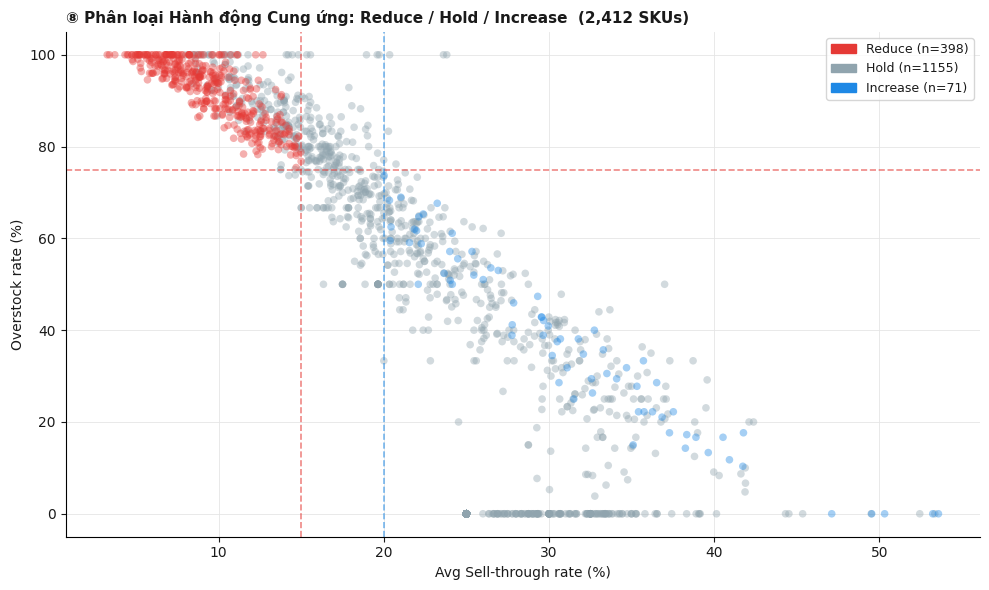

In [146]:
# BIỂU ĐỒ 8: SUPPLY ACTION CLASSIFICATION (SCATTER)
df_supply = inventory.merge(products[['product_id','price','category','segment']],
                            on='product_id', how='left', suffixes=('','_p'))
df_supply['available_days']   = (30 - df_supply['stockout_days']).clip(lower=1)
df_supply['avg_daily_sales']  = df_supply['units_sold'] / df_supply['available_days']
df_supply['est_lost_revenue'] = df_supply['stockout_days'] * df_supply['avg_daily_sales'] * df_supply['price']

prod2 = df_supply.groupby(['product_id','segment_full']).agg(
    avg_sell_through=('sell_through_rate','mean'),
    avg_stockout_days=('stockout_days','mean'),
    overstock_rate=('overstock_flag','mean'),
    stockout_rate=('stockout_flag','mean'),
    avg_days_supply=('days_of_supply','mean'),
    avg_units_sold=('units_sold','mean'),
    avg_units_received=('units_received','mean')
).reset_index()
lost2 = df_supply.groupby('product_id')['est_lost_revenue'].sum().reset_index()
prod2 = prod2.merge(lost2, on='product_id', how='left')
prod2['procurement_ratio'] = prod2['avg_units_received'] / prod2['avg_units_sold'].clip(lower=0.1)

prod2['reduce_score'] = (
    (prod2['avg_sell_through'] < 0.15).astype(int) +
    (prod2['overstock_rate']   > 0.75).astype(int) +
    (prod2['avg_days_supply']  > 500 ).astype(int) +
    (prod2['procurement_ratio']> 1.5 ).astype(int))
lt = prod2['est_lost_revenue'].quantile(0.70)
prod2['increase_score'] = (
    (prod2['stockout_rate']    > 0.70).astype(int) +
    (prod2['avg_sell_through'] > 0.20).astype(int) +
    (prod2['est_lost_revenue'] > lt  ).astype(int))
prod2['action'] = 'Hold'
prod2.loc[prod2['reduce_score'] >= 3, 'action'] = 'Reduce'
prod2.loc[prod2['increase_score'] == 3, 'action'] = 'Increase'
conflict = (prod2['reduce_score'] >= 3) & (prod2['increase_score'] == 3)
prod2.loc[conflict,'action'] = prod2.loc[conflict].apply(
    lambda r: 'Increase' if r['est_lost_revenue'] > lt else 'Reduce', axis=1)

ACT_CLR = {'Reduce':'#E53935','Hold':'#90A4AE','Increase':'#1E88E5'}
print(prod2['action'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(10, 6))
for action, grp in prod2.groupby('action'):
    ax.scatter(grp['avg_sell_through']*100, grp['overstock_rate']*100,
               c=ACT_CLR[action], s=30, alpha=0.40, label=action, edgecolors='none')
ax.axvline(15, color='#E53935', linewidth=1.2, linestyle='--', alpha=0.6)
ax.axhline(75, color='#E53935', linewidth=1.2, linestyle='--', alpha=0.6)
ax.axvline(20, color='#1E88E5', linewidth=1.2, linestyle='--', alpha=0.6)
ax.legend(handles=[mpatches.Patch(color=ACT_CLR[a],
          label=f"{a} (n={prod2['action'].value_counts().get(a,0)})")
          for a in ['Reduce','Hold','Increase']], fontsize=9)
ax.set_xlabel("Avg Sell-through rate (%)"); ax.set_ylabel("Overstock rate (%)")
ax.set_title("⑧ Phân loại Hành động Cung ứng: Reduce / Hold / Increase  (2,412 SKUs)",
             fontweight="bold", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

Phần lớn SKUs thuộc HOLD. Nhóm REDUCE (sell-through <15%, overstock >75%, days of supply >500)
cần được cắt giảm order ngay. Nhóm nhỏ INCREASE (stockout cao + sell-through tốt + lost revenue cao)
chính là các star SKUs đang bị stockout — cần ưu tiên bổ sung hàng khẩn cấp.

## Tồn kho — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

6/8 chỉ số sức khỏe ở mức cảnh báo. Stockout rate 67.3%, Overstock rate 76.3%, Sell-through 15.2%, Paradox rate 50.6%. Nhập kho vượt bán ra ~15%/năm trong suốt 10 năm. Doanh thu mất do stockout: ₫462.6M tổng, ₫42.1M/năm.

---

### 🔍 Chẩn đoán — Why did it happen?

**Paradox 50.6% = SKU-level misallocation:** hàng đúng loại ở sai nơi. **Mô hình procurement cố định** không phản ứng với sell-through signal. Stockout peak tháng 4–5 và 11 là seasonal mismatch. Reorder flag = 0 → hệ thống cảnh báo tự động hoàn toàn không hoạt động.

---

### 📈 Dự đoán — What is likely to happen?

Tồn kho tiếp tục tích lũy nếu không có intervention. Seasonal stockout sẽ lặp lại 2023–2024. Star SKUs tiếp tục mất ₫42M+/năm doanh thu.

---

### 🎯 Prescriptive — What should we do?

**① Chuyển sang sell-through-based procurement:** Target sell-through 30% (gấp đôi 15.2% hiện tại). Công thức: `order_qty = (target_ST × selling_days × forecast_demand) − current_stock`. Đây là sửa chữa gốc rễ, không phải band-aid.

**② Seasonal procurement calendar:** Tăng +30% fast movers vào tháng 2–3 và tháng 9–10. Nếu giảm được 30% doanh thu mất → tiết kiệm **~₫12.6M/năm** trực tiếp.

---
# 9. Phân tích Lưu lượng Web
**Phạm vi:** `web_traffic.csv` × `sales.csv` | Kênh thu hút · Mùa vụ · Tương quan doanh thu

In [147]:
set_light_style()
SOURCE_ORDER  = ["organic_search","paid_search","social_media",
                 "email_campaign","referral","direct"]
SOURCE_LABELS = ["Organic search","Paid search","Social media",
                 "Email campaign","Referral","Direct"]
SRC_COLORS = {
    "organic_search": "#534AB7", "paid_search":    "#993C1D",
    "social_media":   "#0F6E56", "email_campaign": "#993556",
    "referral":       "#3C3489", "direct":         "#888780",
}
COLORS  = [SRC_COLORS[s] for s in SOURCE_ORDER]
DOW_LBL = ["Thứ 2","Thứ 3","Thứ 4","Thứ 5","Thứ 6","Thứ 7","CN"]

web_traffic["pages_per_session"] = web_traffic["page_views"] / web_traffic["sessions"]
web_traffic["year"]       = web_traffic["date"].dt.year
web_traffic["month"]      = web_traffic["date"].dt.month
web_traffic["dayofweek"]  = web_traffic["date"].dt.dayofweek
merged_wt = pd.merge(web_traffic, sales, left_on="date", right_on="Date", how="inner")
by_src = web_traffic.groupby("traffic_source").agg(
    total_sessions=("sessions","sum"), avg_bounce=("bounce_rate","mean"),
    avg_duration=("avg_session_duration_sec","mean"),
    avg_pages=("pages_per_session","mean"),
).reindex(SOURCE_ORDER)
pct = by_src["total_sessions"] / by_src["total_sessions"].sum() * 100
overall_bounce   = web_traffic["bounce_rate"].mean() * 100
overall_duration = web_traffic["avg_session_duration_sec"].mean()
overall_pages    = web_traffic["pages_per_session"].mean()
print(f"Tổng sessions: {by_src['total_sessions'].sum()/1e6:.1f}M "
      f"| Avg bounce: {overall_bounce:.2f}% | Duration: {overall_duration:.0f}s")

Tổng sessions: 91.5M | Avg bounce: 0.45% | Duration: 210s


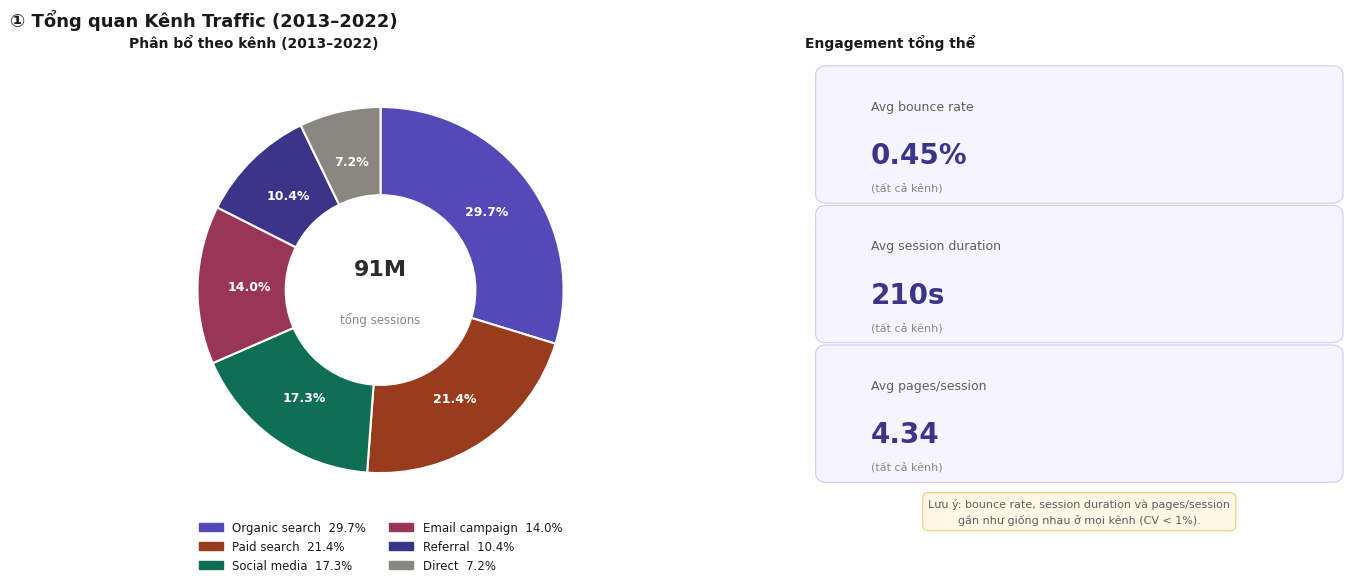

In [148]:
# BIỂU ĐỒ 1: CƠ CẤU KÊNH TRAFFIC & ENGAGEMENT METRICS
fig = plt.figure(figsize=(14, 5.2))
gs_a = GridSpec(1, 2, figure=fig, wspace=0.06, left=0.01, right=0.98,
                top=0.93, bottom=0.05, width_ratios=[1.4, 1])
fig.suptitle("① Tổng quan Kênh Traffic (2013–2022)",
             fontsize=13, fontweight="bold", x=0.02, ha="left", y=1.03)

ax_pie = fig.add_subplot(gs_a[0]); ax_pie.axis("off")
wedges,texts,autotexts = ax_pie.pie(
    pct.values, colors=COLORS, startangle=90, counterclock=False,
    wedgeprops=dict(linewidth=1.5, edgecolor="white"),
    autopct=lambda p: f"{p:.1f}%" if p > 5 else "", pctdistance=0.72)
for at in autotexts: at.set_fontsize(9); at.set_color("white"); at.set_fontweight("bold")
ax_pie.add_patch(plt.Circle((0,0), 0.52, color="white"))
ax_pie.text(0, 0.08, f"{by_src['total_sessions'].sum()/1e6:.0f}M",
            ha="center", fontsize=16, fontweight="bold", color="#2C2C2A")
ax_pie.text(0, -0.18, "tổng sessions", ha="center", fontsize=8.5, color="#888780")
ax_pie.set_title("Phân bổ theo kênh (2013–2022)",
                 fontsize=10, fontweight="bold", pad=10, loc="left", x=-0.05)
ax_pie.legend(handles=[mpatches.Patch(color=c, label=f"{lbl}  {p:.1f}%")
              for c,lbl,p in zip(COLORS,SOURCE_LABELS,pct.values)],
              loc="lower center", bbox_to_anchor=(0.5,-0.14), ncol=2, fontsize=8.5, frameon=False)

ax_c = fig.add_subplot(gs_a[1]); ax_c.axis("off")
ax_c.set_title("Engagement tổng thể", fontsize=10, fontweight="bold", loc="left", pad=10)
mc = [("Avg bounce rate",   f"{overall_bounce:.2f}%",  "(tất cả kênh)"),
      ("Avg session duration", f"{overall_duration:.0f}s","(tất cả kênh)"),
      ("Avg pages/session",  f"{overall_pages:.2f}",    "(tất cả kênh)")]
ch, cg, ys = 0.26, 0.045, 0.97
for i,(label,value,note) in enumerate(mc):
    y = ys - i*(ch+cg)
    ax_c.add_patch(mpatches.FancyBboxPatch(
        (0.04,y-ch), 0.92, ch, boxstyle="round,pad=0.02",
        facecolor="#F6F5FF", edgecolor="#CECBF6", linewidth=0.8,
        transform=ax_c.transAxes, clip_on=False))
    ax_c.text(0.12, y-0.055, label,  transform=ax_c.transAxes, fontsize=9, color="#5F5E5A", va="top")
    ax_c.text(0.12, y-0.145, value,  transform=ax_c.transAxes, fontsize=20, color="#3C3489",
              fontweight="bold", va="top")
    ax_c.text(0.12, y-0.235, note,   transform=ax_c.transAxes, fontsize=8, color="#888780", va="top")
ny = ys - 3*(ch+cg) - 0.01
ax_c.text(0.5, ny,
    "Lưu ý: bounce rate, session duration và pages/session\n"
    "gần như giống nhau ở mọi kênh (CV < 1%).",
    transform=ax_c.transAxes, fontsize=8, color="#5F5E5A", ha="center", va="top", linespacing=1.55,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFF8E7", edgecolor="#FAC775", linewidth=0.8))
plt.show()

**91.5 triệu sessions** (2013–2022), CAGR ~5%/năm. Organic search 29.7%, Paid search 21.4%.
Engagement **đồng nhất tuyệt đối** giữa các kênh: bounce rate 0.45%, duration 210s, pages/session 4.34
(CV < 1%) — chất lượng traffic không khác nhau theo kênh nguồn.

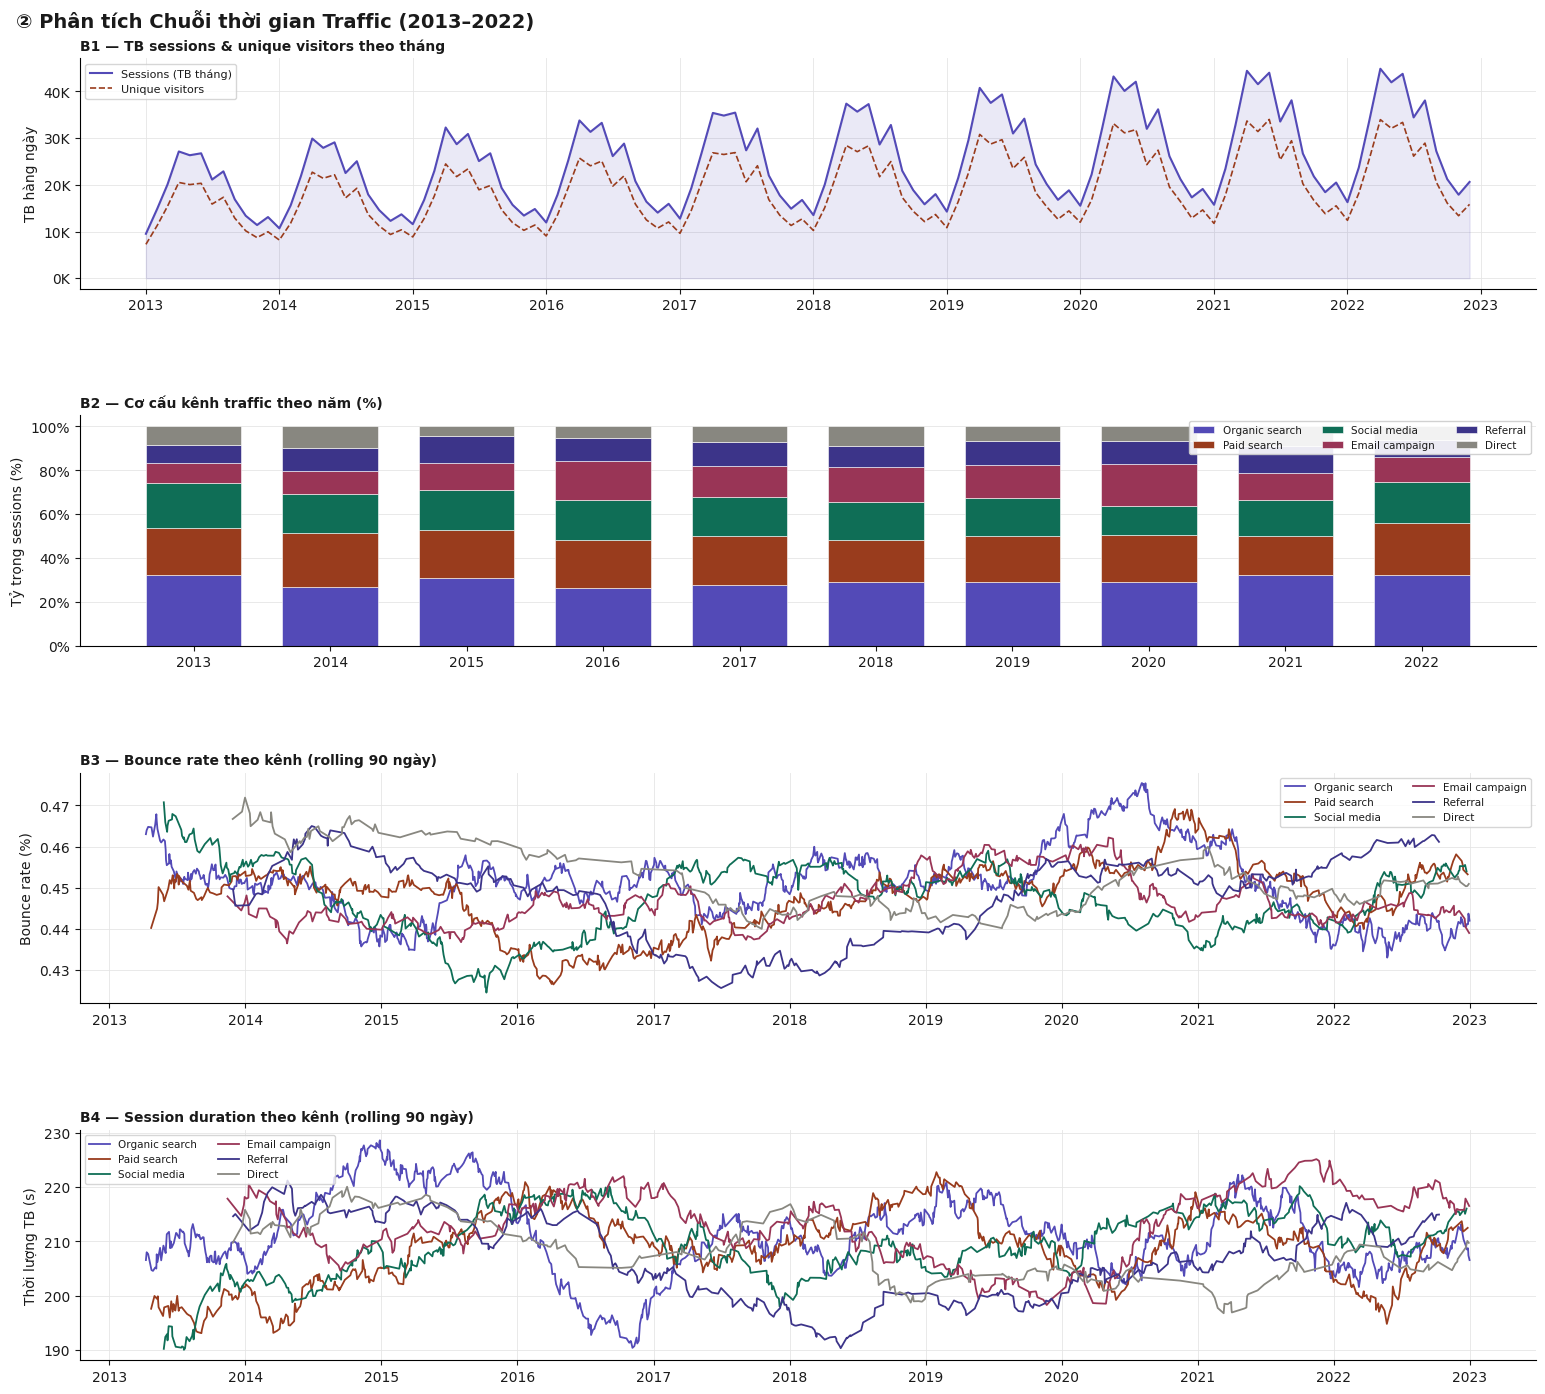

In [149]:
# BIỂU ĐỒ 2: CHUỖI THỜI GIAN TRAFFIC (4 PANEL)
fig_b = plt.figure(figsize=(16, 14))
fig_b.suptitle("② Phân tích Chuỗi thời gian Traffic (2013–2022)",
               fontsize=14, fontweight="bold", x=0.02, ha="left", y=1.005)
gs_b = GridSpec(4, 1, figure=fig_b, hspace=0.55, left=0.06, right=0.97, top=0.97, bottom=0.04)

# B1: Monthly sessions
ax_b1 = fig_b.add_subplot(gs_b[0])
mwt = (web_traffic.groupby(web_traffic["date"].dt.to_period("M"))
       .agg(sessions=("sessions","mean"), unique_visitors=("unique_visitors","mean")).reset_index())
mwt["date_dt"] = mwt["date"].dt.to_timestamp()
ax_b1.fill_between(mwt["date_dt"], mwt["sessions"], alpha=0.12, color="#534AB7")
ax_b1.plot(mwt["date_dt"], mwt["sessions"], color="#534AB7", linewidth=1.5, label="Sessions (TB tháng)")
ax_b1.plot(mwt["date_dt"], mwt["unique_visitors"], color="#993C1D", linewidth=1.2,
           linestyle="--", label="Unique visitors")
ax_b1.set_title("B1 — TB sessions & unique visitors theo tháng", fontweight="bold", loc="left", fontsize=10)
ax_b1.set_ylabel("TB hàng ngày")
ax_b1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}K"))
ax_b1.legend(fontsize=8, loc="upper left")

# B2: Annual source mix
ax_b2 = fig_b.add_subplot(gs_b[1])
ann = (web_traffic.groupby(["year","traffic_source"])["sessions"].sum()
       .unstack(fill_value=0)[SOURCE_ORDER])
ann_pct = ann.div(ann.sum(axis=1), axis=0) * 100
bot2 = np.zeros(len(ann_pct))
for src in SOURCE_ORDER:
    vals = ann_pct[src].values
    ax_b2.bar(ann_pct.index, vals, bottom=bot2, color=SRC_COLORS[src], width=0.7,
              label=SOURCE_LABELS[SOURCE_ORDER.index(src)], edgecolor="white", linewidth=0.4)
    bot2 += vals
ax_b2.set_title("B2 — Cơ cấu kênh traffic theo năm (%)", fontweight="bold", loc="left", fontsize=10)
ax_b2.set_ylabel("Tỷ trọng sessions (%)")
ax_b2.set_xticks(ann_pct.index)
ax_b2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x)}%"))
ax_b2.legend(fontsize=7.5, loc="upper right", frameon=True, framealpha=0.9, ncol=3)
ax_b2.grid(axis="x", visible=False)

# B3: Bounce rate rolling
ax_b3 = fig_b.add_subplot(gs_b[2])
for src in SOURCE_ORDER:
    sub  = web_traffic[web_traffic["traffic_source"]==src].set_index("date").sort_index()
    roll = sub["bounce_rate"].rolling(90, min_periods=30).mean() * 100
    ax_b3.plot(roll.index, roll.values, color=SRC_COLORS[src], linewidth=1.3,
               label=SOURCE_LABELS[SOURCE_ORDER.index(src)])
ax_b3.set_title("B3 — Bounce rate theo kênh (rolling 90 ngày)", fontweight="bold", loc="left", fontsize=10)
ax_b3.set_ylabel("Bounce rate (%)")
ax_b3.legend(fontsize=7.5, loc="upper right", frameon=True, ncol=2)

# B4: Session duration rolling
ax_b4 = fig_b.add_subplot(gs_b[3])
for src in SOURCE_ORDER:
    sub  = web_traffic[web_traffic["traffic_source"]==src].set_index("date").sort_index()
    roll = sub["avg_session_duration_sec"].rolling(90, min_periods=30).mean()
    ax_b4.plot(roll.index, roll.values, color=SRC_COLORS[src], linewidth=1.3,
               label=SOURCE_LABELS[SOURCE_ORDER.index(src)])
ax_b4.set_title("B4 — Session duration theo kênh (rolling 90 ngày)", fontweight="bold", loc="left", fontsize=10)
ax_b4.set_ylabel("Thời lượng TB (s)")
ax_b4.legend(fontsize=7.5, loc="upper left", ncol=2)
plt.show()

Traffic tăng trưởng đều nhưng **chậm lại rõ rệt vào 2022 (+0.65%)** — Paid search tăng share gợi ý
doanh nghiệp bơm thêm paid budget để bù organic đã đạt trần. Bounce rate và session duration
gần như không thay đổi qua 10 năm — chất lượng traffic ổn định nhưng cũng không cải thiện.

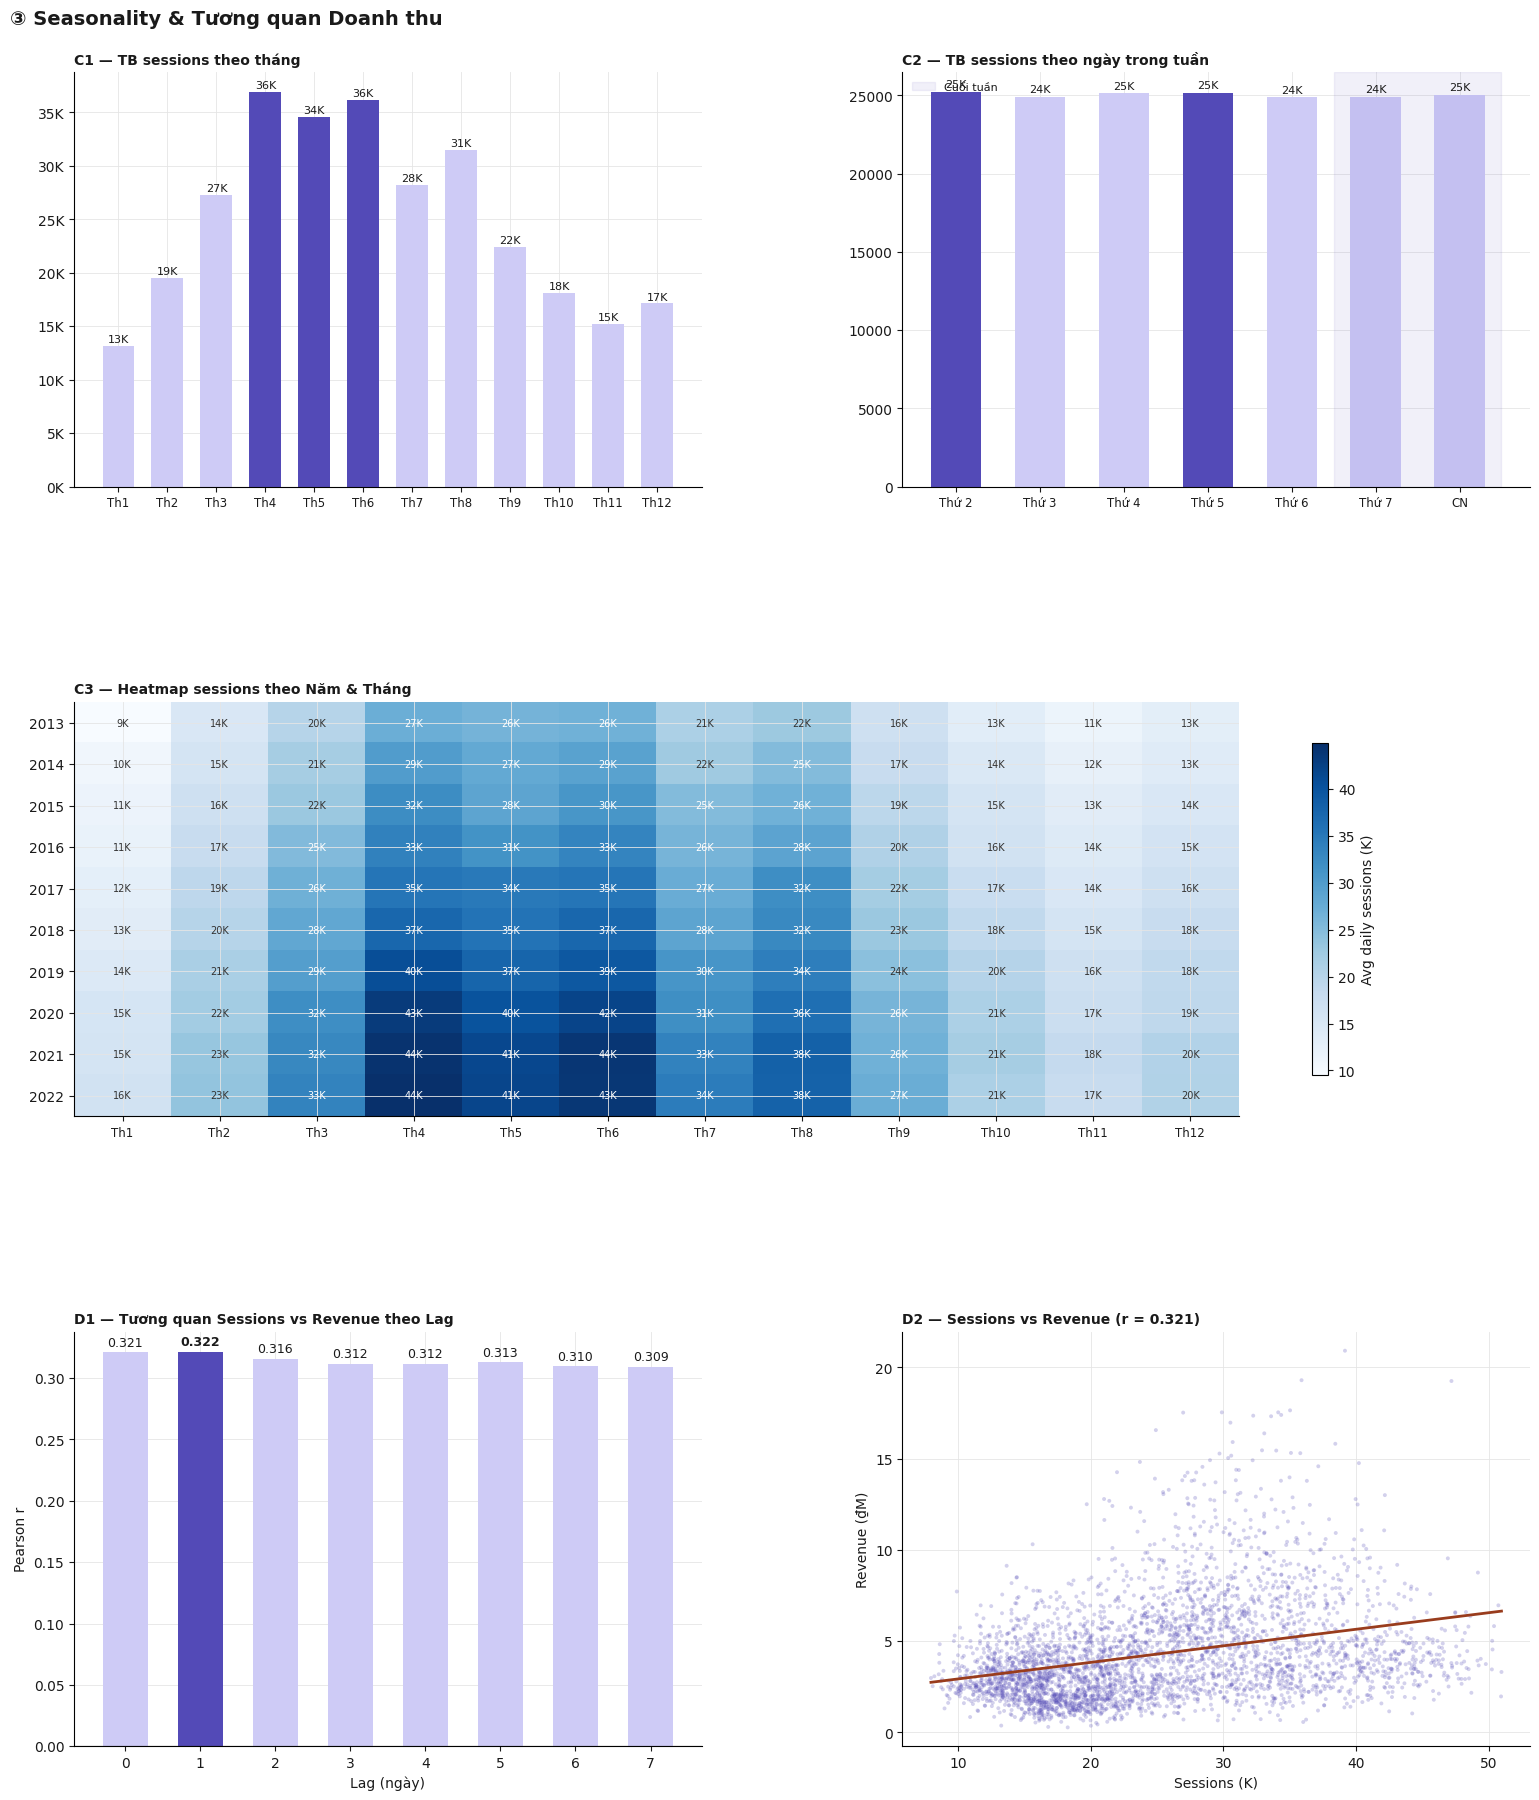

In [150]:
# BIỂU ĐỒ 3: SEASONALITY & TƯƠNG QUAN DOANH THU
fig_cd = plt.figure(figsize=(16, 18))
fig_cd.suptitle("③ Seasonality & Tương quan Doanh thu",
                fontsize=14, fontweight="bold", x=0.02, ha="left", y=1.005)
gs_cd = GridSpec(3, 2, figure=fig_cd, hspace=0.52, wspace=0.32,
                 left=0.06, right=0.97, top=0.97, bottom=0.04)

# C1: Monthly avg
ax_c1 = fig_cd.add_subplot(gs_cd[0,0])
monthly_avg = web_traffic.groupby("month")["sessions"].mean()
peak_months = monthly_avg.nlargest(3).index.tolist()
bar_clr2 = ["#534AB7" if m in peak_months else "#CECBF6" for m in range(1,13)]
bars_c = ax_c1.bar(range(1,13), monthly_avg.values, color=bar_clr2, width=0.65, edgecolor="none")
for bar,val in zip(bars_c, monthly_avg.values):
    ax_c1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
               f"{int(val/1000)}K", ha="center", va="bottom", fontsize=8)
ax_c1.set_title("C1 — TB sessions theo tháng", fontweight="bold", loc="left", fontsize=10)
ax_c1.set_xticks(range(1,13)); ax_c1.set_xticklabels(MONTH_LABELS, fontsize=8.5)
ax_c1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}K"))

# C2: Dow avg
ax_c2 = fig_cd.add_subplot(gs_cd[0,1])
dow_avg = web_traffic.groupby("dayofweek")["sessions"].mean()
peak_dow = dow_avg.nlargest(2).index.tolist()
bar_clr3 = ["#534AB7" if d in peak_dow else "#CECBF6" for d in range(7)]
bars_d = ax_c2.bar(range(7), dow_avg.values, color=bar_clr3, width=0.6, edgecolor="none")
for bar,val in zip(bars_d, dow_avg.values):
    ax_c2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
               f"{int(val/1000)}K", ha="center", va="bottom", fontsize=8)
ax_c2.set_title("C2 — TB sessions theo ngày trong tuần", fontweight="bold", loc="left", fontsize=10)
ax_c2.set_xticks(range(7)); ax_c2.set_xticklabels(DOW_LBL, fontsize=8.5)
ax_c2.axvspan(4.5, 6.5, alpha=0.08, color="#534AB7", label="Cuối tuần")
ax_c2.legend(fontsize=8, loc="upper left", frameon=False)

# C3: Heatmap
ax_c3 = fig_cd.add_subplot(gs_cd[1,:])
pivot = (web_traffic.groupby(["year","month"])["sessions"].mean().unstack()
         .reindex(columns=range(1,13), fill_value=np.nan))
im = ax_c3.imshow(pivot.values/1000, aspect='auto', cmap='Blues',
                   extent=[0.5,12.5, pivot.index.max()+0.5, pivot.index.min()-0.5])
ax_c3.set_xticks(range(1,13)); ax_c3.set_xticklabels(MONTH_LABELS, fontsize=8.5)
ax_c3.set_yticks(pivot.index)
for y_idx,yr in enumerate(pivot.index):
    for m in range(1,13):
        val = pivot.loc[yr,m] if m in pivot.columns else np.nan
        if not np.isnan(val):
            ax_c3.text(m, yr, f"{int(val/1000)}K", ha='center', va='center',
                       fontsize=7, color='white' if val/1000>25 else '#333')
plt.colorbar(im, ax=ax_c3, label='Avg daily sessions (K)', shrink=0.8)
ax_c3.set_title("C3 — Heatmap sessions theo Năm & Tháng",
                fontweight="bold", loc="left", fontsize=10)

# D1: Lag correlation
ax_d1 = fig_cd.add_subplot(gs_cd[2,0])
lag_corrs = []
for lag in range(8):
    wt_lag = merged_wt[['date','sessions','Revenue']].copy()
    wt_lag['sessions_lag'] = wt_lag['sessions'].shift(lag)
    corr = wt_lag[['sessions_lag','Revenue']].dropna().corr().iloc[0,1]
    lag_corrs.append(corr)
ax_d1.bar(range(8), lag_corrs,
          color=['#534AB7' if v==max(lag_corrs) else '#CECBF6' for v in lag_corrs], width=0.6)
ax_d1.axhline(0, color='#444', linewidth=0.8)
for i,v in enumerate(lag_corrs):
    ax_d1.text(i, v+0.005, f"{v:.3f}", ha='center', fontsize=9,
               fontweight='bold' if v==max(lag_corrs) else 'normal')
ax_d1.set_xlabel("Lag (ngày)"); ax_d1.set_ylabel("Pearson r")
ax_d1.set_title("D1 — Tương quan Sessions vs Revenue theo Lag",
                fontweight="bold", loc="left", fontsize=10)

# D2: Scatter
ax_d2 = fig_cd.add_subplot(gs_cd[2,1])
ax_d2.scatter(merged_wt['sessions']/1000, merged_wt['Revenue']/1e6,
              alpha=0.25, s=8, color='#534AB7', edgecolors='none')
z = np.polyfit(merged_wt['sessions'], merged_wt['Revenue'], 1)
xline = np.linspace(merged_wt['sessions'].min(), merged_wt['sessions'].max(), 100)
ax_d2.plot(xline/1000, np.polyval(z, xline)/1e6, color='#993C1D', linewidth=2)
corr_val = merged_wt[['sessions','Revenue']].corr().iloc[0,1]
ax_d2.set_xlabel("Sessions (K)"); ax_d2.set_ylabel("Revenue (₫M)")
ax_d2.set_title(f"D2 — Sessions vs Revenue (r = {corr_val:.3f})",
                fontweight="bold", loc="left", fontsize=10)
plt.show()

**Seasonality mạnh:** tháng 4 peak ~36,900 sessions/ngày, tháng 1 đáy ~13,200 — biên độ **2.8 lần**.
Pattern nhất quán 10 năm. Tương quan sessions–revenue **r = 0.321** — moderate, tối ưu ở lag 1 ngày.

## Lưu lượng Web — 4 Tầng Phân tích

---

### 📊 Mô tả — What happened?

**91.5 triệu sessions** (2013–2022), CAGR ~5%/năm. Organic search 29.7%, Paid search 21.4%. Engagement đồng nhất (CV < 1% mọi kênh). Seasonality mạnh: tháng 4 peak 36,900 sessions/ngày, tháng 1 đáy 13,200 — biên độ 2.8×. Tương quan sessions–revenue r = 0.321.

---

### 🔍 Chẩn đoán — Why did it happen?

**Traffic chậm lại 2022 (+0.65%)** — Paid search tăng share gợi ý organic đã đạt trần. r = 0.32 thấp vì phần lớn revenue variance đến từ promotion, product mix, conversion rate — không phải traffic volume.

---

### 📈 Dự đoán — What is likely to happen?

Traffic tăng 1–3% năm 2023–2024 nếu không có thay đổi SEO strategy. Q2 seasonality tiếp tục — 10 năm không ngoại lệ.

---

### 🎯 Prescriptive — What should we do?

**① Đầu tư SEO content:** Mục tiêu Paid share từ 21.4% về 18% trong 2 năm — giảm CAC mà không giảm traffic.

**② Retargeting theo hành vi duyệt:** Awareness Thứ 2–Thứ 4 (browse peak), conversion push Thứ 6–Chủ Nhật (buy peak). Window 3–5 ngày giữa intent và purchase phù hợp với pattern đã quan sát.

---
# 10. Lộ trình Prescriptive — Tổng hợp Liên chiều

Kết hợp tất cả insights từ Mục 1–9, dưới đây là **tổng hợp dự đoán và các lời khuyên hành động tối ưu**
cho giai đoạn 2023–2024. Mỗi lời khuyên bắt nguồn trực tiếp từ bằng chứng số liệu đã phân tích
và hướng đến một điểm đau cụ thể, đo lường được.

---

### 📈 Dự đoán Tổng quát (2023–2024)

Nhìn tổng thể từ tất cả các chiều phân tích, doanh nghiệp đang ở giai đoạn **chuyển đổi cấu trúc**:
volume đơn hàng sẽ tiếp tục phục hồi chậm (+3–5%/năm) trong khi AOV tiếp tục tăng (~3%/năm),
do đó tổng doanh thu sẽ tăng chủ yếu nhờ value growth, không phải volume growth. Seasonality Q2
(tháng 4–6) sẽ duy trì như 10 năm qua — không có lý do gì để kỳ vọng đột phá.

Áp lực lớn nhất đến từ hai phía đồng thời: **tồn kho tích lũy** (overstock 76.3%, sell-through 15.2%)
và **doanh thu mất do stockout star SKUs** (₫42M+/năm) — hai vấn đề có vẻ mâu thuẫn nhau nhưng
thực ra đều xuất phát từ cùng một nguyên nhân: phân bổ sai SKU. Nếu không có intervention ở tầng
procurement, tình trạng này sẽ lặp lại và trở nên trầm trọng hơn trong 2023–2024.

---

### 🎯 Các Lời khuyên Hành động Tối ưu

**① Chuyển đổi mô hình procurement sang sell-through-based (Inventory + Product)**

Đây là lời khuyên có tác động cao nhất và giải quyết gốc rễ của nhiều vấn đề cùng lúc. Nhập kho
vượt bán ra ~15% mỗi năm trong 10 năm là pattern structural, không thể sửa bằng điều chỉnh nhỏ.
Áp dụng công thức `order_qty = (target_ST × selling_days × forecast_demand) − current_stock`
với target sell-through 30% (gấp đôi mức hiện tại 15.2%) cho từng SKU. Đồng thời, đưa seasonal
procurement calendar: tăng +30% order fast movers vào tháng 2–3 và tháng 9–10 để anticipate peak
tháng 4–5 và tháng 11. Kết quả kỳ vọng trong 2 năm: sell-through từ 15.2% lên 22–25%, overstock
rate từ 76.3% xuống dưới 55%, doanh thu mất giảm ~40% (~₫17M/năm tiết kiệm).

**② Restructure chiến lược khuyến mãi — chuyển từ percentage sang fixed amount (Promotions)**

Mid-Year Sale và Year-End Sale là hai chiến dịch đang tốn nhiều nhất về chi phí chiết khấu với ROI
thấp nhất (₫5–₫15/₫1). Chuyển Mid-Year Sale từ 18% percentage sang fixed ₫500/đơn vị tiết kiệm
~₫177M; cắt Year-End Sale từ 20% xuống 15% tiết kiệm ₫52M — tổng **~₫229M discount cost saved**
mà không ảnh hưởng volume (vì phân tích 2C xác nhận promo không tạo incremental demand). ROI kỳ vọng
sau restructure sẽ tăng từ ₫5–₫15 về gần benchmark Urban Blowout (₫79.65). Đây là action có thể
triển khai ngay trước Q1 2023 với effort implementation thấp.

**③ Triển khai retention mechanism để convert one-time buyers (Customer + Orders)**

52.82% khách hàng chỉ mua 1 lần — đây là điểm rò rỉ doanh thu lớn nhất không được chú ý. Không có
loyalty program, không có email nurture, không có personalization sau lần mua đầu. Triển khai email
campaign cá nhân hóa theo category đã mua vào ngày 30 sau lần đặt đầu tiên, kết hợp với offer
exclusivity. Nếu chuyển được 10% trong 52.82% one-time buyers sang 2+ orders (≈6,500 khách), với
AOV ₫24K, doanh thu tăng thêm **₫156M/năm** — đây là revenue từ khách hàng đã có, không cần
acquisition cost mới. Song song, triển khai loyalty program cho 22.4% khách hàng 10+ orders để
giảm churn — nhóm này là revenue backbone và mất một khách loyal đắt gấp 5–7× so với acquisition mới.

**④ Giải quyết wrong_size returns bằng size guide + AI recommender (Returns + Product)**

wrong_size chiếm 34.97% trong 39,939 returns — là lý do trả hàng duy nhất có thể giải quyết hoàn
toàn bằng thông tin, không cần thay đổi sản phẩm. Đây là khoản đầu tư một lần (xây size guide chuẩn
xác theo cm, deploy AI body-type recommender) với tác động recurring hàng năm: giảm 30% wrong_size =
tránh ~4,190 returns/năm × ₫30K chi phí logistics 2 chiều + refund processing = **tiết kiệm ₫125M+/năm**
chi phí vận hành. Size S và XL là ưu tiên can thiệp đầu tiên vì return rate cao nhất ở hai đầu cực.

---

### 📊 KPI Theo dõi 2023–2024

| Chỉ số | Baseline (2022) | Mục tiêu (cuối 2024) | Hành động liên quan |
|---|---|---|---|
| Sell-through rate | 15.2% | 22–25% | Lời khuyên ① |
| Overstock rate | 76.3% | <55% | Lời khuyên ① |
| Discount cost (₫M/năm) | ~₫230M | <₫80M | Lời khuyên ② |
| One-time buyer conversion | 0% (no program) | 10% → 2+ orders | Lời khuyên ③ |
| Wrong-size return rate | 34.97% of returns | <25% | Lời khuyên ④ |
| COD cancel rate | 16.0% | <10% | Đặt điều kiện COD |

---
### 📦 Danh sách SKU cụ thể — Ưu tiên Tăng & Giảm Supply

Dựa trên scoring system từ Mục 8 (Inventory), dưới đây là các SKU cần hành động ngay trong
giai đoạn 2023–2024, sắp xếp theo mức độ ưu tiên kinh doanh.

**Tiêu chí INCREASE** (cần đủ 3/3): stockout rate >70% + sell-through >20% + lost revenue top 30%

**Tiêu chí REDUCE** (cần đủ 3/4): sell-through <15% + overstock >75% + days of supply >500 + procurement ratio >1.5×

In [151]:
# ── TOP SKUs TO INCREASE SUPPLY ───────────────────────────────────────────────
# 'prod2' được tính ở Mục 8 — BIỂU ĐỒ 8

df_increase = (
    prod2[prod2['action'] == 'Increase']
    .rename(columns={'avg_sell_through':'avg_sell_through_rate',
                     'est_lost_revenue':'est_lost_revenue_total'})
    .sort_values('est_lost_revenue_total', ascending=False)
    .reset_index(drop=True)
)
if 'product_name' not in df_increase.columns:
    df_increase = df_increase.merge(
        products[['product_id','product_name']], on='product_id', how='left')

display(
    df_increase[['product_name','segment_full',
                 'avg_sell_through_rate','stockout_rate','est_lost_revenue_total']]
    .head(20).style
    .set_caption("📈 Top 20 SKUs cần TĂNG supply — xếp theo doanh thu mất")
    .format({'price':'₫{:,.0f}',
             'avg_sell_through_rate':'{:.1%}',
             'stockout_rate':'{:.1%}',
             'est_lost_revenue_total':'₫{:,.0f}'})
    .background_gradient(subset=['est_lost_revenue_total'], cmap='Blues')
    .background_gradient(subset=['stockout_rate'], cmap='Reds')
    .set_properties(**{'font-size':'11px'})
)
print(f"Tổng SKUs INCREASE: {len(df_increase)} | "
      f"Avg sell-through: {df_increase['avg_sell_through_rate'].mean():.1%} | "
      f"Avg stockout rate: {df_increase['stockout_rate'].mean():.1%}")
print(f"Tổng lost revenue nhóm này: ₫{df_increase['est_lost_revenue_total'].sum()/1e6:.1f}M")

,product_name,segment_full,avg_sell_through_rate,stockout_rate,est_lost_revenue_total
0,SaigonFlex UM-43,Balanced,20.3%,70.7%,"₫16,866,975"
1,SaigonFlex UM-14,Balanced,24.1%,73.1%,"₫14,434,756"
2,SaigonFlex UC-25,Everyday,25.4%,92.0%,"₫11,712,798"
3,SaigonFlex UM-08,Balanced,29.7%,73.7%,"₫7,080,123"
4,SaigonFlex UM-77,Balanced,30.6%,71.4%,"₫4,707,685"
5,SaigonFlex UM-31,Balanced,22.1%,74.5%,"₫3,841,681"
6,SaigonFlex UM-02,Balanced,34.1%,88.2%,"₫3,256,004"
7,SaigonFlex UM-07,Balanced,30.7%,76.2%,"₫2,485,171"
8,IndigoViet UM-03,Balanced,34.7%,81.8%,"₫2,111,914"
9,SaigonFlex UM-52,Balanced,30.2%,72.4%,"₫2,093,022"


Tổng SKUs INCREASE: 71 | Avg sell-through: 31.5% | Avg stockout rate: 79.7%
Tổng lost revenue nhóm này: ₫102.2M


In [152]:
# ── TOP SKUs TO REDUCE SUPPLY ─────────────────────────────────────────────────
df_reduce = (
    prod2[prod2['action'] == 'Reduce']
    .rename(columns={'avg_sell_through':'avg_sell_through_rate',
                     'avg_days_supply':'avg_days_of_supply'})
    .sort_values('avg_days_of_supply', ascending=False)
    .reset_index(drop=True)
)
if 'product_name' not in df_reduce.columns:
    df_reduce = df_reduce.merge(
        products[['product_id','product_name']], on='product_id', how='left')

display(
    df_reduce[['product_name','segment_full',
               'avg_sell_through_rate','overstock_rate',
               'avg_days_of_supply','procurement_ratio']]
    .head(20).style
    .set_caption("📉 Top 20 SKUs cần GIẢM supply — xếp theo days of supply cao nhất")
    .format({'price':'₫{:,.0f}',
             'avg_sell_through_rate':'{:.1%}',
             'overstock_rate':'{:.1%}',
             'avg_days_of_supply':'{:,.0f} ngày',
             'procurement_ratio':'{:.2f}×'})
    .background_gradient(subset=['avg_days_of_supply'], cmap='Oranges')
    .background_gradient(subset=['overstock_rate'], cmap='Reds')
    .set_properties(**{'font-size':'11px'})
)
print(f"Tổng SKUs REDUCE: {len(df_reduce)} | "
      f"Avg sell-through: {df_reduce['avg_sell_through_rate'].mean():.1%} | "
      f"Avg days of supply: {df_reduce['avg_days_of_supply'].mean():,.0f} ngày")

,product_name,segment_full,avg_sell_through_rate,overstock_rate,avg_days_of_supply,procurement_ratio
0,HanoiStreet RP-74,Activewear (Outdoor),8.4%,89.1%,"16,455 ngày",1.21×
1,HanoiStreet RP-73,Activewear (Outdoor),8.6%,89.1%,"15,015 ngày",1.18×
2,HanoiStreet UC-27,Everyday,5.9%,97.7%,"8,549 ngày",1.16×
3,SaigonFlex UM-80,Balanced,12.2%,100.0%,"6,548 ngày",1.19×
4,HanoiStreet RP-13,Activewear (Outdoor),7.8%,95.6%,"6,085 ngày",1.20×
5,HanoiStreet RP-45,Activewear (Outdoor),9.3%,93.0%,"5,875 ngày",1.21×
6,HanoiStreet RP-46,Activewear (Outdoor),9.4%,93.0%,"5,740 ngày",1.20×
7,VietMotion RP-09,Activewear (Outdoor),6.6%,96.9%,"5,558 ngày",1.20×
8,HanoiStreet RP-14,Activewear (Outdoor),8.4%,95.6%,"5,464 ngày",1.17×
9,VietMotion RP-10,Activewear (Outdoor),7.1%,95.8%,"5,016 ngày",1.17×


Tổng SKUs REDUCE: 398 | Avg sell-through: 9.5% | Avg days of supply: 1,497 ngày


**Cách đọc kết quả:**

Nhóm **INCREASE (71 SKUs):** demand thực rõ ràng (stockout >70% số tháng) nhưng supply không theo kịp.
Ưu tiên theo `est_lost_revenue_total` giảm dần — top 10 SKUs đầu tiên thường chiếm >50% tổng lost
revenue của nhóm. Action: tăng safety stock lên 1.5–2× mức hiện tại, nhập hàng trước peak tháng 4–5
và tháng 11.

Nhóm **REDUCE (398 SKUs):** đang chiếm warehouse space mà không tạo doanh thu tương xứng
(avg days of supply 1,497 ngày — gấp 25× benchmark 60 ngày). Action: freeze new orders ngay,
áp dụng markdown 20–30% cho các SKU có `avg_days_of_supply > 1,000 ngày` để liquidate trước
khi nhập thêm hàng mới.